# Candlestick Pattern Tracker

Track and analyze candlestick pattern occurrences by year.


In [172]:
import pandas as pd
import yfinance as yf
import plotly.graph_objects as go
import talib
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from BSquant import process_data
from BSquant import cs_pattern_recognition

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)


In [173]:
# Configuration
ticker = 'QQQ'  # Invesco QQQ Trust ETF (NASDAQ-100)
start_date = '1990-01-01'  # Get as much historical data as possible
end_date = '2025-12-31'  # Extend to 2025 (will get up to current date if not available)

print(f"Downloading data for {ticker}...")

# Download data
data_raw = yf.download(ticker, start=start_date, end=end_date, auto_adjust=True, progress=False)

# Handle MultiIndex columns
if isinstance(data_raw.columns, pd.MultiIndex):
    data_raw.columns = data_raw.columns.get_level_values(0)

# Reset index and rename columns
data = data_raw.reset_index()
data.rename(columns={
    'Date': 'date',
    'Open': 'open',
    'High': 'high',
    'Low': 'low',
    'Close': 'close',
    'Volume': 'vol'
}, inplace=True)

# Convert date to timezone-naive datetime
if pd.api.types.is_datetime64_any_dtype(data['date']):
    data['date'] = pd.to_datetime(data['date']).dt.tz_localize(None)
else:
    data['date'] = pd.to_datetime(data['date'])

print(f"Downloaded {len(data)} records")
print(f"Date range: {data['date'].min()} to {data['date'].max()}")


Downloaded 6745 records
Date range: 1999-03-10 00:00:00 to 2025-12-30 00:00:00


In [174]:
# Process data
df = process_data(df=data)
print(f"Processed data: {len(df)} records")


Processed data: 6744 records


In [175]:
# Detect candlestick patterns
cs_signals_df = cs_pattern_recognition(df=df)
print(f"Total pattern instances detected: {len(cs_signals_df)}")


Total pattern instances detected: 13453


In [176]:
# Count patterns by type
if len(cs_signals_df) > 0:
    pattern_counts = cs_signals_df.reset_index().groupby('candle').size().sort_values(ascending=False)
    pattern_counts_df = pd.DataFrame({
        'Pattern': pattern_counts.index,
        'Total Occurrences': pattern_counts.values
    })
    
    print("\n=== Pattern Counts ===")
    print(pattern_counts_df.to_string(index=False))
else:
    print("No patterns detected.")



=== Pattern Counts ===
            Pattern  Total Occurrences
        CDLLONGLINE               1454
     CDLSPINNINGTOP               1428
 CDLCLOSINGMARUBOZU               1147
        CDLBELTHOLD               1080
            CDLDOJI                885
  CDLLONGLEGGEDDOJI                885
        CDLHIGHWAVE                836
       CDLSHORTLINE                829
     CDLRICKSHAWMAN                659
         CDLHIKKAKE                658
       CDLENGULFING                517
          CDLHARAMI                503
        CDLMARUBOZU                385
        CDL3OUTSIDE                263
      CDLHANGINGMAN                218
     CDLHARAMICROSS                166
        CDLDOJISTAR                154
         CDL3INSIDE                138
          CDLHAMMER                100
   CDLDRAGONFLYDOJI                 97
          CDLTAKURI                 94
     CDLMATCHINGLOW                 90
    CDLHOMINGPIGEON                 85
  CDLINVERTEDHAMMER                 77
 

In [177]:
# Count patterns by year
if len(cs_signals_df) > 0:
    cs_signals_reset = cs_signals_df.reset_index()
    cs_signals_reset['year'] = pd.to_datetime(cs_signals_reset['date']).dt.year
    
    # Count by pattern and year
    yearly_counts = cs_signals_reset.groupby(['candle', 'year']).size().reset_index(name='count')
    yearly_pivot = yearly_counts.pivot(index='candle', columns='year', values='count').fillna(0).astype(int)
    
    # Sort by total occurrences
    yearly_pivot['Total'] = yearly_pivot.sum(axis=1)
    yearly_pivot = yearly_pivot.sort_values('Total', ascending=False)
    yearly_pivot = yearly_pivot.drop('Total', axis=1)
    
    print("\n=== Pattern Occurrences by Year ===")
    print(yearly_pivot.to_string())
    
    # Also show summary by year (all patterns combined)
    print("\n=== Total Pattern Occurrences by Year ===")
    yearly_summary = cs_signals_reset.groupby('year').size().reset_index(name='Total Patterns')
    yearly_summary = yearly_summary.sort_values('year')
    print(yearly_summary.to_string(index=False))
else:
    print("No patterns detected.")



=== Pattern Occurrences by Year ===
year                 1999  2000  2001  2002  2003  2004  2005  2006  2007  2008  2009  2010  2011  2012  2013  2014  2015  2016  2017  2018  2019  2020  2021  2022  2023  2024  2025
candle                                                                                                                                                                               
CDLLONGLINE            51    55    60    65    57    49    54    48    51    60    57    50    56    48    53    50    61    46    55    53    43    45    53    67    55    57    55
CDLSPINNINGTOP         37    52    64    44    53    64    50    56    57    52    60    53    45    59    63    51    55    59    62    53    56    42    48    37    53    56    47
CDLCLOSINGMARUBOZU     41    49    55    52    48    32    34    31    52    52    38    38    43    36    26    38    47    38    43    47    39    42    43    59    42    42    40
CDLBELTHOLD            40    36    34    38    32    

In [178]:
# Summary statistics
if len(cs_signals_df) > 0:
    cs_signals_reset = cs_signals_df.reset_index()
    cs_signals_reset['year'] = pd.to_datetime(cs_signals_reset['date']).dt.year
    
    summary_stats = {
        'Total Patterns': len(cs_signals_df),
        'Unique Pattern Types': cs_signals_reset['candle'].nunique(),
        'Years Covered': f"{cs_signals_reset['year'].min()} - {cs_signals_reset['year'].max()}",
        'Average Patterns per Year': round(len(cs_signals_df) / cs_signals_reset['year'].nunique(), 2),
        'Most Common Pattern': cs_signals_reset['candle'].value_counts().index[0],
        'Most Common Pattern Count': cs_signals_reset['candle'].value_counts().iloc[0]
    }
    
    print("\n=== Summary Statistics ===")
    for key, value in summary_stats.items():
        print(f"{key}: {value}")



=== Summary Statistics ===
Total Patterns: 13453
Unique Pattern Types: 55
Years Covered: 1999 - 2025
Average Patterns per Year: 498.26
Most Common Pattern: CDLLONGLINE
Most Common Pattern Count: 1454


In [179]:
# Get latest year data and top 10 patterns
if len(cs_signals_df) > 0:
    cs_signals_reset = cs_signals_df.reset_index()
    cs_signals_reset['year'] = pd.to_datetime(cs_signals_reset['date']).dt.year
    
    # Get latest year
    latest_year = cs_signals_reset['year'].max()
    print(f"\n=== Analyzing patterns for year {latest_year} ===")
    
    # Filter to latest year
    latest_year_data = df[df['date'].dt.year == latest_year].copy()
    latest_year_data_sorted = latest_year_data.sort_values('date')  # Sort for charting
    latest_year_patterns = cs_signals_reset[cs_signals_reset['year'] == latest_year].copy()
    
    # Get top 10 patterns for latest year
    top_patterns = latest_year_patterns['candle'].value_counts().head(10).index.tolist()
    
    print(f"Total patterns in {latest_year}: {len(latest_year_patterns)}")
    print(f"Top 10 patterns: {top_patterns}")
    
    # Filter patterns to top 10
    latest_year_patterns_top10 = latest_year_patterns[latest_year_patterns['candle'].isin(top_patterns)].copy()
    
    print(f"\nTop 10 pattern counts in {latest_year}:")
    print(latest_year_patterns_top10['candle'].value_counts())
else:
    print("No patterns detected.")



=== Analyzing patterns for year 2025 ===
Total patterns in 2025: 492
Top 10 patterns: ['CDLLONGLINE', 'CDLBELTHOLD', 'CDLSPINNINGTOP', 'CDLCLOSINGMARUBOZU', 'CDLSHORTLINE', 'CDLHIKKAKE', 'CDLHIGHWAVE', 'CDLDOJI', 'CDLLONGLEGGEDDOJI', 'CDLRICKSHAWMAN']

Top 10 pattern counts in 2025:
candle
CDLLONGLINE           55
CDLBELTHOLD           48
CDLSPINNINGTOP        47
CDLCLOSINGMARUBOZU    40
CDLSHORTLINE          39
CDLHIKKAKE            30
CDLHIGHWAVE           29
CDLDOJI               26
CDLLONGLEGGEDDOJI     26
CDLRICKSHAWMAN        22
Name: count, dtype: int64


In [180]:
# Pattern charts removed - focusing on backtesting analysis


In [181]:
# Prepare data for backtesting (use all available data from 1990 onwards)
# Filter to ensure we have enough data for 200-day SMA (need at least 200 days)
data_backtest = data[data['date'].dt.year >= 1990].copy().reset_index(drop=True)
print(f"Data for backtesting: {len(data_backtest)} records")
print(f"Date range: {data_backtest['date'].min()} to {data_backtest['date'].max()}")
print(f"Years covered: {data_backtest['date'].dt.year.min()} to {data_backtest['date'].dt.year.max()}")
print(f"\nNote: Strategy requires 200 days for SMA200, so backtest will start from index 200")


Data for backtesting: 6745 records
Date range: 1999-03-10 00:00:00 to 2025-12-30 00:00:00
Years covered: 1999 to 2025

Note: Strategy requires 200 days for SMA200, so backtest will start from index 200


# Backtest: Strategy 2 v2 - Extended Momentum Continuation (Long-Only)

**v2 adjustments: Longer hold (15 days), looser stop (5%), 200-day SMA, volume > 20-day avg.**

This version addresses issues with the original strategy by:
- Using 200-day SMA for longer-term trend confirmation
- Adding volume filter (volume > 20-day average) for stronger conviction
- Extending holding period to 15 days to better capture momentum
- Using looser 5% stop-loss to avoid premature exits
- Only trading when price is above 200-day SMA (no trades in downtrends)


In [182]:
def backtest_extended_momentum(data, initial_capital=10000, risk_per_trade=0.01, stop_loss_pct=0.05, hold_days=15):
    """
    Backtest the Extended Momentum Continuation trading strategy (LONG-ONLY VERSION v2).
    
    Strategy Rules:
    - Long Entry: Bullish CDLLONGLINE or CDLCLOSINGMARUBOZU (value > 0) AND Close > 200-day SMA 
                  AND Volume > 20-day average volume
    - No short entries (long-only strategy)
    - Only trade when price is above 200-day SMA (no trades in downtrends)
    - Exit: Hold for 15 days OR 5% trailing stop-loss, whichever comes first
    - Position sizing: Risk 1% of current capital per trade (adjusted for 5% stop)
    
    Parameters:
    -----------
    data : pd.DataFrame
        DataFrame with columns: date, open, high, low, close, vol
    initial_capital : float
        Starting capital (default: $10,000)
    risk_per_trade : float
        Risk percentage per trade (default: 1% = 0.01)
    stop_loss_pct : float
        Stop-loss percentage from entry (default: 5% = 0.05)
    hold_days : int
        Maximum holding period in days (default: 15)
    
    Returns:
    --------
    dict : Dictionary containing backtest results and metrics
    """
    
    # Create a copy to avoid modifying original data
    df = data.copy()
    
    # Ensure we have enough data for 200-day SMA
    if len(df) < 200:
        return {
            'error': f'Insufficient data: need at least 200 days, got {len(df)}',
            'trades': [],
            'equity_curve': None
        }
    
    # Determine price column (use adjusted close if available)
    price_col = 'close'
    if 'Adj Close' in df.columns:
        price_col = 'Adj Close'
    elif 'adj_close' in df.columns:
        price_col = 'adj_close'
    
    # Calculate 200-day Simple Moving Average
    df['SMA200'] = df[price_col].rolling(window=200, min_periods=200).mean()
    
    # Calculate 20-day average volume
    df['Avg_Vol20'] = df['vol'].rolling(window=20, min_periods=20).mean()
    
    # Detect candlestick patterns using TA-Lib
    df['CDLLONGLINE'] = talib.CDLLONGLINE(df['open'].values, df['high'].values, 
                                          df['low'].values, df[price_col].values)
    df['CDLCLOSINGMARUBOZU'] = talib.CDLCLOSINGMARUBOZU(df['open'].values, df['high'].values, 
                                                        df['low'].values, df[price_col].values)
    
    # Determine long signals with all conditions
    # Long signal: bullish pattern (value > 0) AND close > SMA200 AND volume > avg_vol20
    # AND price must be above SMA200 (no trading in downtrends)
    long_condition = (
        ((df['CDLLONGLINE'] > 0) | (df['CDLCLOSINGMARUBOZU'] > 0)) &
        (df[price_col] > df['SMA200']) &
        (df['vol'] > df['Avg_Vol20']) &
        (~df['SMA200'].isna())  # Ensure SMA200 is calculated
    )
    
    # Create long signal column: 1 (long entry), 0 (no signal)
    df['Long_Signal'] = 0
    df.loc[long_condition, 'Long_Signal'] = 1
    
    # Initialize trading variables
    capital = initial_capital
    position = None  # 'long' or None (no shorts)
    entry_price = None
    entry_date = None
    entry_index = None
    position_size = None  # Number of shares
    trades = []
    equity_curve = [capital]
    
    # Loop through data to simulate trades (start from index 200 to ensure SMA200 is available)
    for i in range(200, len(df)):
        current_price = df.loc[i, price_col]
        current_date = df.loc[i, 'date']
        current_high = df.loc[i, 'high']
        current_low = df.loc[i, 'low']
        
        # Check if price is below SMA200 - if so, don't trade (exit any existing position)
        if df.loc[i, 'SMA200'] is not None and current_price < df.loc[i, 'SMA200']:
            # If in position, exit it (price dropped below 200 SMA)
            if position == 'long':
                pnl = (current_price - entry_price) / entry_price
                trade_value = capital + (position_size * (current_price - entry_price))
                capital = trade_value
                
                trades.append({
                    'entry_date': entry_date,
                    'exit_date': current_date,
                    'entry_price': entry_price,
                    'exit_price': current_price,
                    'position': position,
                    'position_size': position_size,
                    'pnl': pnl,
                    'pnl_pct': pnl * 100,
                    'pnl_dollar': position_size * (current_price - entry_price),
                    'exit_reason': 'below_sma200',
                    'hold_days': (current_date - entry_date).days
                })
                
                position = None
                entry_price = None
                entry_date = None
                entry_index = None
                position_size = None
        
        # Check for stop-loss if in position (long only)
        if position == 'long':
            # Long stop-loss: exit if price drops 5% below entry
            if current_low <= entry_price * (1 - stop_loss_pct):
                # Exit trade at stop-loss price
                exit_price = entry_price * (1 - stop_loss_pct)
                pnl = (exit_price - entry_price) / entry_price
                trade_value = capital + (position_size * (exit_price - entry_price))
                capital = trade_value
                
                trades.append({
                    'entry_date': entry_date,
                    'exit_date': current_date,
                    'entry_price': entry_price,
                    'exit_price': exit_price,
                    'position': position,
                    'position_size': position_size,
                    'pnl': pnl,
                    'pnl_pct': pnl * 100,
                    'pnl_dollar': position_size * (exit_price - entry_price),
                    'exit_reason': 'stop_loss',
                    'hold_days': (current_date - entry_date).days
                })
                
                position = None
                entry_price = None
                entry_date = None
                entry_index = None
                position_size = None
        
        # Check for exit conditions if in position
        if position == 'long':
            days_held = (current_date - entry_date).days
            
            # Exit after hold_days (15 days)
            if days_held >= hold_days:
                # Exit trade at current close
                pnl = (current_price - entry_price) / entry_price
                trade_value = capital + (position_size * (current_price - entry_price))
                capital = trade_value
                
                trades.append({
                    'entry_date': entry_date,
                    'exit_date': current_date,
                    'entry_price': entry_price,
                    'exit_price': current_price,
                    'position': position,
                    'position_size': position_size,
                    'pnl': pnl,
                    'pnl_pct': pnl * 100,
                    'pnl_dollar': position_size * (current_price - entry_price),
                    'exit_reason': 'time_limit',
                    'hold_days': days_held
                })
                
                position = None
                entry_price = None
                entry_date = None
                entry_index = None
                position_size = None
        
        # Check for new entry signals (only if not in position, long-only, and price above SMA200)
        if position is None:
            signal = df.loc[i, 'Long_Signal']
            sma200_value = df.loc[i, 'SMA200']
            
            # Long entry signal only (and price must be above SMA200)
            if signal == 1 and sma200_value is not None and current_price > sma200_value:
                position = 'long'
                entry_price = current_price  # Enter at close of pattern candle
                entry_date = current_date
                entry_index = i
                
                # Calculate position size: risk 1% of capital
                # Position size = (capital * risk_per_trade) / (entry_price * stop_loss_pct)
                # Adjusted for 5% stop-loss
                position_size = int((capital * risk_per_trade) / (entry_price * stop_loss_pct))
                if position_size < 1:
                    position_size = 0  # Can't buy fractional shares
                    position = None
                    entry_price = None
                    entry_date = None
                    entry_index = None
        
        # Update equity curve (calculate current portfolio value)
        if position == 'long':
            current_value = capital + (position_size * (current_price - entry_price))
            equity_curve.append(current_value)
        else:
            equity_curve.append(capital)
    
    # Close any open position at the end
    if position == 'long':
        final_price = df.loc[len(df)-1, price_col]
        pnl = (final_price - entry_price) / entry_price
        trade_value = capital + (position_size * (final_price - entry_price))
        capital = trade_value
        
        trades.append({
            'entry_date': entry_date,
            'exit_date': df.loc[len(df)-1, 'date'],
            'entry_price': entry_price,
            'exit_price': final_price,
            'position': position,
            'position_size': position_size,
            'pnl': pnl,
            'pnl_pct': pnl * 100,
            'pnl_dollar': position_size * (final_price - entry_price),
            'exit_reason': 'end_of_data',
            'hold_days': (df.loc[len(df)-1, 'date'] - entry_date).days
        })
    
    # Calculate metrics
    if len(trades) > 0:
        trades_df = pd.DataFrame(trades)
        
        # Total return
        total_return = (capital - initial_capital) / initial_capital
        
        # Win rate
        winning_trades = trades_df[trades_df['pnl'] > 0]
        win_rate = len(winning_trades) / len(trades_df) if len(trades_df) > 0 else 0
        
        # Average win/loss
        avg_win = winning_trades['pnl'].mean() if len(winning_trades) > 0 else 0
        losing_trades = trades_df[trades_df['pnl'] <= 0]
        avg_loss = losing_trades['pnl'].mean() if len(losing_trades) > 0 else 0
        
        # Max drawdown
        equity_array = np.array(equity_curve)
        running_max = np.maximum.accumulate(equity_array)
        drawdown = (equity_array - running_max) / running_max
        max_drawdown = drawdown.min()
        
        # Sharpe ratio (assuming daily returns, risk-free rate = 0%)
        daily_returns = np.diff(equity_curve) / equity_curve[:-1]
        sharpe_ratio = np.mean(daily_returns) / np.std(daily_returns) * np.sqrt(252) if np.std(daily_returns) > 0 else 0
        
        # Total number of trades
        total_trades = len(trades_df)
        
        results = {
            'initial_capital': initial_capital,
            'final_capital': capital,
            'total_return': total_return,
            'total_return_pct': total_return * 100,
            'total_trades': total_trades,
            'win_rate': win_rate,
            'win_rate_pct': win_rate * 100,
            'avg_win': avg_win,
            'avg_win_pct': avg_win * 100,
            'avg_loss': avg_loss,
            'avg_loss_pct': avg_loss * 100,
            'max_drawdown': max_drawdown,
            'max_drawdown_pct': max_drawdown * 100,
            'sharpe_ratio': sharpe_ratio,
            'trades': trades_df,
            'equity_curve': equity_curve,
            'dates': df['date'].tolist(),
            'price_col': price_col
        }
    else:
        results = {
            'initial_capital': initial_capital,
            'final_capital': capital,
            'total_return': 0,
            'total_return_pct': 0,
            'total_trades': 0,
            'win_rate': 0,
            'win_rate_pct': 0,
            'avg_win': 0,
            'avg_win_pct': 0,
            'avg_loss': 0,
            'avg_loss_pct': 0,
            'max_drawdown': 0,
            'max_drawdown_pct': 0,
            'sharpe_ratio': 0,
            'trades': pd.DataFrame(),
            'equity_curve': equity_curve,
            'dates': df['date'].tolist(),
            'price_col': price_col
        }
    
    return results


In [183]:
# Run backtest for Extended Momentum Continuation Strategy (v2)
print("="*60)
print("Running backtest for Extended Momentum Continuation Strategy (v2)...")
print("="*60)

# Use full available data (1990 onwards, as much as possible)
results_extended = backtest_extended_momentum(
    data=data_backtest,
    initial_capital=10000,
    risk_per_trade=0.01,
    stop_loss_pct=0.05,  # 5% stop-loss
    hold_days=15  # 15-day hold period
)

# Display results
print(f"\n{'='*60}")
print("BACKTEST RESULTS - EXTENDED MOMENTUM CONTINUATION STRATEGY (v2)")
print(f"{'='*60}")
print(f"Initial Capital: ${results_extended['initial_capital']:,.2f}")
print(f"Final Capital: ${results_extended['final_capital']:,.2f}")
if results_extended['total_return_pct'] >= 0:
    print(f"Total Return: +{results_extended['total_return_pct']:.2f}%")
else:
    print(f"Total Return: {results_extended['total_return_pct']:.2f}%")
print(f"\nTotal Trades: {results_extended['total_trades']}")
print(f"Win Rate: {results_extended['win_rate_pct']:.2f}%")
print(f"Average Win: {results_extended['avg_win_pct']:.2f}%")
print(f"Average Loss: {results_extended['avg_loss_pct']:.2f}%")
print(f"Max Drawdown: {results_extended['max_drawdown_pct']:.2f}%")
print(f"Sharpe Ratio: {results_extended['sharpe_ratio']:.2f}")
print(f"\nNote: Volume filter ensures trades only occur on above-average volume days,")
print(f"      providing stronger conviction signals.")
print(f"{'='*60}")


Running backtest for Extended Momentum Continuation Strategy (v2)...

BACKTEST RESULTS - EXTENDED MOMENTUM CONTINUATION STRATEGY (v2)
Initial Capital: $10,000.00
Final Capital: $11,957.19
Total Return: +19.57%

Total Trades: 198
Win Rate: 58.08%
Average Win: 2.72%
Average Loss: -2.60%
Max Drawdown: -5.91%
Sharpe Ratio: 0.39

Note: Volume filter ensures trades only occur on above-average volume days,
      providing stronger conviction signals.



STRATEGY COMPARISON - EXTENDED MOMENTUM CONTINUATION (v2)
Metric                    Strategy             Buy & Hold          
-----------------------------------------------------------------
Initial Capital           $10,000.00                $10,000.00
Final Capital             $11,957.19                $82,257.69
Total Return              +19.57%             +722.58%            


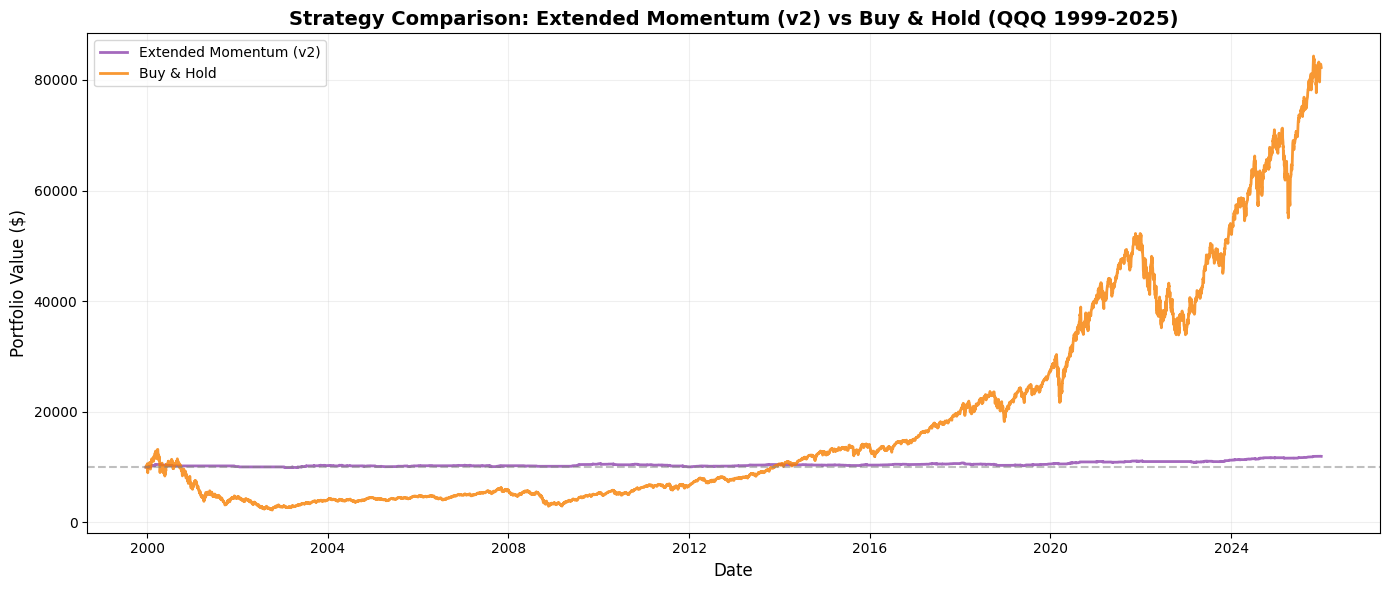

In [184]:
# Compare Extended Momentum Strategy with Buy-and-Hold
if len(data_backtest) > 0:
    # Use adjusted close for buy-and-hold to account for dividends
    price_col = results_extended['price_col']
    
    # Calculate buy-and-hold return (starting from index 200 where strategy begins)
    buy_hold_start_idx = 200
    buy_hold_start_price = data_backtest[price_col].iloc[buy_hold_start_idx]
    buy_hold_end_price = data_backtest[price_col].iloc[-1]
    buy_hold_return = (buy_hold_end_price - buy_hold_start_price) / buy_hold_start_price
    buy_hold_final = results_extended['initial_capital'] * (1 + buy_hold_return)
    
    print(f"\n{'='*60}")
    print("STRATEGY COMPARISON - EXTENDED MOMENTUM CONTINUATION (v2)")
    print(f"{'='*60}")
    print(f"{'Metric':<25} {'Strategy':<20} {'Buy & Hold':<20}")
    print(f"{'-'*65}")
    print(f"{'Initial Capital':<25} ${results_extended['initial_capital']:,.2f}{'':<15} ${results_extended['initial_capital']:,.2f}")
    print(f"{'Final Capital':<25} ${results_extended['final_capital']:,.2f}{'':<15} ${buy_hold_final:,.2f}")
    
    # Format returns with + sign for positive
    strategy_return_str = f"+{results_extended['total_return_pct']:.2f}%" if results_extended['total_return_pct'] >= 0 else f"{results_extended['total_return_pct']:.2f}%"
    buy_hold_return_str = f"+{buy_hold_return*100:.2f}%" if buy_hold_return >= 0 else f"{buy_hold_return*100:.2f}%"
    print(f"{'Total Return':<25} {strategy_return_str:<19} {buy_hold_return_str:<20}")
    print(f"{'='*60}")
    
    # Plot comparison
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Strategy equity curve
    dates_extended = [results_extended['dates'][200]] + results_extended['dates'][200:]
    ax.plot(dates_extended, results_extended['equity_curve'], linewidth=2, color='#8E44AD', label='Extended Momentum (v2)', alpha=0.8)
    
    # Buy-and-hold equity curve (starting from same point as strategy)
    buy_hold_curve = [results_extended['initial_capital']]
    for i in range(buy_hold_start_idx + 1, len(data_backtest)):
        return_so_far = (data_backtest[price_col].iloc[i] - buy_hold_start_price) / buy_hold_start_price
        buy_hold_curve.append(results_extended['initial_capital'] * (1 + return_so_far))
    
    ax.plot(data_backtest['date'].iloc[buy_hold_start_idx:], buy_hold_curve, linewidth=2, color='#F77F00', label='Buy & Hold', alpha=0.8)
    ax.axhline(y=results_extended['initial_capital'], color='gray', linestyle='--', alpha=0.5)
    
    ax.set_ylabel('Portfolio Value ($)', fontsize=12)
    ax.set_xlabel('Date', fontsize=12)
    # Get actual date range from data
    date_range_str = f"{data_backtest['date'].min().year}-{data_backtest['date'].max().year}"
    ax.set_title(f'Strategy Comparison: Extended Momentum (v2) vs Buy & Hold ({ticker} {date_range_str})', fontsize=14, fontweight='bold')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("No data available for comparison.")


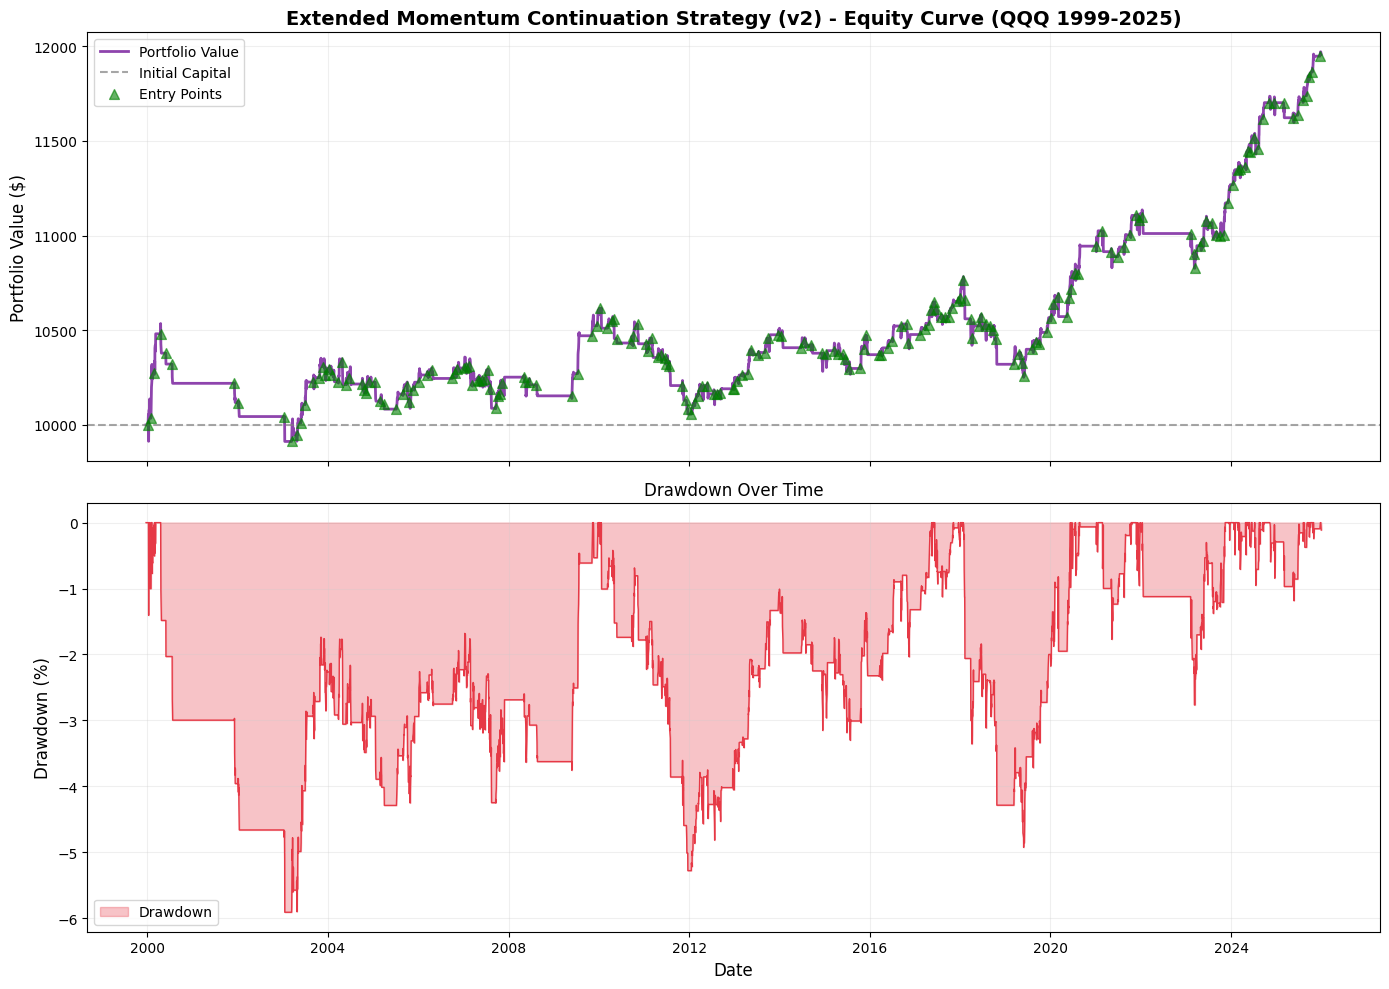


ADDITIONAL STATISTICS
Best Day: $115.19
Worst Day: $-106.18
Final Drawdown: -0.11%
Max Drawdown Date: 2003-01-17 00:00:00


In [185]:
# Plot equity curve with drawdown for Extended Momentum Strategy
if len(results_extended['equity_curve']) > 0:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
    
    # Equity curve
    dates_extended = [results_extended['dates'][200]] + results_extended['dates'][200:]
    ax1.plot(dates_extended, results_extended['equity_curve'], linewidth=2, color='#8E44AD', label='Portfolio Value')
    ax1.axhline(y=results_extended['initial_capital'], color='gray', linestyle='--', alpha=0.7, label='Initial Capital')
    
    # Mark entry points if trades exist
    if len(results_extended['trades']) > 0:
        trades_df = results_extended['trades']
        entry_dates = pd.to_datetime(trades_df['entry_date']).tolist()
        
        # Find corresponding equity values at entry dates
        entry_equity = []
        for ed in entry_dates:
            try:
                idx = dates_extended.index(ed)
                entry_equity.append(results_extended['equity_curve'][idx])
            except:
                # If exact date not found, use closest
                entry_equity.append(results_extended['initial_capital'])
        
        ax1.scatter(entry_dates, entry_equity, color='green', marker='^', s=50, alpha=0.6, label='Entry Points', zorder=5)
    
    ax1.set_ylabel('Portfolio Value ($)', fontsize=12)
    # Get actual date range from data
    date_range_str = f"{data_backtest['date'].min().year}-{data_backtest['date'].max().year}"
    ax1.set_title(f'Extended Momentum Continuation Strategy (v2) - Equity Curve ({ticker} {date_range_str})', fontsize=14, fontweight='bold')
    ax1.legend(loc='best')
    ax1.grid(True, alpha=0.3)
    
    # Drawdown chart
    equity_array = np.array(results_extended['equity_curve'])
    running_max = np.maximum.accumulate(equity_array)
    drawdown = (equity_array - running_max) / running_max * 100
    ax2.fill_between(dates_extended, drawdown, 0, color='#E63946', alpha=0.3, label='Drawdown')
    ax2.plot(dates_extended, drawdown, color='#E63946', linewidth=1)
    ax2.set_ylabel('Drawdown (%)', fontsize=12)
    ax2.set_xlabel('Date', fontsize=12)
    ax2.set_title('Drawdown Over Time', fontsize=12)
    ax2.legend(loc='best')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print additional statistics
    print(f"\n{'='*60}")
    print("ADDITIONAL STATISTICS")
    print(f"{'='*60}")
    daily_changes = np.diff(results_extended['equity_curve'])
    print(f"Best Day: ${max(daily_changes):,.2f}")
    print(f"Worst Day: ${min(daily_changes):,.2f}")
    print(f"Final Drawdown: {drawdown[-1]:.2f}%")
    print(f"Max Drawdown Date: {dates_extended[np.argmin(drawdown)]}")
else:
    print("No equity curve data to plot.")


In [186]:
# Trade analysis by exit reason
if len(results_extended['trades']) > 0:
    trades_df = results_extended['trades']
    
    print(f"\n{'='*60}")
    print("TRADE ANALYSIS BY EXIT REASON")
    print(f"{'='*60}")
    
    exit_reason_stats = trades_df.groupby('exit_reason').agg({
        'pnl': ['count', 'mean', 'sum'],
        'hold_days': 'mean',
        'pnl_dollar': 'sum'
    }).round(4)
    
    exit_reason_stats.columns = ['Count', 'Avg PnL', 'Total PnL', 'Avg Hold Days', 'Total PnL ($)']
    exit_reason_stats['Avg PnL %'] = exit_reason_stats['Avg PnL'] * 100
    exit_reason_stats['Total PnL %'] = exit_reason_stats['Total PnL'] * 100
    
    print(exit_reason_stats.to_string())
    
    # Display all trades
    print(f"\n{'='*60}")
    print("ALL TRADES")
    print(f"{'='*60}")
    trades_display = trades_df.copy()
    # Format dates for better readability
    trades_display['entry_date'] = pd.to_datetime(trades_display['entry_date']).dt.strftime('%Y-%m-%d')
    trades_display['exit_date'] = pd.to_datetime(trades_display['exit_date']).dt.strftime('%Y-%m-%d')
    # Round numeric columns
    trades_display['entry_price'] = trades_display['entry_price'].round(2)
    trades_display['exit_price'] = trades_display['exit_price'].round(2)
    trades_display['pnl_pct'] = trades_display['pnl_pct'].round(2)
    trades_display['pnl_dollar'] = trades_display['pnl_dollar'].round(2)
    print(trades_display.to_string(index=False))
else:
    print("No trades to analyze.")



TRADE ANALYSIS BY EXIT REASON
              Count  Avg PnL  Total PnL  Avg Hold Days  Total PnL ($)  Avg PnL %  Total PnL %
exit_reason                                                                                  
below_sma200     22  -0.0281    -0.6182         6.5455     -1241.5528      -2.81       -61.82
end_of_data       1   0.0052     0.0052        11.0000         9.5220       0.52         0.52
stop_loss        20  -0.0500    -1.0000         9.4000     -2056.3117      -5.00      -100.00
time_limit      155   0.0167     2.5810        15.4065      5245.5364       1.67       258.10

ALL TRADES
entry_date  exit_date  entry_price  exit_price position  position_size       pnl  pnl_pct  pnl_dollar  exit_reason  hold_days
2000-01-07 2000-01-24        76.02       77.39     long             26  0.018055     1.81       35.68   time_limit         17
2000-01-31 2000-02-15        75.75       84.86     long             26  0.120209    12.02      236.76   time_limit         15
2000-02-23 2000

In [187]:
# Export all trades to CSV (Extended Momentum v2)
if len(results_extended['trades']) > 0:
    trades_export = results_extended['trades'].copy()
    
    # Ensure dates are in proper format
    trades_export['entry_date'] = pd.to_datetime(trades_export['entry_date'])
    trades_export['exit_date'] = pd.to_datetime(trades_export['exit_date'])
    
    # Create filename with timestamp
    from datetime import datetime
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    filename = f'../data/strategy2_v2_extended_momentum_trades_{ticker}_{timestamp}.csv'
    
    # Export to CSV
    trades_export.to_csv(filename, index=False)
    
    print(f"\n{'='*60}")
    print(f"Trades exported to: {filename}")
    print(f"Total trades exported: {len(trades_export)}")
    print(f"{'='*60}")
    
    # Also create a summary CSV with key metrics
    summary_data = {
        'Metric': [
            'Initial Capital',
            'Final Capital',
            'Total Return (%)',
            'Total Trades',
            'Win Rate (%)',
            'Average Win (%)',
            'Average Loss (%)',
            'Max Drawdown (%)',
            'Sharpe Ratio'
        ],
        'Value': [
            results_extended['initial_capital'],
            results_extended['final_capital'],
            results_extended['total_return_pct'],
            results_extended['total_trades'],
            results_extended['win_rate_pct'],
            results_extended['avg_win_pct'],
            results_extended['avg_loss_pct'],
            results_extended['max_drawdown_pct'],
            results_extended['sharpe_ratio']
        ]
    }
    summary_df = pd.DataFrame(summary_data)
    summary_filename = f'../data/strategy2_v2_extended_momentum_summary_{ticker}_{timestamp}.csv'
    summary_df.to_csv(summary_filename, index=False)
    print(f"Summary exported to: {summary_filename}")
    print(f"{'='*60}")
else:
    print("\nNo trades to export.")



Trades exported to: ../data/strategy2_v2_extended_momentum_trades_QQQ_20260218_124252.csv
Total trades exported: 198
Summary exported to: ../data/strategy2_v2_extended_momentum_summary_QQQ_20260218_124252.csv


# Backtest: Strategy 2 v3 - Dynamic Momentum Continuation (Long-Only)

**v3 fixes: Tighter stop (4%), dynamic hold (while > SMA200, max 30d), +7% target, RSI>50 filter.**

This version improves upon v2 by:
- Adding RSI(14) > 50 filter for stronger momentum confirmation
- Using dynamic hold period (hold while price > SMA200, maximum 30 days)
- Tighter 4% stop-loss (instead of 5%) for better risk control
- Take-profit target at +7% to lock in gains
- Better balance between win/loss ratio


In [144]:
def backtest_dynamic_momentum(data, initial_capital=10000, risk_per_trade=0.01, stop_loss_pct=0.04, take_profit_pct=0.07, max_hold_days=30):
    """
    Backtest the Dynamic Momentum Continuation trading strategy (LONG-ONLY VERSION v3).
    
    Strategy Rules:
    - Long Entry: Bullish CDLLONGLINE or CDLCLOSINGMARUBOZU (value > 0) AND Close > 200-day SMA 
                  AND Volume > 20-day average AND RSI(14) > 50
    - No short entries (long-only strategy)
    - Only trade when price is above 200-day SMA (no trades in downtrends)
    - Exit: Dynamic hold while Close > SMA200 (max 30 days) OR 4% stop-loss OR +7% take-profit
    - Position sizing: Risk 1% of current capital per trade (adjusted for 4% stop)
    
    Parameters:
    -----------
    data : pd.DataFrame
        DataFrame with columns: date, open, high, low, close, vol
    initial_capital : float
        Starting capital (default: $10,000)
    risk_per_trade : float
        Risk percentage per trade (default: 1% = 0.01)
    stop_loss_pct : float
        Stop-loss percentage from entry (default: 4% = 0.04)
    take_profit_pct : float
        Take-profit percentage from entry (default: 7% = 0.07)
    max_hold_days : int
        Maximum holding period in days (default: 30)
    
    Returns:
    --------
    dict : Dictionary containing backtest results and metrics
    """
    
    # Create a copy to avoid modifying original data
    df = data.copy()
    
    # Ensure we have enough data for 200-day SMA
    if len(df) < 200:
        return {
            'error': f'Insufficient data: need at least 200 days, got {len(df)}',
            'trades': [],
            'equity_curve': None
        }
    
    # Determine price column (use adjusted close if available)
    price_col = 'close'
    if 'Adj Close' in df.columns:
        price_col = 'Adj Close'
    elif 'adj_close' in df.columns:
        price_col = 'adj_close'
    
    # Calculate 200-day Simple Moving Average
    df['SMA200'] = df[price_col].rolling(window=200, min_periods=200).mean()
    
    # Calculate 20-day average volume
    df['Avg_Vol20'] = df['vol'].rolling(window=20, min_periods=20).mean()
    
    # Calculate RSI(14)
    df['RSI14'] = talib.RSI(df[price_col].values, timeperiod=14)
    
    # Detect candlestick patterns using TA-Lib
    df['CDLLONGLINE'] = talib.CDLLONGLINE(df['open'].values, df['high'].values, 
                                          df['low'].values, df[price_col].values)
    df['CDLCLOSINGMARUBOZU'] = talib.CDLCLOSINGMARUBOZU(df['open'].values, df['high'].values, 
                                                        df['low'].values, df[price_col].values)
    
    # Determine long signals with all conditions
    # Long signal: bullish pattern (value > 0) AND close > SMA200 AND volume > avg_vol20 AND RSI14 > 50
    long_condition = (
        ((df['CDLLONGLINE'] > 0) | (df['CDLCLOSINGMARUBOZU'] > 0)) &
        (df[price_col] > df['SMA200']) &
        (df['vol'] > df['Avg_Vol20']) &
        (df['RSI14'] > 50) &
        (~df['SMA200'].isna()) &  # Ensure SMA200 is calculated
        (~df['RSI14'].isna())  # Ensure RSI14 is calculated
    )
    
    # Create long signal column: 1 (long entry), 0 (no signal)
    df['Long_Signal'] = 0
    df.loc[long_condition, 'Long_Signal'] = 1
    
    # Initialize trading variables
    capital = initial_capital
    position = None  # 'long' or None (no shorts)
    entry_price = None
    entry_date = None
    entry_index = None
    position_size = None  # Number of shares
    trades = []
    equity_curve = [capital]
    
    # Loop through data to simulate trades (start from index 200 to ensure SMA200 is available)
    for i in range(200, len(df)):
        current_price = df.loc[i, price_col]
        current_date = df.loc[i, 'date']
        current_high = df.loc[i, 'high']
        current_low = df.loc[i, 'low']
        current_sma200 = df.loc[i, 'SMA200']
        
        # Check for stop-loss if in position (long only)
        if position == 'long':
            # Long stop-loss: exit if price drops 4% below entry
            if current_low <= entry_price * (1 - stop_loss_pct):
                # Exit trade at stop-loss price
                exit_price = entry_price * (1 - stop_loss_pct)
                pnl = (exit_price - entry_price) / entry_price
                trade_value = capital + (position_size * (exit_price - entry_price))
                capital = trade_value
                
                trades.append({
                    'entry_date': entry_date,
                    'exit_date': current_date,
                    'entry_price': entry_price,
                    'exit_price': exit_price,
                    'position': position,
                    'position_size': position_size,
                    'pnl': pnl,
                    'pnl_pct': pnl * 100,
                    'pnl_dollar': position_size * (exit_price - entry_price),
                    'exit_reason': 'stop_loss',
                    'hold_days': (current_date - entry_date).days
                })
                
                position = None
                entry_price = None
                entry_date = None
                entry_index = None
                position_size = None
                continue  # Skip to next iteration
        
        # Check for take-profit if in position
        if position == 'long':
            # Take-profit: exit if price rises 7% above entry
            if current_high >= entry_price * (1 + take_profit_pct):
                # Exit trade at take-profit price
                exit_price = entry_price * (1 + take_profit_pct)
                pnl = (exit_price - entry_price) / entry_price
                trade_value = capital + (position_size * (exit_price - entry_price))
                capital = trade_value
                
                trades.append({
                    'entry_date': entry_date,
                    'exit_date': current_date,
                    'entry_price': entry_price,
                    'exit_price': exit_price,
                    'position': position,
                    'position_size': position_size,
                    'pnl': pnl,
                    'pnl_pct': pnl * 100,
                    'pnl_dollar': position_size * (exit_price - entry_price),
                    'exit_reason': 'take_profit',
                    'hold_days': (current_date - entry_date).days
                })
                
                position = None
                entry_price = None
                entry_date = None
                entry_index = None
                position_size = None
                continue  # Skip to next iteration
        
        # Check for exit conditions if in position
        if position == 'long':
            days_held = (current_date - entry_date).days
            
            # Exit if price drops below SMA200 (dynamic exit)
            if current_sma200 is not None and current_price < current_sma200:
                # Exit trade at current close
                pnl = (current_price - entry_price) / entry_price
                trade_value = capital + (position_size * (current_price - entry_price))
                capital = trade_value
                
                trades.append({
                    'entry_date': entry_date,
                    'exit_date': current_date,
                    'entry_price': entry_price,
                    'exit_price': current_price,
                    'position': position,
                    'position_size': position_size,
                    'pnl': pnl,
                    'pnl_pct': pnl * 100,
                    'pnl_dollar': position_size * (current_price - entry_price),
                    'exit_reason': 'below_sma200',
                    'hold_days': days_held
                })
                
                position = None
                entry_price = None
                entry_date = None
                entry_index = None
                position_size = None
                continue  # Skip to next iteration
            
            # Exit after max_hold_days (30 days)
            if days_held >= max_hold_days:
                # Exit trade at current close
                pnl = (current_price - entry_price) / entry_price
                trade_value = capital + (position_size * (current_price - entry_price))
                capital = trade_value
                
                trades.append({
                    'entry_date': entry_date,
                    'exit_date': current_date,
                    'entry_price': entry_price,
                    'exit_price': current_price,
                    'position': position,
                    'position_size': position_size,
                    'pnl': pnl,
                    'pnl_pct': pnl * 100,
                    'pnl_dollar': position_size * (current_price - entry_price),
                    'exit_reason': 'time_limit',
                    'hold_days': days_held
                })
                
                position = None
                entry_price = None
                entry_date = None
                entry_index = None
                position_size = None
                continue  # Skip to next iteration
        
        # Check for new entry signals (only if not in position, long-only, and price above SMA200)
        if position is None:
            signal = df.loc[i, 'Long_Signal']
            sma200_value = df.loc[i, 'SMA200']
            
            # Long entry signal only (and price must be above SMA200)
            if signal == 1 and sma200_value is not None and current_price > sma200_value:
                position = 'long'
                entry_price = current_price  # Enter at close of pattern candle
                entry_date = current_date
                entry_index = i
                
                # Calculate position size: risk 1% of capital
                # Position size = (capital * risk_per_trade) / (entry_price * stop_loss_pct)
                # Adjusted for 4% stop-loss
                position_size = int((capital * risk_per_trade) / (entry_price * stop_loss_pct))
                if position_size < 1:
                    position_size = 0  # Can't buy fractional shares
                    position = None
                    entry_price = None
                    entry_date = None
                    entry_index = None
        
        # Update equity curve (calculate current portfolio value)
        if position == 'long':
            current_value = capital + (position_size * (current_price - entry_price))
            equity_curve.append(current_value)
        else:
            equity_curve.append(capital)
    
    # Close any open position at the end
    if position == 'long':
        final_price = df.loc[len(df)-1, price_col]
        pnl = (final_price - entry_price) / entry_price
        trade_value = capital + (position_size * (final_price - entry_price))
        capital = trade_value
        
        trades.append({
            'entry_date': entry_date,
            'exit_date': df.loc[len(df)-1, 'date'],
            'entry_price': entry_price,
            'exit_price': final_price,
            'position': position,
            'position_size': position_size,
            'pnl': pnl,
            'pnl_pct': pnl * 100,
            'pnl_dollar': position_size * (final_price - entry_price),
            'exit_reason': 'end_of_data',
            'hold_days': (df.loc[len(df)-1, 'date'] - entry_date).days
        })
    
    # Calculate metrics
    if len(trades) > 0:
        trades_df = pd.DataFrame(trades)
        
        # Total return
        total_return = (capital - initial_capital) / initial_capital
        
        # Win rate
        winning_trades = trades_df[trades_df['pnl'] > 0]
        win_rate = len(winning_trades) / len(trades_df) if len(trades_df) > 0 else 0
        
        # Average win/loss
        avg_win = winning_trades['pnl'].mean() if len(winning_trades) > 0 else 0
        losing_trades = trades_df[trades_df['pnl'] <= 0]
        avg_loss = losing_trades['pnl'].mean() if len(losing_trades) > 0 else 0
        
        # Max drawdown
        equity_array = np.array(equity_curve)
        running_max = np.maximum.accumulate(equity_array)
        drawdown = (equity_array - running_max) / running_max
        max_drawdown = drawdown.min()
        
        # Sharpe ratio (assuming daily returns, risk-free rate = 0%)
        daily_returns = np.diff(equity_curve) / equity_curve[:-1]
        sharpe_ratio = np.mean(daily_returns) / np.std(daily_returns) * np.sqrt(252) if np.std(daily_returns) > 0 else 0
        
        # Total number of trades
        total_trades = len(trades_df)
        
        results = {
            'initial_capital': initial_capital,
            'final_capital': capital,
            'total_return': total_return,
            'total_return_pct': total_return * 100,
            'total_trades': total_trades,
            'win_rate': win_rate,
            'win_rate_pct': win_rate * 100,
            'avg_win': avg_win,
            'avg_win_pct': avg_win * 100,
            'avg_loss': avg_loss,
            'avg_loss_pct': avg_loss * 100,
            'max_drawdown': max_drawdown,
            'max_drawdown_pct': max_drawdown * 100,
            'sharpe_ratio': sharpe_ratio,
            'trades': trades_df,
            'equity_curve': equity_curve,
            'dates': df['date'].tolist(),
            'price_col': price_col
        }
    else:
        results = {
            'initial_capital': initial_capital,
            'final_capital': capital,
            'total_return': 0,
            'total_return_pct': 0,
            'total_trades': 0,
            'win_rate': 0,
            'win_rate_pct': 0,
            'avg_win': 0,
            'avg_win_pct': 0,
            'avg_loss': 0,
            'avg_loss_pct': 0,
            'max_drawdown': 0,
            'max_drawdown_pct': 0,
            'sharpe_ratio': 0,
            'trades': pd.DataFrame(),
            'equity_curve': equity_curve,
            'dates': df['date'].tolist(),
            'price_col': price_col
        }
    
    return results


In [145]:
# Run backtest for Dynamic Momentum Continuation Strategy (v3)
print("="*60)
print("Running backtest for Dynamic Momentum Continuation Strategy (v3)...")
print("="*60)
print("v3: Tighter stop (4%), dynamic hold (while > SMA200, max 30d), +7% target, RSI>50")
print("="*60)

# Use full available data (1990 onwards, as much as possible)
results_dynamic = backtest_dynamic_momentum(
    data=data_backtest,
    initial_capital=10000,
    risk_per_trade=0.01,
    stop_loss_pct=0.04,  # 4% stop-loss (tighter)
    take_profit_pct=0.07,  # 7% take-profit
    max_hold_days=30  # Maximum 30-day hold period
)

# Display results
print(f"\n{'='*60}")
print("BACKTEST RESULTS - DYNAMIC MOMENTUM CONTINUATION STRATEGY (v3)")
print(f"{'='*60}")
print(f"Initial Capital: ${results_dynamic['initial_capital']:,.2f}")
print(f"Final Capital: ${results_dynamic['final_capital']:,.2f}")
if results_dynamic['total_return_pct'] >= 0:
    print(f"Total Return: +{results_dynamic['total_return_pct']:.2f}%")
else:
    print(f"Total Return: {results_dynamic['total_return_pct']:.2f}%")
print(f"\nTotal Trades: {results_dynamic['total_trades']}")
print(f"Win Rate: {results_dynamic['win_rate_pct']:.2f}%")
print(f"Average Win: {results_dynamic['avg_win_pct']:.2f}%")
print(f"Average Loss: {results_dynamic['avg_loss_pct']:.2f}%")
print(f"Max Drawdown: {results_dynamic['max_drawdown_pct']:.2f}%")
print(f"Sharpe Ratio: {results_dynamic['sharpe_ratio']:.2f}")
print(f"\nNote: v3 improvements - Tighter 4% stop, dynamic hold to SMA200, +7% take-profit, RSI>50 filter")
print(f"{'='*60}")


Running backtest for Dynamic Momentum Continuation Strategy (v3)...
v3: Tighter stop (4%), dynamic hold (while > SMA200, max 30d), +7% target, RSI>50

BACKTEST RESULTS - DYNAMIC MOMENTUM CONTINUATION STRATEGY (v3)
Initial Capital: $10,000.00
Final Capital: $12,985.15
Total Return: +29.85%

Total Trades: 138
Win Rate: 55.07%
Average Win: 3.93%
Average Loss: -3.02%
Max Drawdown: -4.93%
Sharpe Ratio: 0.47

Note: v3 improvements - Tighter 4% stop, dynamic hold to SMA200, +7% take-profit, RSI>50 filter



DYNAMIC MOMENTUM CONTINUATION STRATEGY (v3) - PERFORMANCE SUMMARY
Metric                         Value               
--------------------------------------------------
Initial Capital                $10,000.00
Final Capital                  $12,985.15
Total Return                   +29.85%
Total Trades                   138
Win Rate                       55.07%
Average Win                    3.93%
Average Loss                   -3.02%
Max Drawdown                   -4.93%
Sharpe Ratio                   0.47


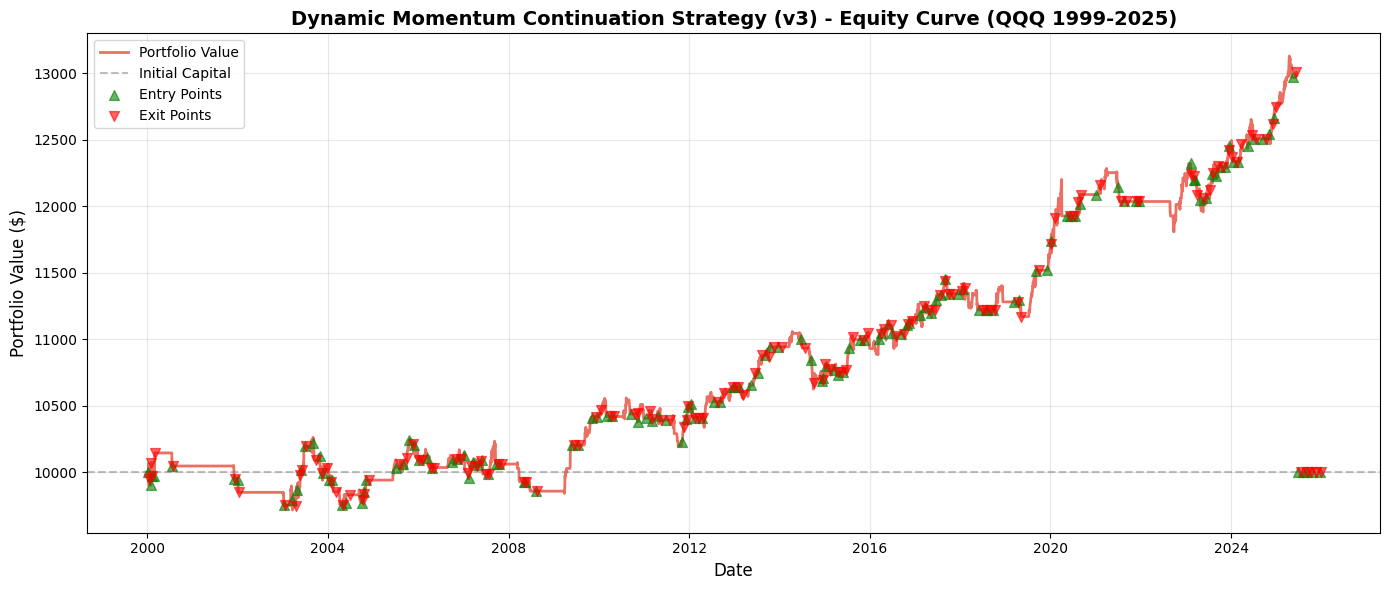

In [146]:
# Display Dynamic Momentum Strategy (v3) Performance
if len(data_backtest) > 0:
    print(f"\n{'='*60}")
    print("DYNAMIC MOMENTUM CONTINUATION STRATEGY (v3) - PERFORMANCE SUMMARY")
    print(f"{'='*60}")
    print(f"{'Metric':<30} {'Value':<20}")
    print(f"{'-'*50}")
    print(f"{'Initial Capital':<30} ${results_dynamic['initial_capital']:,.2f}")
    print(f"{'Final Capital':<30} ${results_dynamic['final_capital']:,.2f}")
    
    # Format returns with + sign for positive
    strategy_return_str = f"+{results_dynamic['total_return_pct']:.2f}%" if results_dynamic['total_return_pct'] >= 0 else f"{results_dynamic['total_return_pct']:.2f}%"
    print(f"{'Total Return':<30} {strategy_return_str}")
    print(f"{'Total Trades':<30} {results_dynamic['total_trades']}")
    print(f"{'Win Rate':<30} {results_dynamic['win_rate_pct']:.2f}%")
    print(f"{'Average Win':<30} {results_dynamic['avg_win_pct']:.2f}%")
    print(f"{'Average Loss':<30} {results_dynamic['avg_loss_pct']:.2f}%")
    print(f"{'Max Drawdown':<30} {results_dynamic['max_drawdown_pct']:.2f}%")
    print(f"{'Sharpe Ratio':<30} {results_dynamic['sharpe_ratio']:.2f}")
    print(f"{'='*60}")
    
    # Plot equity curve
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Strategy equity curve - align dates with equity curve
    # equity_curve starts with initial capital, then one value per day from index 200
    # So we need dates from index 200 onwards, matching the length of equity_curve
    dates_extended = results_dynamic['dates'][200:]
    # Ensure lengths match (equity_curve has initial capital + one per day, so skip first element)
    if len(results_dynamic['equity_curve']) == len(dates_extended) + 1:
        # equity_curve has one extra element (initial capital), so use dates_extended with equity_curve[1:]
        ax.plot(dates_extended, results_dynamic['equity_curve'][1:], linewidth=2, color='#E74C3C', label='Portfolio Value', alpha=0.8)
        equity_curve_aligned = results_dynamic['equity_curve'][1:]
    else:
        # If lengths don't match expected, use the shorter length
        min_len = min(len(dates_extended), len(results_dynamic['equity_curve']))
        ax.plot(dates_extended[:min_len], results_dynamic['equity_curve'][:min_len], linewidth=2, color='#E74C3C', label='Portfolio Value', alpha=0.8)
        equity_curve_aligned = results_dynamic['equity_curve'][:min_len]
    
    ax.axhline(y=results_dynamic['initial_capital'], color='gray', linestyle='--', alpha=0.5, label='Initial Capital')
    
    # Mark entry and exit points
    if len(results_dynamic['trades']) > 0:
        trades_df = results_dynamic['trades']
        entry_dates = pd.to_datetime(trades_df['entry_date']).tolist()
        exit_dates = pd.to_datetime(trades_df['exit_date']).tolist()
        
        # Find entry equity values
        entry_equity = []
        for ed in entry_dates:
            try:
                idx = dates_extended.index(ed)
                if idx < len(equity_curve_aligned):
                    entry_equity.append(equity_curve_aligned[idx])
                else:
                    entry_equity.append(results_dynamic['initial_capital'])
            except:
                entry_equity.append(results_dynamic['initial_capital'])
        
        # Find exit equity values
        exit_equity = []
        for ed in exit_dates:
            try:
                idx = dates_extended.index(ed)
                if idx < len(equity_curve_aligned):
                    exit_equity.append(equity_curve_aligned[idx])
                else:
                    exit_equity.append(results_dynamic['initial_capital'])
            except:
                exit_equity.append(results_dynamic['initial_capital'])
        
        ax.scatter(entry_dates, entry_equity, color='green', marker='^', s=50, alpha=0.6, label='Entry Points', zorder=5)
        ax.scatter(exit_dates, exit_equity, color='red', marker='v', s=50, alpha=0.6, label='Exit Points', zorder=5)
    
    # Get actual date range from data
    date_range_str = f"{data_backtest['date'].min().year}-{data_backtest['date'].max().year}"
    ax.set_ylabel('Portfolio Value ($)', fontsize=12)
    ax.set_xlabel('Date', fontsize=12)
    ax.set_title(f'Dynamic Momentum Continuation Strategy (v3) - Equity Curve ({ticker} {date_range_str})', fontsize=14, fontweight='bold')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("No data available for plotting.")


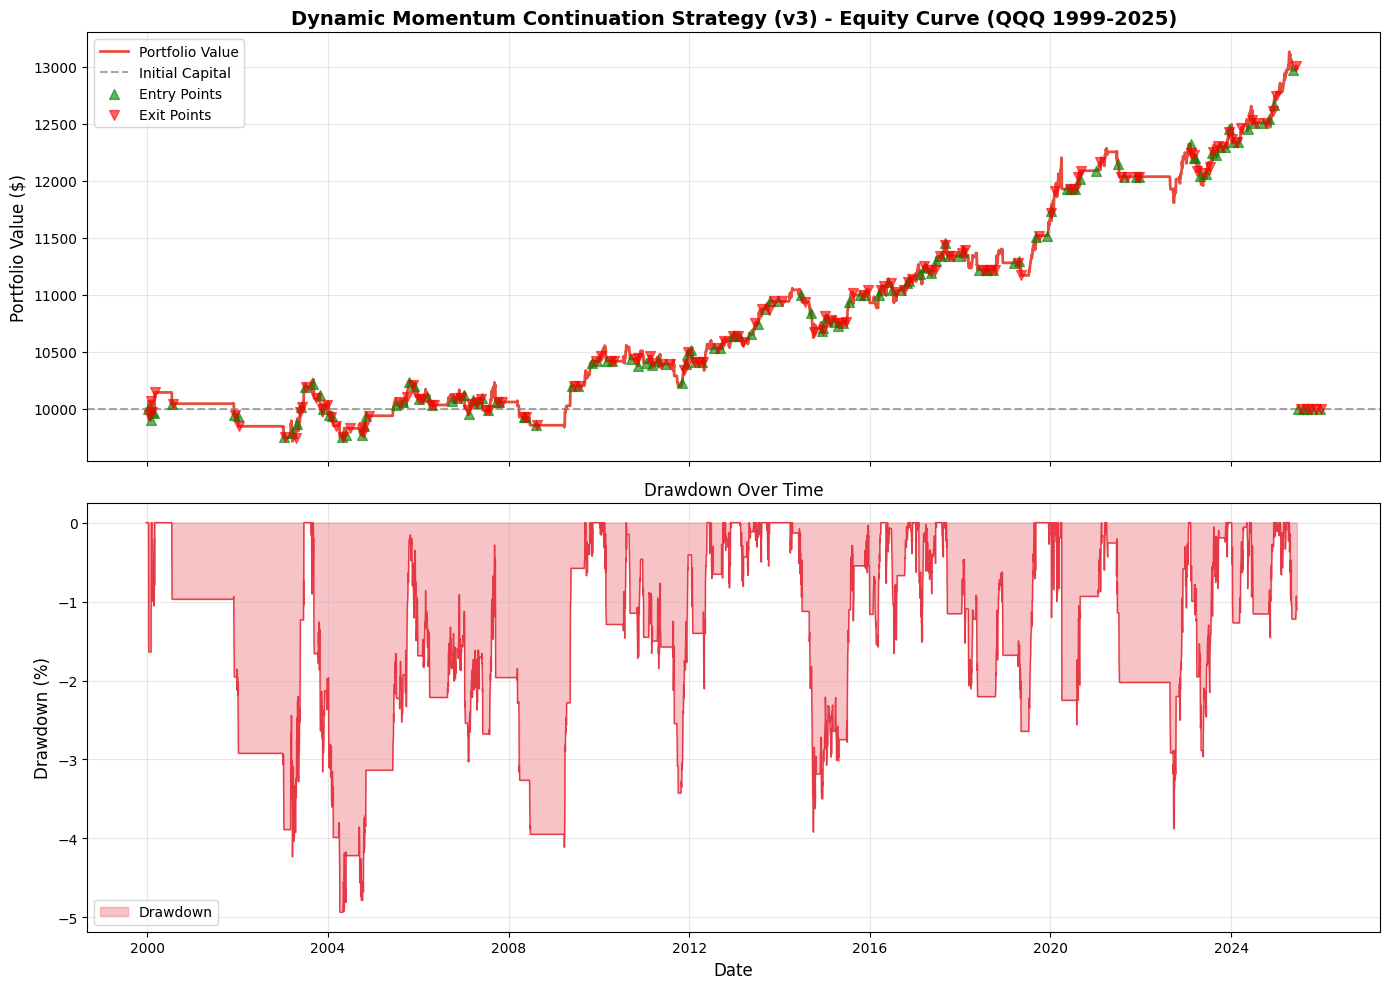


ADDITIONAL STATISTICS
Best Day: $140.23
Worst Day: $-148.69
Final Drawdown: -1.10%
Max Drawdown Date: 2004-04-06 00:00:00


In [147]:
# Plot equity curve with drawdown for Dynamic Momentum Strategy (v3)
if len(results_dynamic['equity_curve']) > 0:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
    
    # Equity curve - align dates with equity curve
    dates_extended = results_dynamic['dates'][200:]
    # Ensure lengths match (equity_curve has initial capital + one per day, so skip first element)
    if len(results_dynamic['equity_curve']) == len(dates_extended) + 1:
        # equity_curve has one extra element (initial capital), so use dates_extended with equity_curve[1:]
        ax1.plot(dates_extended, results_dynamic['equity_curve'][1:], linewidth=2, color='#E74C3C', label='Portfolio Value')
        equity_curve_aligned = results_dynamic['equity_curve'][1:]
    else:
        # If lengths don't match expected, use the shorter length
        min_len = min(len(dates_extended), len(results_dynamic['equity_curve']))
        ax1.plot(dates_extended[:min_len], results_dynamic['equity_curve'][:min_len], linewidth=2, color='#E74C3C', label='Portfolio Value')
        equity_curve_aligned = results_dynamic['equity_curve'][:min_len]
    ax1.axhline(y=results_dynamic['initial_capital'], color='gray', linestyle='--', alpha=0.7, label='Initial Capital')
    
    # Mark entry and exit points if trades exist
    if len(results_dynamic['trades']) > 0:
        trades_df = results_dynamic['trades']
        entry_dates = pd.to_datetime(trades_df['entry_date']).tolist()
        exit_dates = pd.to_datetime(trades_df['exit_date']).tolist()
        
        # Find corresponding equity values at entry/exit dates
        entry_equity = []
        for ed in entry_dates:
            try:
                idx = dates_extended.index(ed)
                if idx < len(equity_curve_aligned):
                    entry_equity.append(equity_curve_aligned[idx])
                else:
                    entry_equity.append(results_dynamic['initial_capital'])
            except:
                entry_equity.append(results_dynamic['initial_capital'])
        
        exit_equity = []
        for ed in exit_dates:
            try:
                idx = dates_extended.index(ed)
                if idx < len(equity_curve_aligned):
                    exit_equity.append(equity_curve_aligned[idx])
                else:
                    exit_equity.append(results_dynamic['initial_capital'])
            except:
                exit_equity.append(results_dynamic['initial_capital'])
        
        ax1.scatter(entry_dates, entry_equity, color='green', marker='^', s=50, alpha=0.6, label='Entry Points', zorder=5)
        ax1.scatter(exit_dates, exit_equity, color='red', marker='v', s=50, alpha=0.6, label='Exit Points', zorder=5)
    
    # Get actual date range from data
    date_range_str = f"{data_backtest['date'].min().year}-{data_backtest['date'].max().year}"
    ax1.set_ylabel('Portfolio Value ($)', fontsize=12)
    ax1.set_title(f'Dynamic Momentum Continuation Strategy (v3) - Equity Curve ({ticker} {date_range_str})', fontsize=14, fontweight='bold')
    ax1.legend(loc='best')
    ax1.grid(True, alpha=0.3)
    
    # Drawdown chart - use aligned equity curve
    equity_array = np.array(equity_curve_aligned)
    running_max = np.maximum.accumulate(equity_array)
    drawdown = (equity_array - running_max) / running_max * 100
    
    # Ensure dates_extended and drawdown have the same length
    min_len = min(len(dates_extended), len(drawdown))
    dates_drawdown = dates_extended[:min_len]
    drawdown_aligned = drawdown[:min_len]
    
    ax2.fill_between(dates_drawdown, drawdown_aligned, 0, color='#E63946', alpha=0.3, label='Drawdown')
    ax2.plot(dates_drawdown, drawdown_aligned, color='#E63946', linewidth=1)
    ax2.set_ylabel('Drawdown (%)', fontsize=12)
    ax2.set_xlabel('Date', fontsize=12)
    ax2.set_title('Drawdown Over Time', fontsize=12)
    ax2.legend(loc='best')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print additional statistics
    print(f"\n{'='*60}")
    print("ADDITIONAL STATISTICS")
    print(f"{'='*60}")
    daily_changes = np.diff(equity_curve_aligned)
    print(f"Best Day: ${max(daily_changes):,.2f}")
    print(f"Worst Day: ${min(daily_changes):,.2f}")
    print(f"Final Drawdown: {drawdown_aligned[-1]:.2f}%")
    print(f"Max Drawdown Date: {dates_drawdown[np.argmin(drawdown_aligned)]}")
else:
    print("No equity curve data to plot.")


In [148]:
# Trade analysis by exit reason for Dynamic Momentum Strategy (v3)
if len(results_dynamic['trades']) > 0:
    trades_df = results_dynamic['trades']
    
    print(f"\n{'='*60}")
    print("TRADE ANALYSIS BY EXIT REASON (v3)")
    print(f"{'='*60}")
    
    exit_reason_stats = trades_df.groupby('exit_reason').agg({
        'pnl': ['count', 'mean', 'sum'],
        'hold_days': 'mean',
        'pnl_dollar': 'sum'
    }).round(4)
    
    exit_reason_stats.columns = ['Count', 'Avg PnL', 'Total PnL', 'Avg Hold Days', 'Total PnL ($)']
    exit_reason_stats['Avg PnL %'] = exit_reason_stats['Avg PnL'] * 100
    exit_reason_stats['Total PnL %'] = exit_reason_stats['Total PnL'] * 100
    
    print(exit_reason_stats.to_string())
    
    # Display all trades
    print(f"\n{'='*60}")
    print("ALL TRADES (v3)")
    print(f"{'='*60}")
    trades_display = trades_df.copy()
    # Format dates for better readability
    trades_display['entry_date'] = pd.to_datetime(trades_display['entry_date']).dt.strftime('%Y-%m-%d')
    trades_display['exit_date'] = pd.to_datetime(trades_display['exit_date']).dt.strftime('%Y-%m-%d')
    # Round numeric columns
    trades_display['entry_price'] = trades_display['entry_price'].round(2)
    trades_display['exit_price'] = trades_display['exit_price'].round(2)
    trades_display['pnl_pct'] = trades_display['pnl_pct'].round(2)
    trades_display['pnl_dollar'] = trades_display['pnl_dollar'].round(2)
    print(trades_display.to_string(index=False))
else:
    print("No trades to analyze.")



TRADE ANALYSIS BY EXIT REASON (v3)
              Count  Avg PnL  Total PnL  Avg Hold Days  Total PnL ($)  Avg PnL %  Total PnL %
exit_reason                                                                                  
below_sma200     10  -0.0145    -0.1446        10.2000      -369.9237      -1.45       -14.46
end_of_data       1   0.0052     0.0052        11.0000        15.8701       0.52         0.52
stop_loss        40  -0.0400    -1.6000        13.6250     -4233.9029      -4.00      -160.00
take_profit      17   0.0700     1.1900        19.8824      3086.3244       7.00       119.00
time_limit       70   0.0237     1.6612        30.6857      4486.7783       2.37       166.12

ALL TRADES (v3)
entry_date  exit_date  entry_price  exit_price position  position_size       pnl  pnl_pct  pnl_dollar  exit_reason  hold_days
2000-01-07 2000-01-12        76.02       72.98     long             32 -0.040000    -4.00      -97.30    stop_loss          5
2000-01-31 2000-02-03        75.75   

In [149]:
# Export all trades to CSV (Dynamic Momentum v3)
if len(results_dynamic['trades']) > 0:
    trades_export = results_dynamic['trades'].copy()
    
    # Ensure dates are in proper format
    trades_export['entry_date'] = pd.to_datetime(trades_export['entry_date'])
    trades_export['exit_date'] = pd.to_datetime(trades_export['exit_date'])
    
    # Create filename with timestamp
    from datetime import datetime
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    filename = f'../data/strategy2_v3_dynamic_momentum_trades_{ticker}_{timestamp}.csv'
    
    # Export to CSV
    trades_export.to_csv(filename, index=False)
    
    print(f"\n{'='*60}")
    print(f"Trades exported to: {filename}")
    print(f"Total trades exported: {len(trades_export)}")
    print(f"{'='*60}")
    
    # Also create a summary CSV with key metrics
    summary_data = {
        'Metric': [
            'Initial Capital',
            'Final Capital',
            'Total Return (%)',
            'Total Trades',
            'Win Rate (%)',
            'Average Win (%)',
            'Average Loss (%)',
            'Max Drawdown (%)',
            'Sharpe Ratio'
        ],
        'Value': [
            results_dynamic['initial_capital'],
            results_dynamic['final_capital'],
            results_dynamic['total_return_pct'],
            results_dynamic['total_trades'],
            results_dynamic['win_rate_pct'],
            results_dynamic['avg_win_pct'],
            results_dynamic['avg_loss_pct'],
            results_dynamic['max_drawdown_pct'],
            results_dynamic['sharpe_ratio']
        ]
    }
    summary_df = pd.DataFrame(summary_data)
    summary_filename = f'../data/strategy2_v3_dynamic_momentum_summary_{ticker}_{timestamp}.csv'
    summary_df.to_csv(summary_filename, index=False)
    print(f"Summary exported to: {summary_filename}")
    print(f"{'='*60}")
else:
    print("\nNo trades to export.")



Trades exported to: ../data/strategy2_v3_dynamic_momentum_trades_QQQ_20260218_122704.csv
Total trades exported: 138
Summary exported to: ../data/strategy2_v3_dynamic_momentum_summary_QQQ_20260218_122704.csv


# TradingView-Style Interactive Chart for Detailed Trade Analysis

Interactive candlestick chart with zoom capabilities to see individual trades at microscopic level.


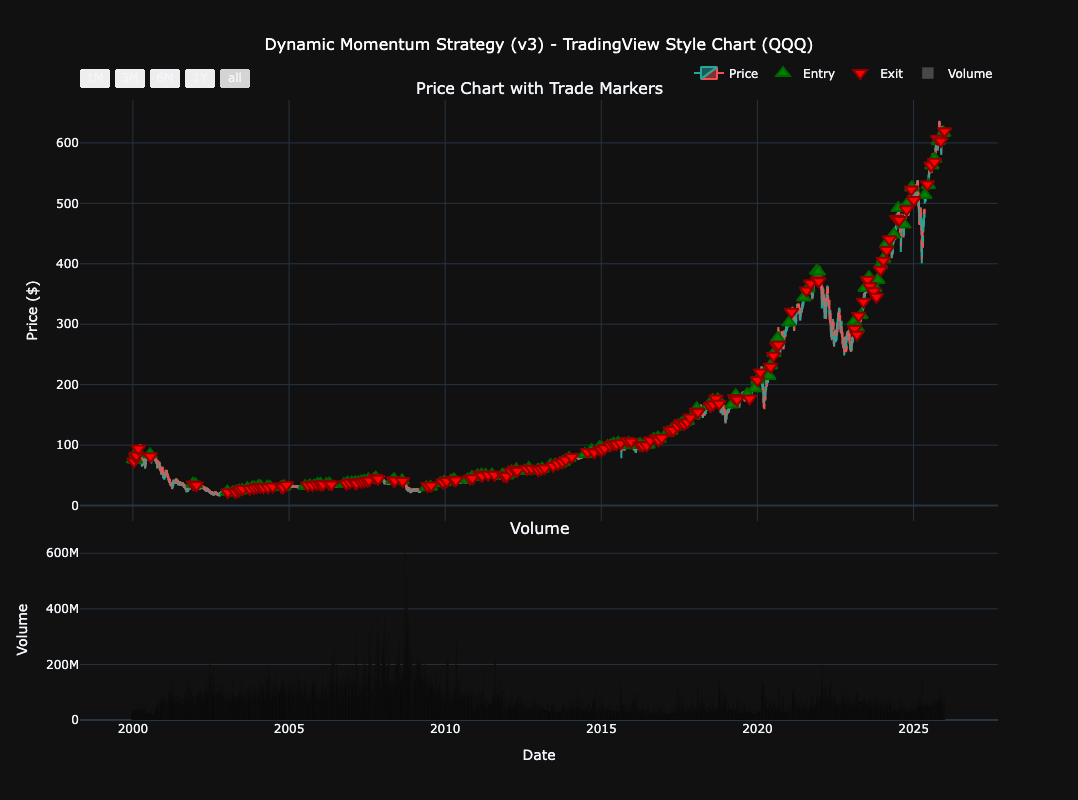


INTERACTIVE CHART DISPLAYED
Use the zoom tools (top right) to zoom into specific time periods
Hover over entry/exit markers to see trade details
Green triangles = Entry points
Red triangles = Exit points


In [150]:
# TradingView-style interactive candlestick chart with trade markers
import plotly.graph_objects as go
from plotly.subplots import make_subplots

if len(results_dynamic['trades']) > 0 and len(data_backtest) > 0:
    # Prepare data for plotting
    price_col = results_dynamic['price_col']
    
    # Get data from index 200 onwards (where strategy starts)
    plot_data = data_backtest.iloc[200:].copy()
    plot_data = plot_data.reset_index(drop=True)
    
    # Create subplots: price chart on top, volume on bottom
    fig = make_subplots(
        rows=2, cols=1,
        shared_xaxes=True,
        vertical_spacing=0.03,
        row_heights=[0.7, 0.3],
        subplot_titles=('Price Chart with Trade Markers', 'Volume'),
        specs=[[{"secondary_y": False}], [{"secondary_y": False}]]
    )
    
    # Add candlestick chart
    fig.add_trace(
        go.Candlestick(
            x=plot_data['date'],
            open=plot_data['open'],
            high=plot_data['high'],
            low=plot_data['low'],
            close=plot_data[price_col],
            name='Price',
            increasing_line_color='#26a69a',
            decreasing_line_color='#ef5350'
        ),
        row=1, col=1
    )
    
    # Add 200-day SMA
    if 'SMA200' in plot_data.columns or len(plot_data) >= 200:
        sma200 = data_backtest['SMA200'].iloc[200:].values if 'SMA200' in data_backtest.columns else None
        if sma200 is not None and len(sma200) == len(plot_data):
            fig.add_trace(
                go.Scatter(
                    x=plot_data['date'],
                    y=sma200,
                    name='SMA200',
                    line=dict(color='orange', width=1, dash='dash'),
                    opacity=0.7
                ),
                row=1, col=1
            )
    
    # Mark entry points (green triangles)
    trades_df = results_dynamic['trades']
    entry_dates = pd.to_datetime(trades_df['entry_date']).tolist()
    entry_prices = trades_df['entry_price'].tolist()
    
    # Filter entry points that are in the plot data range
    plot_start_date = plot_data['date'].iloc[0]
    plot_end_date = plot_data['date'].iloc[-1]
    
    valid_entries = []
    valid_entry_prices = []
    for ed, ep in zip(entry_dates, entry_prices):
        if plot_start_date <= ed <= plot_end_date:
            valid_entries.append(ed)
            valid_entry_prices.append(ep)
    
    if len(valid_entries) > 0:
        fig.add_trace(
            go.Scatter(
                x=valid_entries,
                y=valid_entry_prices,
                mode='markers',
                name='Entry',
                marker=dict(
                    symbol='triangle-up',
                    size=12,
                    color='green',
                    line=dict(width=2, color='darkgreen')
                ),
                hovertemplate='<b>Entry</b><br>Date: %{x}<br>Price: $%{y:.2f}<extra></extra>'
            ),
            row=1, col=1
        )
    
    # Mark exit points (red triangles down)
    exit_dates = pd.to_datetime(trades_df['exit_date']).tolist()
    exit_prices = trades_df['exit_price'].tolist()
    exit_reasons = trades_df['exit_reason'].tolist()
    
    valid_exits = []
    valid_exit_prices = []
    valid_exit_reasons = []
    for ed, ep, er in zip(exit_dates, exit_prices, exit_reasons):
        if plot_start_date <= ed <= plot_end_date:
            valid_exits.append(ed)
            valid_exit_prices.append(ep)
            valid_exit_reasons.append(er)
    
    if len(valid_exits) > 0:
        fig.add_trace(
            go.Scatter(
                x=valid_exits,
                y=valid_exit_prices,
                mode='markers',
                name='Exit',
                marker=dict(
                    symbol='triangle-down',
                    size=12,
                    color='red',
                    line=dict(width=2, color='darkred')
                ),
                hovertemplate='<b>Exit</b><br>Date: %{x}<br>Price: $%{y:.2f}<br>Reason: %{text}<extra></extra>',
                text=valid_exit_reasons
            ),
            row=1, col=1
        )
    
    # Add volume bars
    fig.add_trace(
        go.Bar(
            x=plot_data['date'],
            y=plot_data['vol'],
            name='Volume',
            marker_color='rgba(128, 128, 128, 0.5)'
        ),
        row=2, col=1
    )
    
    # Update layout for TradingView-style appearance
    fig.update_layout(
        title=dict(
            text=f'Dynamic Momentum Strategy (v3) - TradingView Style Chart ({ticker})',
            x=0.5,
            font=dict(size=16, color='white')
        ),
        xaxis_rangeslider_visible=False,
        height=800,
        template='plotly_dark',
        hovermode='x unified',
        showlegend=True,
        legend=dict(
            orientation="h",
            yanchor="bottom",
            y=1.02,
            xanchor="right",
            x=1
        )
    )
    
    # Update axes
    fig.update_xaxes(title_text="Date", row=2, col=1)
    fig.update_yaxes(title_text="Price ($)", row=1, col=1)
    fig.update_yaxes(title_text="Volume", row=2, col=1)
    
    # Enable zoom and pan
    fig.update_layout(
        xaxis=dict(
            rangeselector=dict(
                buttons=list([
                    dict(count=1, label="1M", step="month", stepmode="backward"),
                    dict(count=3, label="3M", step="month", stepmode="backward"),
                    dict(count=6, label="6M", step="month", stepmode="backward"),
                    dict(count=1, label="1Y", step="year", stepmode="backward"),
                    dict(step="all")
                ])
            ),
            rangeslider=dict(visible=False),
            type="date"
        )
    )
    
    fig.show()
    
    print(f"\n{'='*60}")
    print("INTERACTIVE CHART DISPLAYED")
    print(f"{'='*60}")
    print("Use the zoom tools (top right) to zoom into specific time periods")
    print("Hover over entry/exit markers to see trade details")
    print("Green triangles = Entry points")
    print("Red triangles = Exit points")
    print(f"{'='*60}")
else:
    print("No trades or data available for charting.")


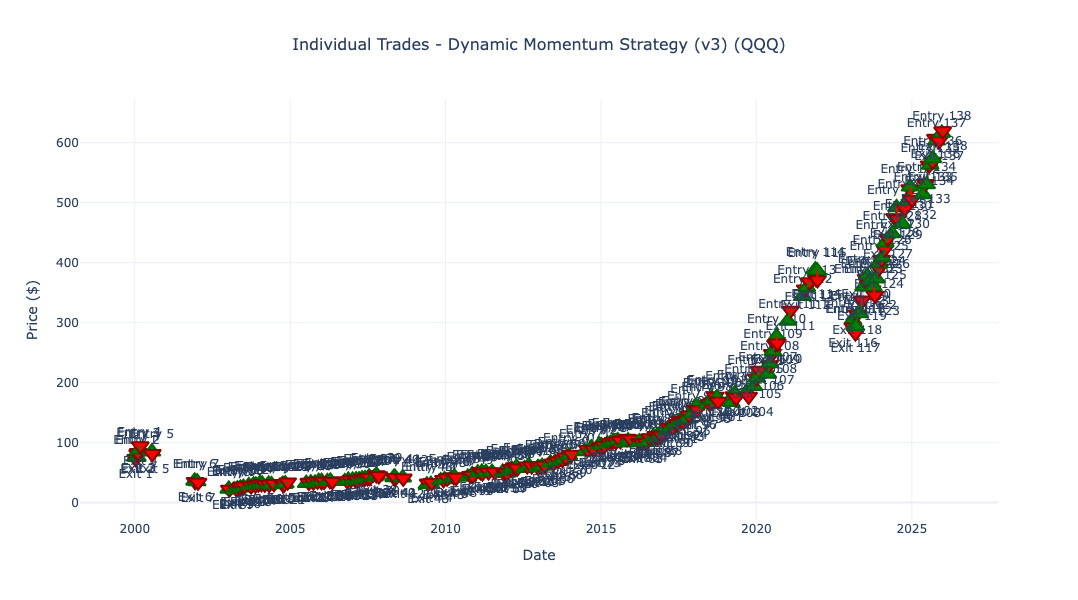


TRADE-BY-TRADE CHART DISPLAYED
This chart shows all trades overlaid. Use zoom to focus on specific trades.
Green lines = Profitable trades
Red lines = Losing trades


In [151]:
# Detailed trade-by-trade performance chart (zoomed view of individual trades)
if len(results_dynamic['trades']) > 0:
    trades_df = results_dynamic['trades'].copy()
    
    # Create a figure showing each trade with entry/exit points
    fig = go.Figure()
    
    # For each trade, plot the price action around entry/exit
    for idx, trade in trades_df.iterrows():
        entry_date = pd.to_datetime(trade['entry_date'])
        exit_date = pd.to_datetime(trade['exit_date'])
        
        # Get price data for this trade period (extend 5 days before entry and after exit for context)
        trade_start = entry_date - pd.Timedelta(days=5)
        trade_end = exit_date + pd.Timedelta(days=5)
        
        trade_data = data_backtest[
            (data_backtest['date'] >= trade_start) & 
            (data_backtest['date'] <= trade_end)
        ].copy()
        
        if len(trade_data) > 0:
            price_col = results_dynamic['price_col']
            
            # Add candlestick for this trade period
            fig.add_trace(
                go.Candlestick(
                    x=trade_data['date'],
                    open=trade_data['open'],
                    high=trade_data['high'],
                    low=trade_data['low'],
                    close=trade_data[price_col],
                    name=f"Trade {idx+1}",
                    increasing_line_color='#26a69a',
                    decreasing_line_color='#ef5350',
                    showlegend=False,
                    opacity=0.3
                )
            )
            
            # Mark entry point
            fig.add_trace(
                go.Scatter(
                    x=[entry_date],
                    y=[trade['entry_price']],
                    mode='markers+text',
                    name=f"Entry {idx+1}",
                    marker=dict(
                        symbol='triangle-up',
                        size=15,
                        color='green',
                        line=dict(width=2, color='darkgreen')
                    ),
                    text=[f"Entry {idx+1}"],
                    textposition="top center",
                    showlegend=False,
                    hovertemplate=f'<b>Trade {idx+1} Entry</b><br>Date: %{{x}}<br>Price: $%{{y:.2f}}<br>PnL: {trade["pnl_pct"]:.2f}%<extra></extra>'
                )
            )
            
            # Mark exit point
            fig.add_trace(
                go.Scatter(
                    x=[exit_date],
                    y=[trade['exit_price']],
                    mode='markers+text',
                    name=f"Exit {idx+1}",
                    marker=dict(
                        symbol='triangle-down',
                        size=15,
                        color='red',
                        line=dict(width=2, color='darkred')
                    ),
                    text=[f"Exit {idx+1}"],
                    textposition="bottom center",
                    showlegend=False,
                    hovertemplate=f'<b>Trade {idx+1} Exit</b><br>Date: %{{x}}<br>Price: $%{{y:.2f}}<br>Reason: {trade["exit_reason"]}<br>PnL: {trade["pnl_pct"]:.2f}%<extra></extra>'
                )
            )
            
            # Draw line connecting entry to exit
            fig.add_trace(
                go.Scatter(
                    x=[entry_date, exit_date],
                    y=[trade['entry_price'], trade['exit_price']],
                    mode='lines',
                    name=f"Trade {idx+1}",
                    line=dict(
                        color='green' if trade['pnl'] > 0 else 'red',
                        width=2,
                        dash='dash'
                    ),
                    showlegend=False,
                    hovertemplate=f'<b>Trade {idx+1}</b><br>PnL: {trade["pnl_pct"]:.2f}%<br>Hold: {trade["hold_days"]} days<extra></extra>'
                )
            )
    
    # Update layout
    fig.update_layout(
        title=dict(
            text=f'Individual Trades - Dynamic Momentum Strategy (v3) ({ticker})',
            x=0.5,
            font=dict(size=16)
        ),
        xaxis_rangeslider_visible=False,
        height=600,
        template='plotly_white',
        hovermode='closest',
        showlegend=False
    )
    
    fig.update_xaxes(title_text="Date")
    fig.update_yaxes(title_text="Price ($)")
    
    fig.show()
    
    print(f"\n{'='*60}")
    print("TRADE-BY-TRADE CHART DISPLAYED")
    print(f"{'='*60}")
    print("This chart shows all trades overlaid. Use zoom to focus on specific trades.")
    print("Green lines = Profitable trades")
    print("Red lines = Losing trades")
    print(f"{'='*60}")
else:
    print("No trades available for detailed charting.")


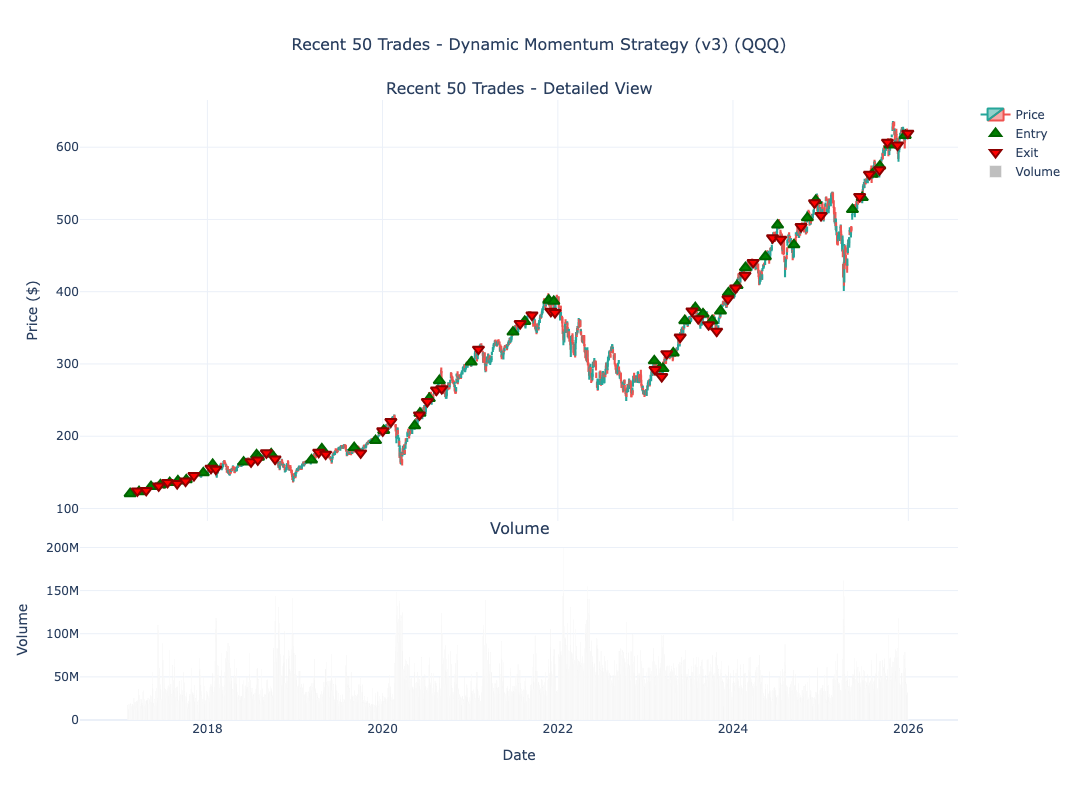


RECENT 50 TRADES CHART DISPLAYED
This focused view shows the most recent 50 trades for detailed analysis.
Use zoom and pan tools to examine individual trades closely.


In [152]:
# Create a focused chart for the most recent 50 trades (for detailed analysis)
if len(results_dynamic['trades']) > 0:
    trades_df = results_dynamic['trades'].copy()
    
    # Get the most recent 50 trades
    recent_trades = trades_df.tail(50).copy()
    
    # Find the date range for these trades
    all_dates = []
    for _, trade in recent_trades.iterrows():
        entry_date = pd.to_datetime(trade['entry_date'])
        exit_date = pd.to_datetime(trade['exit_date'])
        all_dates.extend([entry_date, exit_date])
    
    if len(all_dates) > 0:
        min_date = min(all_dates) - pd.Timedelta(days=10)
        max_date = max(all_dates) + pd.Timedelta(days=10)
        
        # Get price data for this period
        recent_data = data_backtest[
            (data_backtest['date'] >= min_date) & 
            (data_backtest['date'] <= max_date)
        ].copy()
        
        if len(recent_data) > 0:
            price_col = results_dynamic['price_col']
            
            # Create subplots
            fig = make_subplots(
                rows=2, cols=1,
                shared_xaxes=True,
                vertical_spacing=0.03,
                row_heights=[0.7, 0.3],
                subplot_titles=('Recent 50 Trades - Detailed View', 'Volume'),
                specs=[[{"secondary_y": False}], [{"secondary_y": False}]]
            )
            
            # Add candlestick
            fig.add_trace(
                go.Candlestick(
                    x=recent_data['date'],
                    open=recent_data['open'],
                    high=recent_data['high'],
                    low=recent_data['low'],
                    close=recent_data[price_col],
                    name='Price',
                    increasing_line_color='#26a69a',
                    decreasing_line_color='#ef5350'
                ),
                row=1, col=1
            )
            
            # Add SMA200 if available
            if 'SMA200' in recent_data.columns:
                sma200_values = recent_data['SMA200'].values
                fig.add_trace(
                    go.Scatter(
                        x=recent_data['date'],
                        y=sma200_values,
                        name='SMA200',
                        line=dict(color='orange', width=1, dash='dash'),
                        opacity=0.7
                    ),
                    row=1, col=1
                )
            
            # Mark entry and exit points for recent trades
            entry_dates = pd.to_datetime(recent_trades['entry_date']).tolist()
            entry_prices = recent_trades['entry_price'].tolist()
            exit_dates = pd.to_datetime(recent_trades['exit_date']).tolist()
            exit_prices = recent_trades['exit_price'].tolist()
            exit_reasons = recent_trades['exit_reason'].tolist()
            pnl_pcts = recent_trades['pnl_pct'].tolist()
            
            # Add entry markers
            fig.add_trace(
                go.Scatter(
                    x=entry_dates,
                    y=entry_prices,
                    mode='markers',
                    name='Entry',
                    marker=dict(
                        symbol='triangle-up',
                        size=10,
                        color='green',
                        line=dict(width=2, color='darkgreen')
                    ),
                    hovertemplate='<b>Entry</b><br>Date: %{x}<br>Price: $%{y:.2f}<extra></extra>',
                    showlegend=True
                ),
                row=1, col=1
            )
            
            # Add exit markers with PnL info
            fig.add_trace(
                go.Scatter(
                    x=exit_dates,
                    y=exit_prices,
                    mode='markers',
                    name='Exit',
                    marker=dict(
                        symbol='triangle-down',
                        size=10,
                        color='red',
                        line=dict(width=2, color='darkred')
                    ),
                    hovertemplate='<b>Exit</b><br>Date: %{x}<br>Price: $%{y:.2f}<br>Reason: %{text}<br>PnL: %{customdata:.2f}%<extra></extra>',
                    text=exit_reasons,
                    customdata=pnl_pcts,
                    showlegend=True
                ),
                row=1, col=1
            )
            
            # Add volume
            fig.add_trace(
                go.Bar(
                    x=recent_data['date'],
                    y=recent_data['vol'],
                    name='Volume',
                    marker_color='rgba(128, 128, 128, 0.5)'
                ),
                row=2, col=1
            )
            
            # Update layout
            fig.update_layout(
                title=dict(
                    text=f'Recent 50 Trades - Dynamic Momentum Strategy (v3) ({ticker})',
                    x=0.5,
                    font=dict(size=16)
                ),
                xaxis_rangeslider_visible=False,
                height=800,
                template='plotly_white',
                hovermode='x unified',
                showlegend=True
            )
            
            fig.update_xaxes(title_text="Date", row=2, col=1)
            fig.update_yaxes(title_text="Price ($)", row=1, col=1)
            fig.update_yaxes(title_text="Volume", row=2, col=1)
            
            fig.show()
            
            print(f"\n{'='*60}")
            print("RECENT 50 TRADES CHART DISPLAYED")
            print(f"{'='*60}")
            print("This focused view shows the most recent 50 trades for detailed analysis.")
            print("Use zoom and pan tools to examine individual trades closely.")
            print(f"{'='*60}")
        else:
            print("No data available for the recent trades period.")
    else:
        print("No valid dates found in recent trades.")
else:
    print("No trades available for charting.")


# Backtest: Strategy 3 - Reversal Hammer (Long-Only)

**Strategy 3: Switches to bullish Hammer/Inverted Hammer for reversal signals, avoiding chase in trends. Uses QQQ ticker, v3 rules otherwise.**

This strategy focuses on reversal patterns instead of momentum continuation:
- Uses **CDLHAMMER** and **CDLINVERTEDHAMMER** patterns (bullish reversal signals)
- Designed to catch potential bottoms after declines
- Same entry/exit rules as Strategy 2 v3 (SMA200, Volume, RSI filters)
- Long-only approach to avoid chasing in downtrends


In [153]:
def backtest_reversal_hammer(data, initial_capital=10000, risk_per_trade=0.01, stop_loss_pct=0.04, take_profit_pct=0.07, max_hold_days=30):
    """
    Backtest the Reversal Hammer trading strategy (LONG-ONLY VERSION).
    
    Strategy Rules:
    - Long Entry: Bullish CDLHAMMER or CDLINVERTEDHAMMER (value > 0) AND Close > 200-day SMA 
                  AND Volume > 20-day average AND RSI(14) > 50
    - No short entries (long-only strategy)
    - Only trade when price is above 200-day SMA (no trades in downtrends)
    - Exit: Dynamic hold while Close > SMA200 (max 30 days) OR 4% stop-loss OR +7% take-profit
    - Position sizing: Risk 1% of current capital per trade (adjusted for 4% stop)
    
    Parameters:
    -----------
    data : pd.DataFrame
        DataFrame with columns: date, open, high, low, close, vol
    initial_capital : float
        Starting capital (default: $10,000)
    risk_per_trade : float
        Risk percentage per trade (default: 1% = 0.01)
    stop_loss_pct : float
        Stop-loss percentage from entry (default: 4% = 0.04)
    take_profit_pct : float
        Take-profit percentage from entry (default: 7% = 0.07)
    max_hold_days : int
        Maximum holding period in days (default: 30)
    
    Returns:
    --------
    dict : Dictionary containing backtest results and metrics
    """
    
    # Create a copy to avoid modifying original data
    df = data.copy()
    
    # Ensure we have enough data for 200-day SMA
    if len(df) < 200:
        return {
            'error': f'Insufficient data: need at least 200 days, got {len(df)}',
            'trades': [],
            'equity_curve': None
        }
    
    # Determine price column (use adjusted close if available)
    price_col = 'close'
    if 'Adj Close' in df.columns:
        price_col = 'Adj Close'
    elif 'adj_close' in df.columns:
        price_col = 'adj_close'
    
    # Calculate 200-day Simple Moving Average
    df['SMA200'] = df[price_col].rolling(window=200, min_periods=200).mean()
    
    # Calculate 20-day average volume
    df['Avg_Vol20'] = df['vol'].rolling(window=20, min_periods=20).mean()
    
    # Calculate RSI(14)
    df['RSI14'] = talib.RSI(df[price_col].values, timeperiod=14)
    
    # Detect candlestick patterns using TA-Lib (Reversal patterns)
    df['CDLHAMMER'] = talib.CDLHAMMER(df['open'].values, df['high'].values, 
                                      df['low'].values, df[price_col].values)
    df['CDLINVERTEDHAMMER'] = talib.CDLINVERTEDHAMMER(df['open'].values, df['high'].values, 
                                                      df['low'].values, df[price_col].values)
    
    # Determine long signals with all conditions
    # Long signal: bullish reversal pattern (value > 0) AND close > SMA200 AND volume > avg_vol20 AND RSI14 > 50
    long_condition = (
        ((df['CDLHAMMER'] > 0) | (df['CDLINVERTEDHAMMER'] > 0)) &
        (df[price_col] > df['SMA200']) &
        (df['vol'] > df['Avg_Vol20']) &
        (df['RSI14'] > 50) &
        (~df['SMA200'].isna()) &  # Ensure SMA200 is calculated
        (~df['RSI14'].isna())  # Ensure RSI14 is calculated
    )
    
    # Create long signal column: 1 (long entry), 0 (no signal)
    df['Long_Signal'] = 0
    df.loc[long_condition, 'Long_Signal'] = 1
    
    # Initialize trading variables
    capital = initial_capital
    position = None  # 'long' or None (no shorts)
    entry_price = None
    entry_date = None
    entry_index = None
    position_size = None  # Number of shares
    trades = []
    equity_curve = [capital]
    
    # Loop through data to simulate trades (start from index 200 to ensure SMA200 is available)
    for i in range(200, len(df)):
        current_price = df.loc[i, price_col]
        current_date = df.loc[i, 'date']
        current_high = df.loc[i, 'high']
        current_low = df.loc[i, 'low']
        current_sma200 = df.loc[i, 'SMA200']
        
        # Check for stop-loss if in position (long only)
        if position == 'long':
            # Long stop-loss: exit if price drops 4% below entry
            if current_low <= entry_price * (1 - stop_loss_pct):
                # Exit trade at stop-loss price
                exit_price = entry_price * (1 - stop_loss_pct)
                pnl = (exit_price - entry_price) / entry_price
                trade_value = capital + (position_size * (exit_price - entry_price))
                capital = trade_value
                
                trades.append({
                    'entry_date': entry_date,
                    'exit_date': current_date,
                    'entry_price': entry_price,
                    'exit_price': exit_price,
                    'position': position,
                    'position_size': position_size,
                    'pnl': pnl,
                    'pnl_pct': pnl * 100,
                    'pnl_dollar': position_size * (exit_price - entry_price),
                    'exit_reason': 'stop_loss',
                    'hold_days': (current_date - entry_date).days
                })
                
                position = None
                entry_price = None
                entry_date = None
                entry_index = None
                position_size = None
                continue  # Skip to next iteration
        
        # Check for take-profit if in position
        if position == 'long':
            # Take-profit: exit if price rises 7% above entry
            if current_high >= entry_price * (1 + take_profit_pct):
                # Exit trade at take-profit price
                exit_price = entry_price * (1 + take_profit_pct)
                pnl = (exit_price - entry_price) / entry_price
                trade_value = capital + (position_size * (exit_price - entry_price))
                capital = trade_value
                
                trades.append({
                    'entry_date': entry_date,
                    'exit_date': current_date,
                    'entry_price': entry_price,
                    'exit_price': exit_price,
                    'position': position,
                    'position_size': position_size,
                    'pnl': pnl,
                    'pnl_pct': pnl * 100,
                    'pnl_dollar': position_size * (exit_price - entry_price),
                    'exit_reason': 'take_profit',
                    'hold_days': (current_date - entry_date).days
                })
                
                position = None
                entry_price = None
                entry_date = None
                entry_index = None
                position_size = None
                continue  # Skip to next iteration
        
        # Check for exit conditions if in position
        if position == 'long':
            days_held = (current_date - entry_date).days
            
            # Exit if price drops below SMA200 (dynamic exit)
            if current_sma200 is not None and current_price < current_sma200:
                # Exit trade at current close
                pnl = (current_price - entry_price) / entry_price
                trade_value = capital + (position_size * (current_price - entry_price))
                capital = trade_value
                
                trades.append({
                    'entry_date': entry_date,
                    'exit_date': current_date,
                    'entry_price': entry_price,
                    'exit_price': current_price,
                    'position': position,
                    'position_size': position_size,
                    'pnl': pnl,
                    'pnl_pct': pnl * 100,
                    'pnl_dollar': position_size * (current_price - entry_price),
                    'exit_reason': 'below_sma200',
                    'hold_days': days_held
                })
                
                position = None
                entry_price = None
                entry_date = None
                entry_index = None
                position_size = None
                continue  # Skip to next iteration
            
            # Exit after max_hold_days (30 days)
            if days_held >= max_hold_days:
                # Exit trade at current close
                pnl = (current_price - entry_price) / entry_price
                trade_value = capital + (position_size * (current_price - entry_price))
                capital = trade_value
                
                trades.append({
                    'entry_date': entry_date,
                    'exit_date': current_date,
                    'entry_price': entry_price,
                    'exit_price': current_price,
                    'position': position,
                    'position_size': position_size,
                    'pnl': pnl,
                    'pnl_pct': pnl * 100,
                    'pnl_dollar': position_size * (current_price - entry_price),
                    'exit_reason': 'time_limit',
                    'hold_days': days_held
                })
                
                position = None
                entry_price = None
                entry_date = None
                entry_index = None
                position_size = None
                continue  # Skip to next iteration
        
        # Check for new entry signals (only if not in position, long-only, and price above SMA200)
        if position is None:
            signal = df.loc[i, 'Long_Signal']
            sma200_value = df.loc[i, 'SMA200']
            
            # Long entry signal only (and price must be above SMA200)
            if signal == 1 and sma200_value is not None and current_price > sma200_value:
                position = 'long'
                entry_price = current_price  # Enter at close of pattern candle
                entry_date = current_date
                entry_index = i
                
                # Calculate position size: risk 1% of capital
                # Position size = (capital * risk_per_trade) / (entry_price * stop_loss_pct)
                # Adjusted for 4% stop-loss
                position_size = int((capital * risk_per_trade) / (entry_price * stop_loss_pct))
                if position_size < 1:
                    position_size = 0  # Can't buy fractional shares
                    position = None
                    entry_price = None
                    entry_date = None
                    entry_index = None
        
        # Update equity curve (calculate current portfolio value)
        if position == 'long':
            current_value = capital + (position_size * (current_price - entry_price))
            equity_curve.append(current_value)
        else:
            equity_curve.append(capital)
    
    # Close any open position at the end
    if position == 'long':
        final_price = df.loc[len(df)-1, price_col]
        pnl = (final_price - entry_price) / entry_price
        trade_value = capital + (position_size * (final_price - entry_price))
        capital = trade_value
        
        trades.append({
            'entry_date': entry_date,
            'exit_date': df.loc[len(df)-1, 'date'],
            'entry_price': entry_price,
            'exit_price': final_price,
            'position': position,
            'position_size': position_size,
            'pnl': pnl,
            'pnl_pct': pnl * 100,
            'pnl_dollar': position_size * (final_price - entry_price),
            'exit_reason': 'end_of_data',
            'hold_days': (df.loc[len(df)-1, 'date'] - entry_date).days
        })
    
    # Calculate metrics
    if len(trades) > 0:
        trades_df = pd.DataFrame(trades)
        
        # Total return
        total_return = (capital - initial_capital) / initial_capital
        
        # Win rate
        winning_trades = trades_df[trades_df['pnl'] > 0]
        win_rate = len(winning_trades) / len(trades_df) if len(trades_df) > 0 else 0
        
        # Average win/loss
        avg_win = winning_trades['pnl'].mean() if len(winning_trades) > 0 else 0
        losing_trades = trades_df[trades_df['pnl'] <= 0]
        avg_loss = losing_trades['pnl'].mean() if len(losing_trades) > 0 else 0
        
        # Max drawdown
        equity_array = np.array(equity_curve)
        running_max = np.maximum.accumulate(equity_array)
        drawdown = (equity_array - running_max) / running_max
        max_drawdown = drawdown.min()
        
        # Sharpe ratio (assuming daily returns, risk-free rate = 0%)
        daily_returns = np.diff(equity_curve) / equity_curve[:-1]
        sharpe_ratio = np.mean(daily_returns) / np.std(daily_returns) * np.sqrt(252) if np.std(daily_returns) > 0 else 0
        
        # Total number of trades
        total_trades = len(trades_df)
        
        results = {
            'initial_capital': initial_capital,
            'final_capital': capital,
            'total_return': total_return,
            'total_return_pct': total_return * 100,
            'total_trades': total_trades,
            'win_rate': win_rate,
            'win_rate_pct': win_rate * 100,
            'avg_win': avg_win,
            'avg_win_pct': avg_win * 100,
            'avg_loss': avg_loss,
            'avg_loss_pct': avg_loss * 100,
            'max_drawdown': max_drawdown,
            'max_drawdown_pct': max_drawdown * 100,
            'sharpe_ratio': sharpe_ratio,
            'trades': trades_df,
            'equity_curve': equity_curve,
            'dates': df['date'].tolist(),
            'price_col': price_col
        }
    else:
        results = {
            'initial_capital': initial_capital,
            'final_capital': capital,
            'total_return': 0,
            'total_return_pct': 0,
            'total_trades': 0,
            'win_rate': 0,
            'win_rate_pct': 0,
            'avg_win': 0,
            'avg_win_pct': 0,
            'avg_loss': 0,
            'avg_loss_pct': 0,
            'max_drawdown': 0,
            'max_drawdown_pct': 0,
            'sharpe_ratio': 0,
            'trades': pd.DataFrame(),
            'equity_curve': equity_curve,
            'dates': df['date'].tolist(),
            'price_col': price_col
        }
    
    return results


In [154]:
# Run backtest for Reversal Hammer Strategy (Strategy 3)
print("="*60)
print("Running backtest for Reversal Hammer Strategy (Strategy 3)...")
print("="*60)
print("Strategy 3: Bullish Hammer/Inverted Hammer reversal patterns")
print("Entry: Pattern + Close > SMA200 + Volume > 20-day avg + RSI(14) > 50")
print("Exit: Dynamic hold (while > SMA200, max 30d) OR 4% stop OR +7% target")
print("="*60)

# Use full available data (1990 onwards, as much as possible)
results_hammer = backtest_reversal_hammer(
    data=data_backtest,
    initial_capital=10000,
    risk_per_trade=0.01,
    stop_loss_pct=0.04,  # 4% stop-loss
    take_profit_pct=0.07,  # 7% take-profit
    max_hold_days=30  # Maximum 30-day hold period
)

# Display results
print(f"\n{'='*60}")
print("BACKTEST RESULTS - REVERSAL HAMMER STRATEGY (Strategy 3)")
print(f"{'='*60}")
print(f"Initial Capital: ${results_hammer['initial_capital']:,.2f}")
print(f"Final Capital: ${results_hammer['final_capital']:,.2f}")
if results_hammer['total_return_pct'] >= 0:
    print(f"Total Return: +{results_hammer['total_return_pct']:.2f}%")
else:
    print(f"Total Return: {results_hammer['total_return_pct']:.2f}%")
print(f"\nTotal Trades: {results_hammer['total_trades']}")
print(f"Win Rate: {results_hammer['win_rate_pct']:.2f}%")
print(f"Average Win: {results_hammer['avg_win_pct']:.2f}%")
print(f"Average Loss: {results_hammer['avg_loss_pct']:.2f}%")
print(f"Max Drawdown: {results_hammer['max_drawdown_pct']:.2f}%")
print(f"Sharpe Ratio: {results_hammer['sharpe_ratio']:.2f}")
print(f"\nNote: Strategy 3 uses reversal patterns (Hammer/Inverted Hammer) instead of momentum patterns")
print(f"{'='*60}")


Running backtest for Reversal Hammer Strategy (Strategy 3)...
Strategy 3: Bullish Hammer/Inverted Hammer reversal patterns
Entry: Pattern + Close > SMA200 + Volume > 20-day avg + RSI(14) > 50
Exit: Dynamic hold (while > SMA200, max 30d) OR 4% stop OR +7% target

BACKTEST RESULTS - REVERSAL HAMMER STRATEGY (Strategy 3)
Initial Capital: $10,000.00
Final Capital: $10,452.38
Total Return: +4.52%

Total Trades: 30
Win Rate: 53.33%
Average Win: 4.42%
Average Loss: -3.63%
Max Drawdown: -6.07%
Sharpe Ratio: 0.17

Note: Strategy 3 uses reversal patterns (Hammer/Inverted Hammer) instead of momentum patterns



REVERSAL HAMMER STRATEGY (Strategy 3) - PERFORMANCE SUMMARY
Metric                         Value               
--------------------------------------------------
Initial Capital                $10,000.00
Final Capital                  $10,452.38
Total Return                   +4.52%
Total Trades                   30
Win Rate                       53.33%
Average Win                    4.42%
Average Loss                   -3.63%
Max Drawdown                   -6.07%
Sharpe Ratio                   0.17


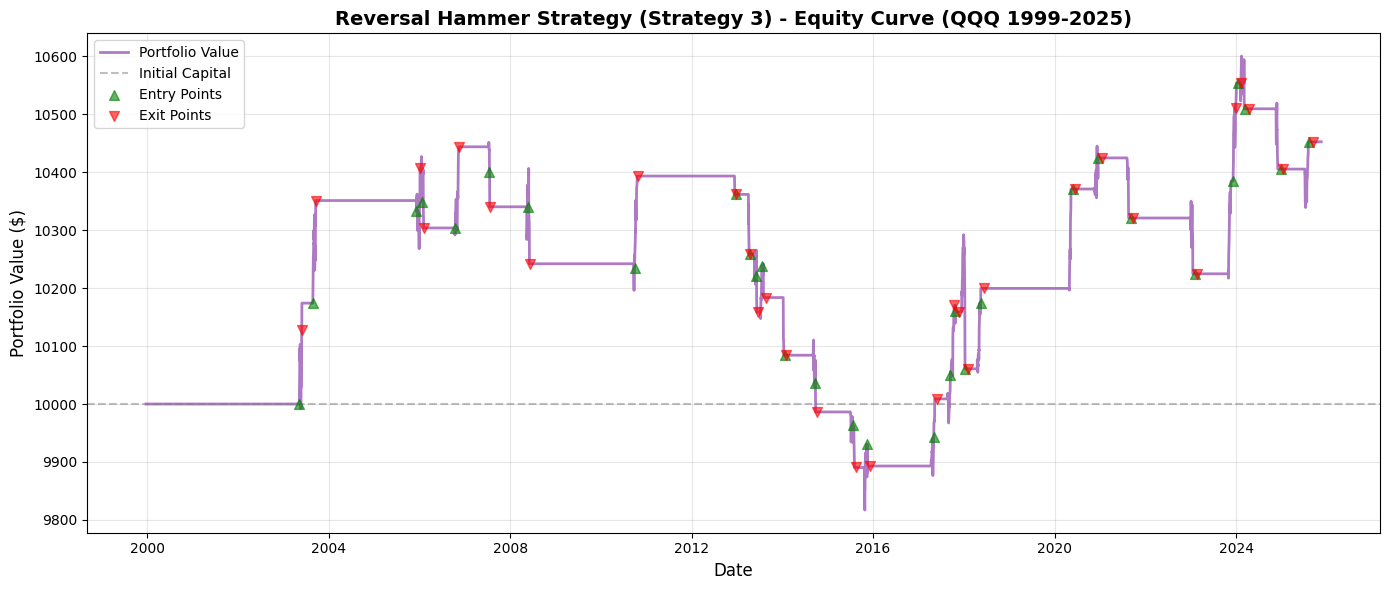

In [155]:
# Display Reversal Hammer Strategy (Strategy 3) Performance
if len(data_backtest) > 0:
    print(f"\n{'='*60}")
    print("REVERSAL HAMMER STRATEGY (Strategy 3) - PERFORMANCE SUMMARY")
    print(f"{'='*60}")
    print(f"{'Metric':<30} {'Value':<20}")
    print(f"{'-'*50}")
    print(f"{'Initial Capital':<30} ${results_hammer['initial_capital']:,.2f}")
    print(f"{'Final Capital':<30} ${results_hammer['final_capital']:,.2f}")
    
    # Format returns with + sign for positive
    strategy_return_str = f"+{results_hammer['total_return_pct']:.2f}%" if results_hammer['total_return_pct'] >= 0 else f"{results_hammer['total_return_pct']:.2f}%"
    print(f"{'Total Return':<30} {strategy_return_str}")
    print(f"{'Total Trades':<30} {results_hammer['total_trades']}")
    print(f"{'Win Rate':<30} {results_hammer['win_rate_pct']:.2f}%")
    print(f"{'Average Win':<30} {results_hammer['avg_win_pct']:.2f}%")
    print(f"{'Average Loss':<30} {results_hammer['avg_loss_pct']:.2f}%")
    print(f"{'Max Drawdown':<30} {results_hammer['max_drawdown_pct']:.2f}%")
    print(f"{'Sharpe Ratio':<30} {results_hammer['sharpe_ratio']:.2f}")
    print(f"{'='*60}")
    
    # Plot equity curve
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Strategy equity curve - align dates with equity curve
    dates_extended = results_hammer['dates'][200:]
    # Ensure lengths match (equity_curve has initial capital + one per day, so skip first element)
    if len(results_hammer['equity_curve']) == len(dates_extended) + 1:
        ax.plot(dates_extended, results_hammer['equity_curve'][1:], linewidth=2, color='#9B59B6', label='Portfolio Value', alpha=0.8)
        equity_curve_aligned = results_hammer['equity_curve'][1:]
    else:
        min_len = min(len(dates_extended), len(results_hammer['equity_curve']))
        ax.plot(dates_extended[:min_len], results_hammer['equity_curve'][:min_len], linewidth=2, color='#9B59B6', label='Portfolio Value', alpha=0.8)
        equity_curve_aligned = results_hammer['equity_curve'][:min_len]
    
    ax.axhline(y=results_hammer['initial_capital'], color='gray', linestyle='--', alpha=0.5, label='Initial Capital')
    
    # Mark entry and exit points
    if len(results_hammer['trades']) > 0:
        trades_df = results_hammer['trades']
        entry_dates = pd.to_datetime(trades_df['entry_date']).tolist()
        exit_dates = pd.to_datetime(trades_df['exit_date']).tolist()
        
        # Find entry equity values
        entry_equity = []
        for ed in entry_dates:
            try:
                idx = dates_extended.index(ed)
                if idx < len(equity_curve_aligned):
                    entry_equity.append(equity_curve_aligned[idx])
                else:
                    entry_equity.append(results_hammer['initial_capital'])
            except:
                entry_equity.append(results_hammer['initial_capital'])
        
        # Find exit equity values
        exit_equity = []
        for ed in exit_dates:
            try:
                idx = dates_extended.index(ed)
                if idx < len(equity_curve_aligned):
                    exit_equity.append(equity_curve_aligned[idx])
                else:
                    exit_equity.append(results_hammer['initial_capital'])
            except:
                exit_equity.append(results_hammer['initial_capital'])
        
        ax.scatter(entry_dates, entry_equity, color='green', marker='^', s=50, alpha=0.6, label='Entry Points', zorder=5)
        ax.scatter(exit_dates, exit_equity, color='red', marker='v', s=50, alpha=0.6, label='Exit Points', zorder=5)
    
    # Get actual date range from data
    date_range_str = f"{data_backtest['date'].min().year}-{data_backtest['date'].max().year}"
    ax.set_ylabel('Portfolio Value ($)', fontsize=12)
    ax.set_xlabel('Date', fontsize=12)
    ax.set_title(f'Reversal Hammer Strategy (Strategy 3) - Equity Curve ({ticker} {date_range_str})', fontsize=14, fontweight='bold')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("No data available for plotting.")


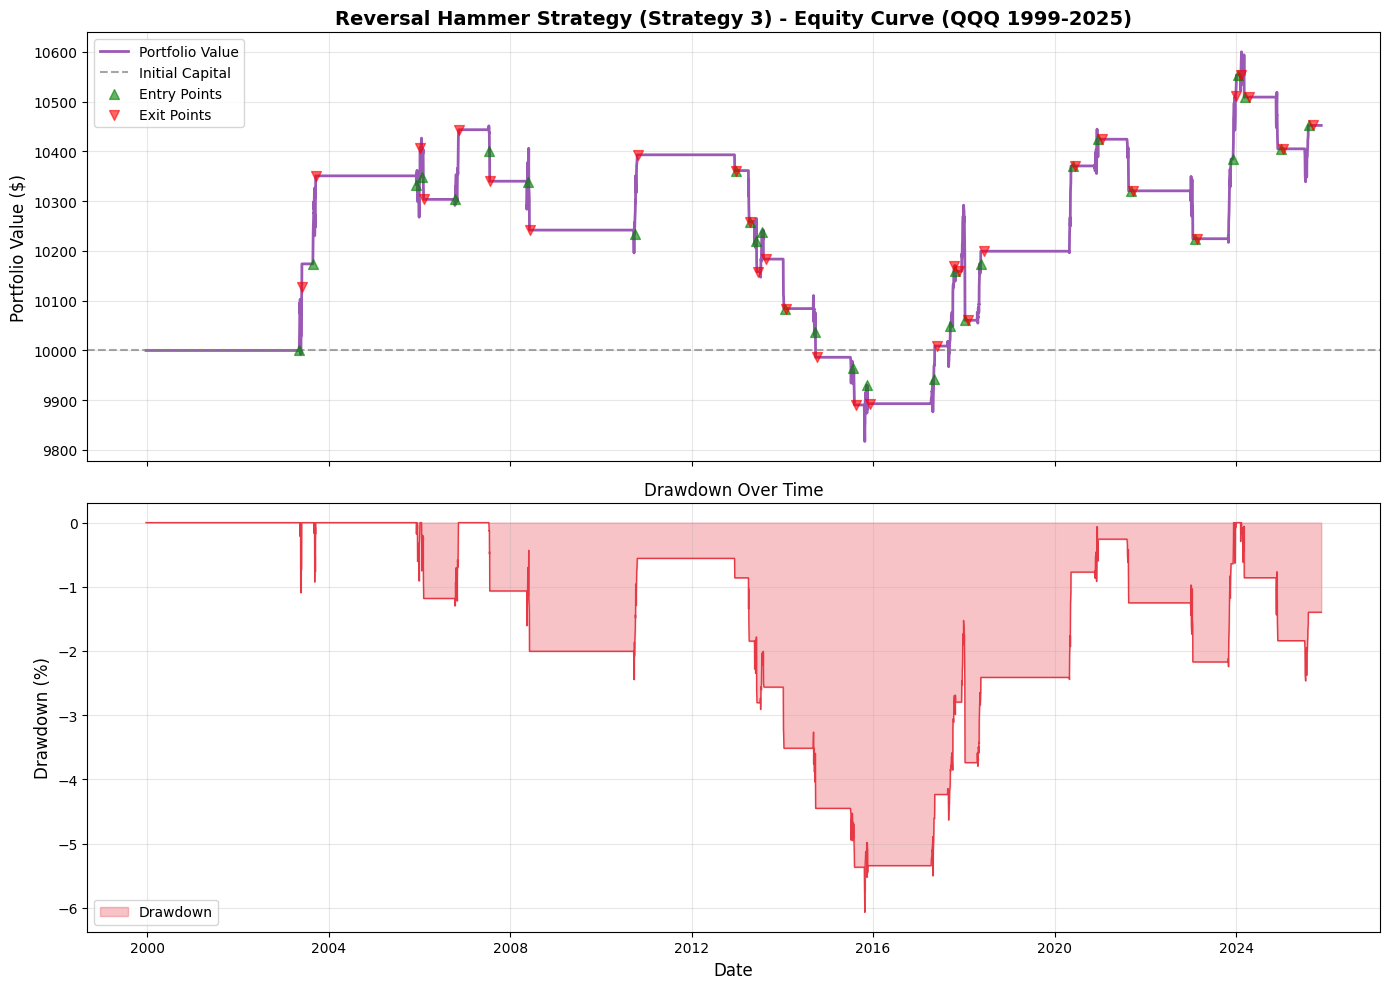


ADDITIONAL STATISTICS
Best Day: $89.53
Worst Day: $-98.55
Final Drawdown: -1.40%
Max Drawdown Date: 2015-10-26 00:00:00


In [156]:
# Plot equity curve with drawdown for Reversal Hammer Strategy (Strategy 3)
if len(results_hammer['equity_curve']) > 0:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
    
    # Equity curve
    dates_extended = results_hammer['dates'][200:]
    # Ensure lengths match
    if len(results_hammer['equity_curve']) == len(dates_extended) + 1:
        ax1.plot(dates_extended, results_hammer['equity_curve'][1:], linewidth=2, color='#9B59B6', label='Portfolio Value')
        equity_curve_aligned = results_hammer['equity_curve'][1:]
    else:
        min_len = min(len(dates_extended), len(results_hammer['equity_curve']))
        ax1.plot(dates_extended[:min_len], results_hammer['equity_curve'][:min_len], linewidth=2, color='#9B59B6', label='Portfolio Value')
        equity_curve_aligned = results_hammer['equity_curve'][:min_len]
    
    ax1.axhline(y=results_hammer['initial_capital'], color='gray', linestyle='--', alpha=0.7, label='Initial Capital')
    
    # Mark entry and exit points if trades exist
    if len(results_hammer['trades']) > 0:
        trades_df = results_hammer['trades']
        entry_dates = pd.to_datetime(trades_df['entry_date']).tolist()
        exit_dates = pd.to_datetime(trades_df['exit_date']).tolist()
        
        # Find corresponding equity values at entry/exit dates
        entry_equity = []
        for ed in entry_dates:
            try:
                idx = dates_extended.index(ed)
                if idx < len(equity_curve_aligned):
                    entry_equity.append(equity_curve_aligned[idx])
                else:
                    entry_equity.append(results_hammer['initial_capital'])
            except:
                entry_equity.append(results_hammer['initial_capital'])
        
        exit_equity = []
        for ed in exit_dates:
            try:
                idx = dates_extended.index(ed)
                if idx < len(equity_curve_aligned):
                    exit_equity.append(equity_curve_aligned[idx])
                else:
                    exit_equity.append(results_hammer['initial_capital'])
            except:
                exit_equity.append(results_hammer['initial_capital'])
        
        ax1.scatter(entry_dates, entry_equity, color='green', marker='^', s=50, alpha=0.6, label='Entry Points', zorder=5)
        ax1.scatter(exit_dates, exit_equity, color='red', marker='v', s=50, alpha=0.6, label='Exit Points', zorder=5)
    
    # Get actual date range from data
    date_range_str = f"{data_backtest['date'].min().year}-{data_backtest['date'].max().year}"
    ax1.set_ylabel('Portfolio Value ($)', fontsize=12)
    ax1.set_title(f'Reversal Hammer Strategy (Strategy 3) - Equity Curve ({ticker} {date_range_str})', fontsize=14, fontweight='bold')
    ax1.legend(loc='best')
    ax1.grid(True, alpha=0.3)
    
    # Drawdown chart - use aligned equity curve
    equity_array = np.array(equity_curve_aligned)
    running_max = np.maximum.accumulate(equity_array)
    drawdown = (equity_array - running_max) / running_max * 100
    
    # Ensure dates_extended and drawdown have the same length
    min_len = min(len(dates_extended), len(drawdown))
    dates_drawdown = dates_extended[:min_len]
    drawdown_aligned = drawdown[:min_len]
    
    ax2.fill_between(dates_drawdown, drawdown_aligned, 0, color='#E63946', alpha=0.3, label='Drawdown')
    ax2.plot(dates_drawdown, drawdown_aligned, color='#E63946', linewidth=1)
    ax2.set_ylabel('Drawdown (%)', fontsize=12)
    ax2.set_xlabel('Date', fontsize=12)
    ax2.set_title('Drawdown Over Time', fontsize=12)
    ax2.legend(loc='best')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print additional statistics
    print(f"\n{'='*60}")
    print("ADDITIONAL STATISTICS")
    print(f"{'='*60}")
    daily_changes = np.diff(equity_curve_aligned)
    print(f"Best Day: ${max(daily_changes):,.2f}")
    print(f"Worst Day: ${min(daily_changes):,.2f}")
    print(f"Final Drawdown: {drawdown_aligned[-1]:.2f}%")
    print(f"Max Drawdown Date: {dates_drawdown[np.argmin(drawdown_aligned)]}")
else:
    print("No equity curve data to plot.")


In [157]:
# Trade analysis by exit reason for Reversal Hammer Strategy (Strategy 3)
if len(results_hammer['trades']) > 0:
    trades_df = results_hammer['trades']
    
    print(f"\n{'='*60}")
    print("TRADE ANALYSIS BY EXIT REASON (Strategy 3)")
    print(f"{'='*60}")
    
    exit_reason_stats = trades_df.groupby('exit_reason').agg({
        'pnl': ['count', 'mean', 'sum'],
        'hold_days': 'mean',
        'pnl_dollar': 'sum'
    }).round(4)
    
    exit_reason_stats.columns = ['Count', 'Avg PnL', 'Total PnL', 'Avg Hold Days', 'Total PnL ($)']
    exit_reason_stats['Avg PnL %'] = exit_reason_stats['Avg PnL'] * 100
    exit_reason_stats['Total PnL %'] = exit_reason_stats['Total PnL'] * 100
    
    print(exit_reason_stats.to_string())
    
    # Display all trades
    print(f"\n{'='*60}")
    print("ALL TRADES (Strategy 3)")
    print(f"{'='*60}")
    trades_display = trades_df.copy()
    # Format dates for better readability
    trades_display['entry_date'] = pd.to_datetime(trades_display['entry_date']).dt.strftime('%Y-%m-%d')
    trades_display['exit_date'] = pd.to_datetime(trades_display['exit_date']).dt.strftime('%Y-%m-%d')
    # Round numeric columns
    trades_display['entry_price'] = trades_display['entry_price'].round(2)
    trades_display['exit_price'] = trades_display['exit_price'].round(2)
    trades_display['pnl_pct'] = trades_display['pnl_pct'].round(2)
    trades_display['pnl_dollar'] = trades_display['pnl_dollar'].round(2)
    print(trades_display.to_string(index=False))
else:
    print("No trades to analyze.")



TRADE ANALYSIS BY EXIT REASON (Strategy 3)
              Count  Avg PnL  Total PnL  Avg Hold Days  Total PnL ($)  Avg PnL %  Total PnL %
exit_reason                                                                                  
below_sma200      2  -0.0255    -0.0511        13.0000      -129.9737      -2.55        -5.11
stop_loss        11  -0.0400    -0.4400        16.1818     -1106.4960      -4.00       -44.00
take_profit       5   0.0700     0.3500        21.0000       851.7431       7.00        35.00
time_limit       12   0.0284     0.3402        30.9167       837.1057       2.84        34.02

ALL TRADES (Strategy 3)
entry_date  exit_date  entry_price  exit_price position  position_size       pnl  pnl_pct  pnl_dollar  exit_reason  hold_days
2003-05-08 2003-05-29        23.46       25.10     long            106  0.070000     7.00      174.04  take_profit         21
2003-08-26 2003-09-18        27.48       29.41     long             92  0.070000     7.00      177.00  take_profit 

In [158]:
# Export all trades to CSV (Reversal Hammer Strategy 3)
if len(results_hammer['trades']) > 0:
    trades_export = results_hammer['trades'].copy()
    
    # Ensure dates are in proper format
    trades_export['entry_date'] = pd.to_datetime(trades_export['entry_date'])
    trades_export['exit_date'] = pd.to_datetime(trades_export['exit_date'])
    
    # Create filename with timestamp
    from datetime import datetime
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    filename = f'../data/strategy3_reversal_hammer_trades_{ticker}_{timestamp}.csv'
    
    # Export to CSV
    trades_export.to_csv(filename, index=False)
    
    print(f"\n{'='*60}")
    print(f"Trades exported to: {filename}")
    print(f"Total trades exported: {len(trades_export)}")
    print(f"{'='*60}")
    
    # Also create a summary CSV with key metrics
    summary_data = {
        'Metric': [
            'Initial Capital',
            'Final Capital',
            'Total Return (%)',
            'Total Trades',
            'Win Rate (%)',
            'Average Win (%)',
            'Average Loss (%)',
            'Max Drawdown (%)',
            'Sharpe Ratio'
        ],
        'Value': [
            results_hammer['initial_capital'],
            results_hammer['final_capital'],
            results_hammer['total_return_pct'],
            results_hammer['total_trades'],
            results_hammer['win_rate_pct'],
            results_hammer['avg_win_pct'],
            results_hammer['avg_loss_pct'],
            results_hammer['max_drawdown_pct'],
            results_hammer['sharpe_ratio']
        ]
    }
    summary_df = pd.DataFrame(summary_data)
    summary_filename = f'../data/strategy3_reversal_hammer_summary_{ticker}_{timestamp}.csv'
    summary_df.to_csv(summary_filename, index=False)
    print(f"Summary exported to: {summary_filename}")
    print(f"{'='*60}")
else:
    print("\nNo trades to export.")



Trades exported to: ../data/strategy3_reversal_hammer_trades_QQQ_20260218_122719.csv
Total trades exported: 30
Summary exported to: ../data/strategy3_reversal_hammer_summary_QQQ_20260218_122719.csv


# TradingView-Style Interactive Chart for Reversal Hammer Strategy

Interactive candlestick chart with zoom capabilities to see individual trades at microscopic level.


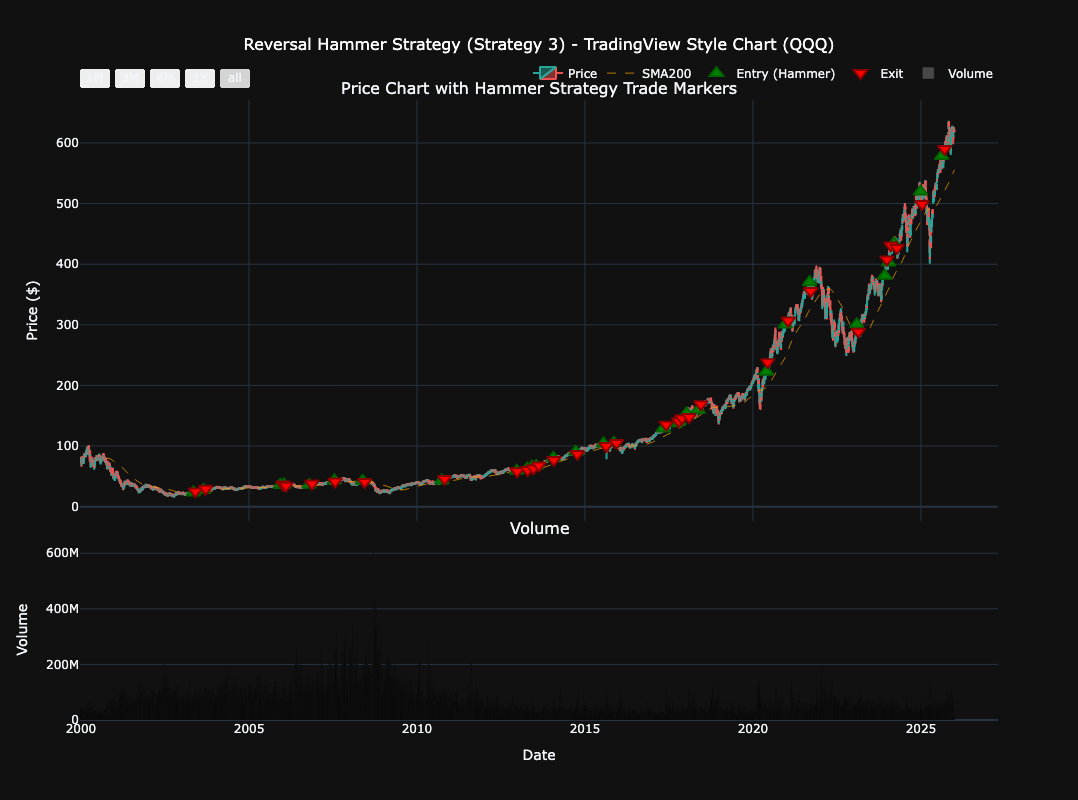


INTERACTIVE CHART DISPLAYED - REVERSAL HAMMER STRATEGY
Use the zoom tools (top right) to zoom into specific time periods
Hover over entry/exit markers to see trade details
Green triangles = Entry points (Hammer/Inverted Hammer patterns)
Red triangles = Exit points


In [159]:
# TradingView-style interactive candlestick chart with trade markers for Reversal Hammer Strategy
if len(results_hammer['trades']) > 0 and len(data_backtest) > 0:
    # Prepare data for plotting
    price_col = results_hammer['price_col']
    
    # Get data from index 200 onwards (where strategy starts)
    plot_data = data_backtest.iloc[200:].copy()
    plot_data = plot_data.reset_index(drop=True)
    
    # Create subplots: price chart on top, volume on bottom
    fig = make_subplots(
        rows=2, cols=1,
        shared_xaxes=True,
        vertical_spacing=0.03,
        row_heights=[0.7, 0.3],
        subplot_titles=('Price Chart with Hammer Strategy Trade Markers', 'Volume'),
        specs=[[{"secondary_y": False}], [{"secondary_y": False}]]
    )
    
    # Add candlestick chart
    fig.add_trace(
        go.Candlestick(
            x=plot_data['date'],
            open=plot_data['open'],
            high=plot_data['high'],
            low=plot_data['low'],
            close=plot_data[price_col],
            name='Price',
            increasing_line_color='#26a69a',
            decreasing_line_color='#ef5350'
        ),
        row=1, col=1
    )
    
    # Add 200-day SMA
    if 'SMA200' in plot_data.columns or len(plot_data) >= 200:
        # Calculate SMA200 for plot data
        sma200 = plot_data[price_col].rolling(window=200, min_periods=200).mean()
        if len(sma200) == len(plot_data):
            fig.add_trace(
                go.Scatter(
                    x=plot_data['date'],
                    y=sma200,
                    name='SMA200',
                    line=dict(color='orange', width=1, dash='dash'),
                    opacity=0.7
                ),
                row=1, col=1
            )
    
    # Mark entry points (green triangles)
    trades_df = results_hammer['trades']
    entry_dates = pd.to_datetime(trades_df['entry_date']).tolist()
    entry_prices = trades_df['entry_price'].tolist()
    
    # Filter entry points that are in the plot data range
    plot_start_date = plot_data['date'].iloc[0]
    plot_end_date = plot_data['date'].iloc[-1]
    
    valid_entries = []
    valid_entry_prices = []
    for ed, ep in zip(entry_dates, entry_prices):
        if plot_start_date <= ed <= plot_end_date:
            valid_entries.append(ed)
            valid_entry_prices.append(ep)
    
    if len(valid_entries) > 0:
        fig.add_trace(
            go.Scatter(
                x=valid_entries,
                y=valid_entry_prices,
                mode='markers',
                name='Entry (Hammer)',
                marker=dict(
                    symbol='triangle-up',
                    size=12,
                    color='green',
                    line=dict(width=2, color='darkgreen')
                ),
                hovertemplate='<b>Entry (Hammer Pattern)</b><br>Date: %{x}<br>Price: $%{y:.2f}<extra></extra>'
            ),
            row=1, col=1
        )
    
    # Mark exit points (red triangles down)
    exit_dates = pd.to_datetime(trades_df['exit_date']).tolist()
    exit_prices = trades_df['exit_price'].tolist()
    exit_reasons = trades_df['exit_reason'].tolist()
    pnl_pcts = trades_df['pnl_pct'].tolist()
    
    valid_exits = []
    valid_exit_prices = []
    valid_exit_reasons = []
    valid_pnl_pcts = []
    for ed, ep, er, pnl in zip(exit_dates, exit_prices, exit_reasons, pnl_pcts):
        if plot_start_date <= ed <= plot_end_date:
            valid_exits.append(ed)
            valid_exit_prices.append(ep)
            valid_exit_reasons.append(er)
            valid_pnl_pcts.append(pnl)
    
    if len(valid_exits) > 0:
        fig.add_trace(
            go.Scatter(
                x=valid_exits,
                y=valid_exit_prices,
                mode='markers',
                name='Exit',
                marker=dict(
                    symbol='triangle-down',
                    size=12,
                    color='red',
                    line=dict(width=2, color='darkred')
                ),
                hovertemplate='<b>Exit</b><br>Date: %{x}<br>Price: $%{y:.2f}<br>Reason: %{text}<br>PnL: %{customdata:.2f}%<extra></extra>',
                text=valid_exit_reasons,
                customdata=valid_pnl_pcts
            ),
            row=1, col=1
        )
    
    # Add volume bars
    fig.add_trace(
        go.Bar(
            x=plot_data['date'],
            y=plot_data['vol'],
            name='Volume',
            marker_color='rgba(128, 128, 128, 0.5)'
        ),
        row=2, col=1
    )
    
    # Update layout for TradingView-style appearance
    fig.update_layout(
        title=dict(
            text=f'Reversal Hammer Strategy (Strategy 3) - TradingView Style Chart ({ticker})',
            x=0.5,
            font=dict(size=16, color='white')
        ),
        xaxis_rangeslider_visible=False,
        height=800,
        template='plotly_dark',
        hovermode='x unified',
        showlegend=True,
        legend=dict(
            orientation="h",
            yanchor="bottom",
            y=1.02,
            xanchor="right",
            x=1
        )
    )
    
    # Update axes
    fig.update_xaxes(title_text="Date", row=2, col=1)
    fig.update_yaxes(title_text="Price ($)", row=1, col=1)
    fig.update_yaxes(title_text="Volume", row=2, col=1)
    
    # Enable zoom and pan
    fig.update_layout(
        xaxis=dict(
            rangeselector=dict(
                buttons=list([
                    dict(count=1, label="1M", step="month", stepmode="backward"),
                    dict(count=3, label="3M", step="month", stepmode="backward"),
                    dict(count=6, label="6M", step="month", stepmode="backward"),
                    dict(count=1, label="1Y", step="year", stepmode="backward"),
                    dict(step="all")
                ])
            ),
            rangeslider=dict(visible=False),
            type="date"
        )
    )
    
    fig.show()
    
    print(f"\n{'='*60}")
    print("INTERACTIVE CHART DISPLAYED - REVERSAL HAMMER STRATEGY")
    print(f"{'='*60}")
    print("Use the zoom tools (top right) to zoom into specific time periods")
    print("Hover over entry/exit markers to see trade details")
    print("Green triangles = Entry points (Hammer/Inverted Hammer patterns)")
    print("Red triangles = Exit points")
    print(f"{'='*60}")
else:
    print("No trades or data available for charting.")


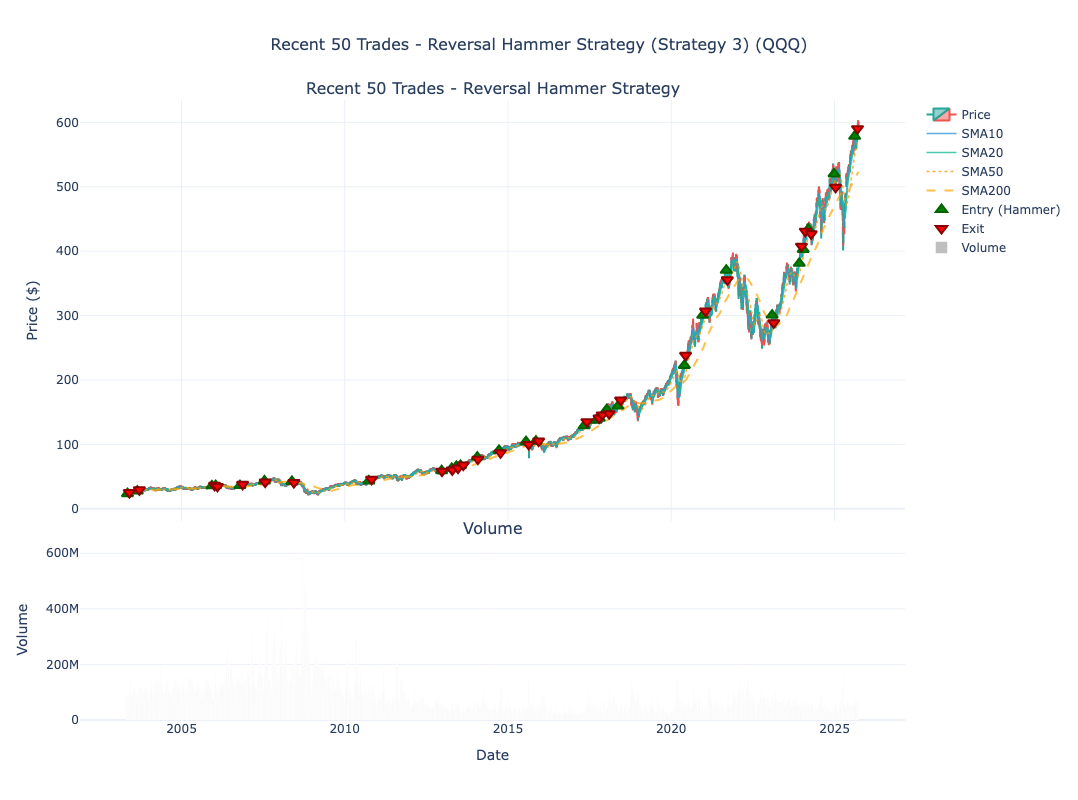


RECENT 50 TRADES CHART DISPLAYED - REVERSAL HAMMER STRATEGY
This focused view shows the most recent 50 trades for detailed analysis.
Use zoom and pan tools to examine individual trades closely.
Green triangles = Entry points (Hammer/Inverted Hammer patterns)
Red triangles = Exit points


In [160]:
# Create a focused chart for the most recent 50 trades (for detailed analysis)
if len(results_hammer['trades']) > 0:
    trades_df = results_hammer['trades'].copy()
    
    # Get the most recent 50 trades
    recent_trades = trades_df.tail(50).copy()
    
    # Find the date range for these trades
    all_dates = []
    for _, trade in recent_trades.iterrows():
        entry_date = pd.to_datetime(trade['entry_date'])
        exit_date = pd.to_datetime(trade['exit_date'])
        all_dates.extend([entry_date, exit_date])
    
    if len(all_dates) > 0:
        min_date = min(all_dates) - pd.Timedelta(days=10)
        max_date = max(all_dates) + pd.Timedelta(days=10)
        
        # Get price data for this period
        recent_data = data_backtest[
            (data_backtest['date'] >= min_date) & 
            (data_backtest['date'] <= max_date)
        ].copy()
        
        if len(recent_data) > 0:
            price_col = results_hammer['price_col']
            
            # Create subplots
            fig = make_subplots(
                rows=2, cols=1,
                shared_xaxes=True,
                vertical_spacing=0.03,
                row_heights=[0.7, 0.3],
                subplot_titles=('Recent 50 Trades - Reversal Hammer Strategy', 'Volume'),
                specs=[[{"secondary_y": False}], [{"secondary_y": False}]]
            )
            
            # Add candlestick
            fig.add_trace(
                go.Candlestick(
                    x=recent_data['date'],
                    open=recent_data['open'],
                    high=recent_data['high'],
                    low=recent_data['low'],
                    close=recent_data[price_col],
                    name='Price',
                    increasing_line_color='#26a69a',
                    decreasing_line_color='#ef5350'
                ),
                row=1, col=1
            )
            
            # Add multiple SMAs for better visualization
            # Calculate SMAs for recent data
            sma10 = recent_data[price_col].rolling(window=10, min_periods=10).mean()
            sma20 = recent_data[price_col].rolling(window=20, min_periods=20).mean()
            sma50 = recent_data[price_col].rolling(window=50, min_periods=50).mean()
            sma200 = recent_data[price_col].rolling(window=200, min_periods=200).mean()
            
            # Add SMA10 (short-term, blue)
            if len(sma10) == len(recent_data):
                fig.add_trace(
                    go.Scatter(
                        x=recent_data['date'],
                        y=sma10,
                        name='SMA10',
                        line=dict(color='#3498db', width=1.5),
                        opacity=0.8
                    ),
                    row=1, col=1
                )
            
            # Add SMA20 (short-medium term, cyan)
            if len(sma20) == len(recent_data):
                fig.add_trace(
                    go.Scatter(
                        x=recent_data['date'],
                        y=sma20,
                        name='SMA20',
                        line=dict(color='#1abc9c', width=1.5),
                        opacity=0.8
                    ),
                    row=1, col=1
                )
            
            # Add SMA50 (medium-term, yellow)
            if len(sma50) == len(recent_data):
                fig.add_trace(
                    go.Scatter(
                        x=recent_data['date'],
                        y=sma50,
                        name='SMA50',
                        line=dict(color='#f39c12', width=1.5, dash='dot'),
                        opacity=0.8
                    ),
                    row=1, col=1
                )
            
            # Add SMA200 (long-term, orange) - only if we have enough data
            if len(sma200) == len(recent_data) and not sma200.isna().all():
                fig.add_trace(
                    go.Scatter(
                        x=recent_data['date'],
                        y=sma200,
                        name='SMA200',
                        line=dict(color='orange', width=2, dash='dash'),
                        opacity=0.7
                    ),
                    row=1, col=1
                )
            
            # Mark entry and exit points for recent trades
            entry_dates = pd.to_datetime(recent_trades['entry_date']).tolist()
            entry_prices = recent_trades['entry_price'].tolist()
            exit_dates = pd.to_datetime(recent_trades['exit_date']).tolist()
            exit_prices = recent_trades['exit_price'].tolist()
            exit_reasons = recent_trades['exit_reason'].tolist()
            pnl_pcts = recent_trades['pnl_pct'].tolist()
            
            # Add entry markers
            fig.add_trace(
                go.Scatter(
                    x=entry_dates,
                    y=entry_prices,
                    mode='markers',
                    name='Entry (Hammer)',
                    marker=dict(
                        symbol='triangle-up',
                        size=10,
                        color='green',
                        line=dict(width=2, color='darkgreen')
                    ),
                    hovertemplate='<b>Entry (Hammer Pattern)</b><br>Date: %{x}<br>Price: $%{y:.2f}<extra></extra>',
                    showlegend=True
                ),
                row=1, col=1
            )
            
            # Add exit markers with PnL info
            fig.add_trace(
                go.Scatter(
                    x=exit_dates,
                    y=exit_prices,
                    mode='markers',
                    name='Exit',
                    marker=dict(
                        symbol='triangle-down',
                        size=10,
                        color='red',
                        line=dict(width=2, color='darkred')
                    ),
                    hovertemplate='<b>Exit</b><br>Date: %{x}<br>Price: $%{y:.2f}<br>Reason: %{text}<br>PnL: %{customdata:.2f}%<extra></extra>',
                    text=exit_reasons,
                    customdata=pnl_pcts,
                    showlegend=True
                ),
                row=1, col=1
            )
            
            # Add volume
            fig.add_trace(
                go.Bar(
                    x=recent_data['date'],
                    y=recent_data['vol'],
                    name='Volume',
                    marker_color='rgba(128, 128, 128, 0.5)'
                ),
                row=2, col=1
            )
            
            # Update layout
            fig.update_layout(
                title=dict(
                    text=f'Recent 50 Trades - Reversal Hammer Strategy (Strategy 3) ({ticker})',
                    x=0.5,
                    font=dict(size=16)
                ),
                xaxis_rangeslider_visible=False,
                height=800,
                template='plotly_white',
                hovermode='x unified',
                showlegend=True
            )
            
            fig.update_xaxes(title_text="Date", row=2, col=1)
            fig.update_yaxes(title_text="Price ($)", row=1, col=1)
            fig.update_yaxes(title_text="Volume", row=2, col=1)
            
            fig.show()
            
            print(f"\n{'='*60}")
            print("RECENT 50 TRADES CHART DISPLAYED - REVERSAL HAMMER STRATEGY")
            print(f"{'='*60}")
            print("This focused view shows the most recent 50 trades for detailed analysis.")
            print("Use zoom and pan tools to examine individual trades closely.")
            print("Green triangles = Entry points (Hammer/Inverted Hammer patterns)")
            print("Red triangles = Exit points")
            print(f"{'='*60}")
        else:
            print("No data available for the recent trades period.")
    else:
        print("No valid dates found in recent trades.")
else:
    print("No trades available for charting.")


# Price Action Structure + Hammer Strategy Visualization

**Goal: Enhance the bullish Hammer / Inverted Hammer strategy by adding basic price action structure (swings + trend) and strong visualization — without installing or using smartmoneyconcepts.**

This section adds:
1. Swing Highs/Lows detection using scipy
2. Basic structure classification (HH, HL, LH, LL + trend label)
3. Visualization of price action + signals using mplfinance
4. Filtered Hammer strategy backtest (only trade in Uptrend or Range)


## Swing Detection

Detect swing highs and swing lows using scipy.signal.argrelextrema


In [161]:
# Import additional libraries for swing detection and visualization
from scipy.signal import argrelextrema
import mplfinance as mpf

# Prepare data for swing detection (use data_backtest or data)
df_swing = data_backtest.copy() if 'data_backtest' in globals() else data.copy()

# Swing detection parameters
swing_order = 5  # Lookback/forward bars for swing detection (tunable)

print(f"Detecting swing highs and lows with order={swing_order}...")

# Detect swing highs (local maxima on High prices)
swing_high_indices = argrelextrema(df_swing['high'].values, np.greater, order=swing_order)[0]
df_swing['swing_high'] = False
df_swing.loc[swing_high_indices, 'swing_high'] = True
df_swing['swing_high_price'] = np.nan
df_swing.loc[swing_high_indices, 'swing_high_price'] = df_swing.loc[swing_high_indices, 'high']

# Detect swing lows (local minima on Low prices)
swing_low_indices = argrelextrema(df_swing['low'].values, np.less, order=swing_order)[0]
df_swing['swing_low'] = False
df_swing.loc[swing_low_indices, 'swing_low'] = True
df_swing['swing_low_price'] = np.nan
df_swing.loc[swing_low_indices, 'swing_low_price'] = df_swing.loc[swing_low_indices, 'low']

# Create combined swing price column for easier plotting
df_swing['swing_price'] = np.nan
df_swing.loc[df_swing['swing_high'], 'swing_price'] = df_swing.loc[df_swing['swing_high'], 'high']
df_swing.loc[df_swing['swing_low'], 'swing_price'] = df_swing.loc[df_swing['swing_low'], 'low']

print(f"Detected {df_swing['swing_high'].sum()} swing highs and {df_swing['swing_low'].sum()} swing lows")
print(f"Total swing points: {(df_swing['swing_high'] | df_swing['swing_low']).sum()}")


Detecting swing highs and lows with order=5...
Detected 373 swing highs and 407 swing lows
Total swing points: 777


## Structure & Trend Classification

Classify price structure (HH, HL, LH, LL) and determine trend from the last 4-6 swings


In [162]:
# Structure classification: Identify HH, HL, LH, LL patterns from swing points
df_swing['trend_label'] = 'Range'  # Default to Range
df_swing['structure_label'] = ''  # Will store HH, HL, LH, LL labels

# Get swing high and low indices
swing_highs = df_swing[df_swing['swing_high']].copy()
swing_lows = df_swing[df_swing['swing_low']].copy()

print("Classifying structure and trend...")

# For each row, look back at the last few swings to classify structure
for i in range(200, len(df_swing)):  # Start from index 200 to have enough history
    # Get recent swing highs (last 3-4)
    recent_highs = swing_highs[swing_highs.index <= i].tail(3)
    recent_lows = swing_lows[swing_lows.index <= i].tail(3)
    
    if len(recent_highs) >= 2 and len(recent_lows) >= 2:
        # Compare last two highs
        last_high = recent_highs.iloc[-1]['high']
        prev_high = recent_highs.iloc[-2]['high']
        
        # Compare last two lows
        last_low = recent_lows.iloc[-1]['low']
        prev_low = recent_lows.iloc[-2]['low']
        
        # Classify structure
        high_structure = 'HH' if last_high > prev_high else 'LH'
        low_structure = 'HL' if last_low > prev_low else 'LL'
        
        # Determine trend
        if high_structure == 'HH' and low_structure == 'HL':
            df_swing.loc[i, 'trend_label'] = 'Uptrend'
        elif high_structure == 'LH' and low_structure == 'LL':
            df_swing.loc[i, 'trend_label'] = 'Downtrend'
        else:
            df_swing.loc[i, 'trend_label'] = 'Range'
        
        # Store structure label (for visualization)
        df_swing.loc[i, 'structure_label'] = f"{high_structure}/{low_structure}"
    else:
        df_swing.loc[i, 'trend_label'] = 'Range'
        df_swing.loc[i, 'structure_label'] = 'Insufficient'

# Fill forward the trend_label for rows before index 200
df_swing.loc[:199, 'trend_label'] = 'Range'

# Print summary
print(f"\nTrend Classification Summary:")
print(df_swing['trend_label'].value_counts())
print(f"\nStructure labels (last 10):")
print(df_swing[df_swing['structure_label'] != '']['structure_label'].tail(10))


Classifying structure and trend...

Trend Classification Summary:
trend_label
Uptrend      2943
Range        2311
Downtrend    1491
Name: count, dtype: int64

Structure labels (last 10):
6735    LH/LL
6736    LH/HL
6737    LH/HL
6738    LH/HL
6739    LH/HL
6740    LH/HL
6741    LH/HL
6742    LH/HL
6743    LH/HL
6744    LH/HL
Name: structure_label, dtype: object


## Visualization

Visualize price action with swings, structure labels, and Hammer signals using mplfinance


In [163]:
# Prepare data for visualization (last 200-300 bars for readability)
plot_bars = 250
df_plot = df_swing.tail(plot_bars).copy()

# Set date as index for mplfinance
df_plot_indexed = df_plot.set_index('date')

# Calculate SMAs for the plot
price_col = 'close'
if 'Adj Close' in df_plot.columns:
    price_col = 'Adj Close'
elif 'adj_close' in df_plot.columns:
    price_col = 'adj_close'

df_plot_indexed['SMA10'] = df_plot_indexed[price_col].rolling(10).mean()
df_plot_indexed['SMA20'] = df_plot_indexed[price_col].rolling(20).mean()
df_plot_indexed['SMA50'] = df_plot_indexed[price_col].rolling(50).mean()
df_plot_indexed['SMA200'] = df_plot_indexed[price_col].rolling(200).mean()

# Detect Hammer patterns for visualization
df_plot_indexed['CDLHAMMER'] = talib.CDLHAMMER(
    df_plot_indexed['open'].values,
    df_plot_indexed['high'].values,
    df_plot_indexed['low'].values,
    df_plot_indexed[price_col].values
)
df_plot_indexed['CDLINVERTEDHAMMER'] = talib.CDLINVERTEDHAMMER(
    df_plot_indexed['open'].values,
    df_plot_indexed['high'].values,
    df_plot_indexed['low'].values,
    df_plot_indexed[price_col].values
)

# Filter hammer signals: pattern > 0 AND trend in ['Uptrend', 'Range']
# Create hammer_signal in both df_plot and df_plot_indexed for consistency
df_plot_indexed['hammer_signal'] = (
    ((df_plot_indexed['CDLHAMMER'] > 0) | (df_plot_indexed['CDLINVERTEDHAMMER'] > 0)) &
    (df_plot_indexed['trend_label'].isin(['Uptrend', 'Range']))
)

# Also create in df_plot for filtering (align with df_plot_indexed)
df_plot['hammer_signal'] = df_plot_indexed['hammer_signal'].values

# Prepare swing points for markers
swing_highs_plot = df_plot[df_plot['swing_high']].copy()
swing_lows_plot = df_plot[df_plot['swing_low']].copy()
hammer_signals_plot = df_plot[df_plot['hammer_signal']].copy()

# Create custom plot with mplfinance
# First, create the base candlestick chart
mc = mpf.make_marketcolors(
    up='#26a69a',
    down='#ef5350',
    edge='inherit',
    wick={'upcolor': '#26a69a', 'downcolor': '#ef5350'},
    volume='in'
)

style = mpf.make_mpf_style(
    marketcolors=mc,
    gridstyle='-',
    gridcolor='#cccccc',
    y_on_right=False
)

# Prepare additional plots (swing markers and signals)
addplot_list = []

# Add SMAs
addplot_list.append(mpf.make_addplot(df_plot_indexed['SMA10'], color='#3498db', width=1, alpha=0.7))
addplot_list.append(mpf.make_addplot(df_plot_indexed['SMA20'], color='#1abc9c', width=1, alpha=0.7))
addplot_list.append(mpf.make_addplot(df_plot_indexed['SMA50'], color='#f39c12', width=1.5, alpha=0.7, linestyle='--'))
if not df_plot_indexed['SMA200'].isna().all():
    addplot_list.append(mpf.make_addplot(df_plot_indexed['SMA200'], color='orange', width=2, alpha=0.7, linestyle='--'))

# Add swing high markers (green triangles)
if len(swing_highs_plot) > 0:
    swing_high_prices = swing_highs_plot['high'].values
    swing_high_dates = swing_highs_plot['date'].values
    swing_high_series = pd.Series(swing_high_prices, index=swing_high_dates)
    swing_high_series = swing_high_series.reindex(df_plot_indexed.index, fill_value=np.nan)
    addplot_list.append(mpf.make_addplot(swing_high_series, type='scatter', markersize=100, 
                                        marker='^', color='green', alpha=0.6))

# Add swing low markers (red triangles)
if len(swing_lows_plot) > 0:
    swing_low_prices = swing_lows_plot['low'].values
    swing_low_dates = swing_lows_plot['date'].values
    swing_low_series = pd.Series(swing_low_prices, index=swing_low_dates)
    swing_low_series = swing_low_series.reindex(df_plot_indexed.index, fill_value=np.nan)
    addplot_list.append(mpf.make_addplot(swing_low_series, type='scatter', markersize=100, 
                                        marker='v', color='red', alpha=0.6))

# Add hammer signal markers (yellow circles)
if len(hammer_signals_plot) > 0:
    hammer_prices = hammer_signals_plot[price_col].values
    hammer_dates = hammer_signals_plot['date'].values
    hammer_series = pd.Series(hammer_prices, index=hammer_dates)
    hammer_series = hammer_series.reindex(df_plot_indexed.index, fill_value=np.nan)
    addplot_list.append(mpf.make_addplot(hammer_series, type='scatter', markersize=150, 
                                        marker='o', color='yellow', alpha=0.8, edgecolors='orange', linewidths=2))

# Plot
mpf.plot(
    df_plot_indexed,
    type='candle',
    style=style,
    volume=True,
    addplot=addplot_list,
    title=f'{ticker} Price Action Structure + Hammer Signals (Last {plot_bars} bars)',
    ylabel='Price ($)',
    figsize=(16, 10),
    warn_too_much_data=False
)

print(f"\n{'='*60}")
print("VISUALIZATION COMPLETE")
print(f"{'='*60}")
print("Green triangles (^) = Swing Highs")
print("Red triangles (v) = Swing Lows")
print("Yellow circles = Hammer/Inverted Hammer signals (filtered by trend)")
print("Blue line = SMA10, Cyan = SMA20, Yellow = SMA50, Orange = SMA200")
print(f"{'='*60}")

# Print current trend
current_trend = df_plot['trend_label'].iloc[-1]
print(f"\nCurrent Trend: {current_trend}")
print(f"Hammer signals in plot period: {df_plot_indexed['hammer_signal'].sum()}")


KeyError: 'up'

## Filtered Hammer Strategy Backtest

Backtest the Hammer strategy with trend filter (only trade in Uptrend or Range)


In [ ]:
def backtest_filtered_hammer_strategy(data, initial_capital=10000, risk_per_trade=0.01, stop_loss_pct=0.04, take_profit_pct=0.07, max_hold_days=30):
    """
    Backtest the Filtered Reversal Hammer trading strategy (LONG-ONLY VERSION with trend filter).
    
    Strategy Rules:
    - Long Entry: Bullish CDLHAMMER or CDLINVERTEDHAMMER (value > 0) 
                  AND Close > 200-day SMA 
                  AND Volume > 20-day average 
                  AND RSI(14) > 50
                  AND trend_label in ['Uptrend', 'Range'] (NEW: trend filter)
    - No short entries (long-only strategy)
    - Only trade when price is above 200-day SMA (no trades in downtrends)
    - Exit: Dynamic hold while Close > SMA200 (max 30 days) OR 4% stop-loss OR +7% take-profit
    - Position sizing: Risk 1% of current capital per trade (adjusted for 4% stop)
    
    Parameters:
    -----------
    data : pd.DataFrame
        DataFrame with columns: date, open, high, low, close, vol, trend_label
    initial_capital : float
        Starting capital (default: $10,000)
    risk_per_trade : float
        Risk percentage per trade (default: 1% = 0.01)
    stop_loss_pct : float
        Stop-loss percentage from entry (default: 4% = 0.04)
    take_profit_pct : float
        Take-profit percentage from entry (default: 7% = 0.07)
    max_hold_days : int
        Maximum holding period in days (default: 30)
    
    Returns:
    --------
    dict : Dictionary containing backtest results and metrics
    """
    
    # Create a copy to avoid modifying original data
    df = data.copy()
    
    # Ensure we have enough data for 200-day SMA
    if len(df) < 200:
        return {
            'error': f'Insufficient data: need at least 200 days, got {len(df)}',
            'trades': [],
            'equity_curve': None
        }
    
    # Determine price column (use adjusted close if available)
    price_col = 'close'
    if 'Adj Close' in df.columns:
        price_col = 'Adj Close'
    elif 'adj_close' in df.columns:
        price_col = 'adj_close'
    
    # Calculate 200-day Simple Moving Average
    df['SMA200'] = df[price_col].rolling(window=200, min_periods=200).mean()
    
    # Calculate 20-day average volume
    df['Avg_Vol20'] = df['vol'].rolling(window=20, min_periods=20).mean()
    
    # Calculate RSI(14)
    df['RSI14'] = talib.RSI(df[price_col].values, timeperiod=14)
    
    # Detect candlestick patterns using TA-Lib (Reversal patterns)
    df['CDLHAMMER'] = talib.CDLHAMMER(df['open'].values, df['high'].values, 
                                      df['low'].values, df[price_col].values)
    df['CDLINVERTEDHAMMER'] = talib.CDLINVERTEDHAMMER(df['open'].values, df['high'].values, 
                                                      df['low'].values, df[price_col].values)
    
    # Ensure trend_label column exists (default to 'Range' if not present)
    if 'trend_label' not in df.columns:
        df['trend_label'] = 'Range'
    
    # Determine long signals with all conditions INCLUDING trend filter
    # Long signal: bullish reversal pattern (value > 0) AND close > SMA200 
    #              AND volume > avg_vol20 AND RSI14 > 50 AND trend in ['Uptrend', 'Range']
    long_condition = (
        ((df['CDLHAMMER'] > 0) | (df['CDLINVERTEDHAMMER'] > 0)) &
        (df[price_col] > df['SMA200']) &
        (df['vol'] > df['Avg_Vol20']) &
        (df['RSI14'] > 50) &
        (df['trend_label'].isin(['Uptrend', 'Range'])) &  # NEW: Trend filter
        (~df['SMA200'].isna()) &
        (~df['RSI14'].isna())
    )
    
    # Create long signal column: 1 (long entry), 0 (no signal)
    df['Long_Signal'] = 0
    df.loc[long_condition, 'Long_Signal'] = 1
    
    # Initialize trading variables
    capital = initial_capital
    position = None
    entry_price = None
    entry_date = None
    entry_index = None
    position_size = None
    trades = []
    equity_curve = [capital]
    
    # Loop through data to simulate trades (start from index 200 to ensure SMA200 is available)
    for i in range(200, len(df)):
        current_price = df.loc[i, price_col]
        current_date = df.loc[i, 'date']
        current_high = df.loc[i, 'high']
        current_low = df.loc[i, 'low']
        current_sma200 = df.loc[i, 'SMA200']
        
        # Check for stop-loss if in position
        if position == 'long':
            if current_low <= entry_price * (1 - stop_loss_pct):
                exit_price = entry_price * (1 - stop_loss_pct)
                pnl = (exit_price - entry_price) / entry_price
                trade_value = capital + (position_size * (exit_price - entry_price))
                capital = trade_value
                
                trades.append({
                    'entry_date': entry_date,
                    'exit_date': current_date,
                    'entry_price': entry_price,
                    'exit_price': exit_price,
                    'position': position,
                    'position_size': position_size,
                    'pnl': pnl,
                    'pnl_pct': pnl * 100,
                    'pnl_dollar': position_size * (exit_price - entry_price),
                    'exit_reason': 'stop_loss',
                    'hold_days': (current_date - entry_date).days
                })
                
                position = None
                entry_price = None
                entry_date = None
                entry_index = None
                position_size = None
                continue
        
        # Check for take-profit if in position
        if position == 'long':
            if current_high >= entry_price * (1 + take_profit_pct):
                exit_price = entry_price * (1 + take_profit_pct)
                pnl = (exit_price - entry_price) / entry_price
                trade_value = capital + (position_size * (exit_price - entry_price))
                capital = trade_value
                
                trades.append({
                    'entry_date': entry_date,
                    'exit_date': current_date,
                    'entry_price': entry_price,
                    'exit_price': exit_price,
                    'position': position,
                    'position_size': position_size,
                    'pnl': pnl,
                    'pnl_pct': pnl * 100,
                    'pnl_dollar': position_size * (exit_price - entry_price),
                    'exit_reason': 'take_profit',
                    'hold_days': (current_date - entry_date).days
                })
                
                position = None
                entry_price = None
                entry_date = None
                entry_index = None
                position_size = None
                continue
        
        # Check for exit conditions if in position
        if position == 'long':
            days_held = (current_date - entry_date).days
            
            # Exit if price drops below SMA200 (dynamic exit)
            if current_sma200 is not None and current_price < current_sma200:
                pnl = (current_price - entry_price) / entry_price
                trade_value = capital + (position_size * (current_price - entry_price))
                capital = trade_value
                
                trades.append({
                    'entry_date': entry_date,
                    'exit_date': current_date,
                    'entry_price': entry_price,
                    'exit_price': current_price,
                    'position': position,
                    'position_size': position_size,
                    'pnl': pnl,
                    'pnl_pct': pnl * 100,
                    'pnl_dollar': position_size * (current_price - entry_price),
                    'exit_reason': 'below_sma200',
                    'hold_days': days_held
                })
                
                position = None
                entry_price = None
                entry_date = None
                entry_index = None
                position_size = None
                continue
            
            # Exit after max_hold_days (30 days)
            if days_held >= max_hold_days:
                pnl = (current_price - entry_price) / entry_price
                trade_value = capital + (position_size * (current_price - entry_price))
                capital = trade_value
                
                trades.append({
                    'entry_date': entry_date,
                    'exit_date': current_date,
                    'entry_price': entry_price,
                    'exit_price': current_price,
                    'position': position,
                    'position_size': position_size,
                    'pnl': pnl,
                    'pnl_pct': pnl * 100,
                    'pnl_dollar': position_size * (current_price - entry_price),
                    'exit_reason': 'time_limit',
                    'hold_days': days_held
                })
                
                position = None
                entry_price = None
                entry_date = None
                entry_index = None
                position_size = None
                continue
        
        # Check for new entry signals
        if position is None:
            signal = df.loc[i, 'Long_Signal']
            sma200_value = df.loc[i, 'SMA200']
            
            if signal == 1 and sma200_value is not None and current_price > sma200_value:
                position = 'long'
                entry_price = current_price
                entry_date = current_date
                entry_index = i
                
                position_size = int((capital * risk_per_trade) / (entry_price * stop_loss_pct))
                if position_size < 1:
                    position_size = 0
                    position = None
                    entry_price = None
                    entry_date = None
                    entry_index = None
        
        # Update equity curve
        if position == 'long':
            current_value = capital + (position_size * (current_price - entry_price))
            equity_curve.append(current_value)
        else:
            equity_curve.append(capital)
    
    # Close any open position at the end
    if position == 'long':
        final_price = df.loc[len(df)-1, price_col]
        pnl = (final_price - entry_price) / entry_price
        trade_value = capital + (position_size * (final_price - entry_price))
        capital = trade_value
        
        trades.append({
            'entry_date': entry_date,
            'exit_date': df.loc[len(df)-1, 'date'],
            'entry_price': entry_price,
            'exit_price': final_price,
            'position': position,
            'position_size': position_size,
            'pnl': pnl,
            'pnl_pct': pnl * 100,
            'pnl_dollar': position_size * (final_price - entry_price),
            'exit_reason': 'end_of_data',
            'hold_days': (df.loc[len(df)-1, 'date'] - entry_date).days
        })
    
    # Calculate metrics
    if len(trades) > 0:
        trades_df = pd.DataFrame(trades)
        
        total_return = (capital - initial_capital) / initial_capital
        winning_trades = trades_df[trades_df['pnl'] > 0]
        win_rate = len(winning_trades) / len(trades_df) if len(trades_df) > 0 else 0
        avg_win = winning_trades['pnl'].mean() if len(winning_trades) > 0 else 0
        losing_trades = trades_df[trades_df['pnl'] <= 0]
        avg_loss = losing_trades['pnl'].mean() if len(losing_trades) > 0 else 0
        
        equity_array = np.array(equity_curve)
        running_max = np.maximum.accumulate(equity_array)
        drawdown = (equity_array - running_max) / running_max
        max_drawdown = drawdown.min()
        
        daily_returns = np.diff(equity_curve) / equity_curve[:-1]
        sharpe_ratio = np.mean(daily_returns) / np.std(daily_returns) * np.sqrt(252) if np.std(daily_returns) > 0 else 0
        
        results = {
            'initial_capital': initial_capital,
            'final_capital': capital,
            'total_return': total_return,
            'total_return_pct': total_return * 100,
            'total_trades': len(trades_df),
            'win_rate': win_rate,
            'win_rate_pct': win_rate * 100,
            'avg_win': avg_win,
            'avg_win_pct': avg_win * 100,
            'avg_loss': avg_loss,
            'avg_loss_pct': avg_loss * 100,
            'max_drawdown': max_drawdown,
            'max_drawdown_pct': max_drawdown * 100,
            'sharpe_ratio': sharpe_ratio,
            'trades': trades_df,
            'equity_curve': equity_curve,
            'dates': df['date'].tolist(),
            'price_col': price_col
        }
    else:
        results = {
            'initial_capital': initial_capital,
            'final_capital': capital,
            'total_return': 0,
            'total_return_pct': 0,
            'total_trades': 0,
            'win_rate': 0,
            'win_rate_pct': 0,
            'avg_win': 0,
            'avg_win_pct': 0,
            'avg_loss': 0,
            'avg_loss_pct': 0,
            'max_drawdown': 0,
            'max_drawdown_pct': 0,
            'sharpe_ratio': 0,
            'trades': pd.DataFrame(),
            'equity_curve': equity_curve,
            'dates': df['date'].tolist(),
            'price_col': price_col
        }
    
    return results


In [ ]:
# Run backtest for Filtered Hammer Strategy (with trend filter)
print("="*60)
print("Running backtest for Filtered Hammer Strategy (with trend filter)...")
print("="*60)
print("Strategy: Bullish Hammer/Inverted Hammer reversal patterns")
print("Entry: Pattern + Close > SMA200 + Volume > 20-day avg + RSI(14) > 50 + Trend in [Uptrend, Range]")
print("Exit: Dynamic hold (while > SMA200, max 30d) OR 4% stop OR +7% target")
print("="*60)

# Use data with swing detection and trend labels
results_filtered_hammer = backtest_filtered_hammer_strategy(
    data=df_swing,
    initial_capital=10000,
    risk_per_trade=0.01,
    stop_loss_pct=0.04,
    take_profit_pct=0.07,
    max_hold_days=30
)

# Display results
print(f"\n{'='*60}")
print("BACKTEST RESULTS - FILTERED HAMMER STRATEGY (with trend filter)")
print(f"{'='*60}")
print(f"Initial Capital: ${results_filtered_hammer['initial_capital']:,.2f}")
print(f"Final Capital: ${results_filtered_hammer['final_capital']:,.2f}")
if results_filtered_hammer['total_return_pct'] >= 0:
    print(f"Total Return: +{results_filtered_hammer['total_return_pct']:.2f}%")
else:
    print(f"Total Return: {results_filtered_hammer['total_return_pct']:.2f}%")
print(f"\nTotal Trades: {results_filtered_hammer['total_trades']}")
print(f"Win Rate: {results_filtered_hammer['win_rate_pct']:.2f}%")
print(f"Average Win: {results_filtered_hammer['avg_win_pct']:.2f}%")
print(f"Average Loss: {results_filtered_hammer['avg_loss_pct']:.2f}%")
print(f"Max Drawdown: {results_filtered_hammer['max_drawdown_pct']:.2f}%")
print(f"Sharpe Ratio: {results_filtered_hammer['sharpe_ratio']:.2f}")
print(f"\nNote: Strategy now filters out trades in aggressive downtrends (only trades in Uptrend or Range)")
print(f"{'='*60}")



FILTERED HAMMER STRATEGY - PERFORMANCE SUMMARY
Metric                         Value               
--------------------------------------------------
Initial Capital                $10,000.00
Final Capital                  $10,452.38
Total Return                   +4.52%
Total Trades                   30
Win Rate                       53.33%
Average Win                    4.42%
Average Loss                   -3.63%
Max Drawdown                   -6.07%
Sharpe Ratio                   0.17

COMPARISON: Filtered vs Unfiltered Hammer Strategy
Metric                         Filtered             Unfiltered          
----------------------------------------------------------------------
Total Trades                   30                   30                  
Total Return                   4.52%                4.52%
Win Rate                       53.33%                53.33%


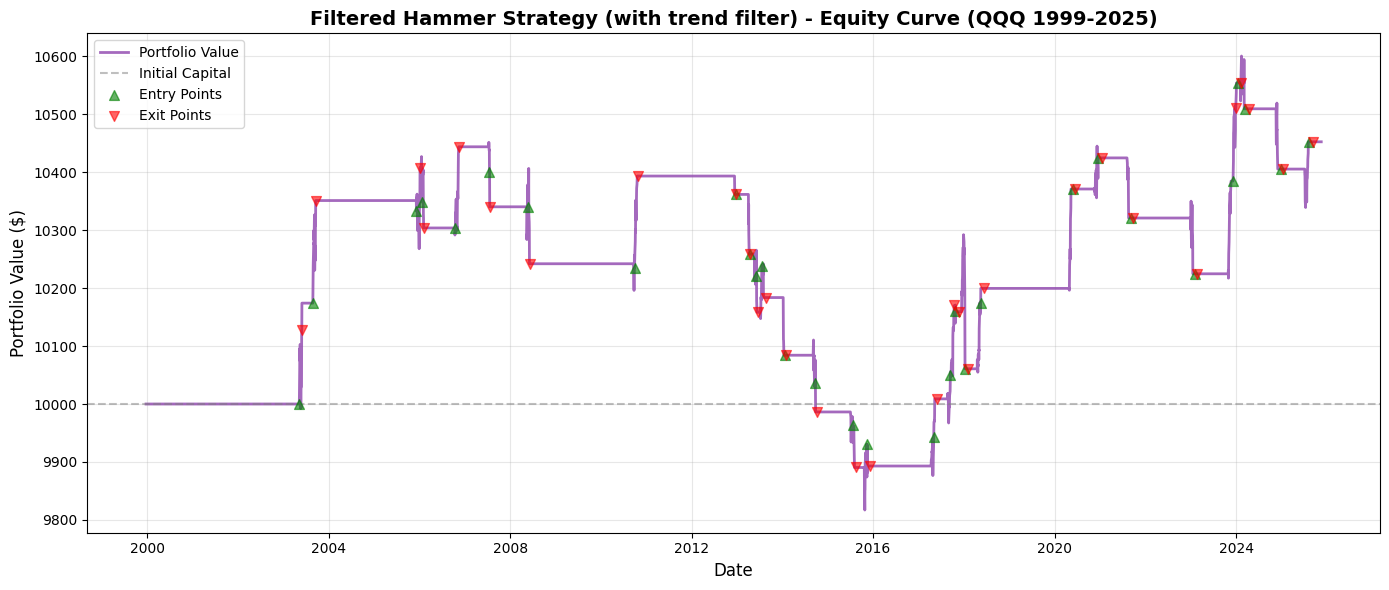

In [164]:
# Display Filtered Hammer Strategy Performance Summary
if len(df_swing) > 0:
    print(f"\n{'='*60}")
    print("FILTERED HAMMER STRATEGY - PERFORMANCE SUMMARY")
    print(f"{'='*60}")
    print(f"{'Metric':<30} {'Value':<20}")
    print(f"{'-'*50}")
    print(f"{'Initial Capital':<30} ${results_filtered_hammer['initial_capital']:,.2f}")
    print(f"{'Final Capital':<30} ${results_filtered_hammer['final_capital']:,.2f}")
    
    strategy_return_str = f"+{results_filtered_hammer['total_return_pct']:.2f}%" if results_filtered_hammer['total_return_pct'] >= 0 else f"{results_filtered_hammer['total_return_pct']:.2f}%"
    print(f"{'Total Return':<30} {strategy_return_str}")
    print(f"{'Total Trades':<30} {results_filtered_hammer['total_trades']}")
    print(f"{'Win Rate':<30} {results_filtered_hammer['win_rate_pct']:.2f}%")
    print(f"{'Average Win':<30} {results_filtered_hammer['avg_win_pct']:.2f}%")
    print(f"{'Average Loss':<30} {results_filtered_hammer['avg_loss_pct']:.2f}%")
    print(f"{'Max Drawdown':<30} {results_filtered_hammer['max_drawdown_pct']:.2f}%")
    print(f"{'Sharpe Ratio':<30} {results_filtered_hammer['sharpe_ratio']:.2f}")
    print(f"{'='*60}")
    
    # Compare to unfiltered strategy if available
    if 'results_hammer' in globals():
        print(f"\n{'='*60}")
        print("COMPARISON: Filtered vs Unfiltered Hammer Strategy")
        print(f"{'='*60}")
        print(f"{'Metric':<30} {'Filtered':<20} {'Unfiltered':<20}")
        print(f"{'-'*70}")
        print(f"{'Total Trades':<30} {results_filtered_hammer['total_trades']:<20} {results_hammer['total_trades']:<20}")
        print(f"{'Total Return':<30} {results_filtered_hammer['total_return_pct']:.2f}%{'':<15} {results_hammer['total_return_pct']:.2f}%")
        print(f"{'Win Rate':<30} {results_filtered_hammer['win_rate_pct']:.2f}%{'':<15} {results_hammer['win_rate_pct']:.2f}%")
        print(f"{'='*60}")
    
    # Plot equity curve
    fig, ax = plt.subplots(figsize=(14, 6))
    
    dates_extended = results_filtered_hammer['dates'][200:]
    if len(results_filtered_hammer['equity_curve']) == len(dates_extended) + 1:
        ax.plot(dates_extended, results_filtered_hammer['equity_curve'][1:], linewidth=2, color='#8E44AD', label='Portfolio Value', alpha=0.8)
        equity_curve_aligned = results_filtered_hammer['equity_curve'][1:]
    else:
        min_len = min(len(dates_extended), len(results_filtered_hammer['equity_curve']))
        ax.plot(dates_extended[:min_len], results_filtered_hammer['equity_curve'][:min_len], linewidth=2, color='#8E44AD', label='Portfolio Value', alpha=0.8)
        equity_curve_aligned = results_filtered_hammer['equity_curve'][:min_len]
    
    ax.axhline(y=results_filtered_hammer['initial_capital'], color='gray', linestyle='--', alpha=0.5, label='Initial Capital')
    
    # Mark entry and exit points
    if len(results_filtered_hammer['trades']) > 0:
        trades_df = results_filtered_hammer['trades']
        entry_dates = pd.to_datetime(trades_df['entry_date']).tolist()
        exit_dates = pd.to_datetime(trades_df['exit_date']).tolist()
        
        entry_equity = []
        for ed in entry_dates:
            try:
                idx = dates_extended.index(ed)
                if idx < len(equity_curve_aligned):
                    entry_equity.append(equity_curve_aligned[idx])
                else:
                    entry_equity.append(results_filtered_hammer['initial_capital'])
            except:
                entry_equity.append(results_filtered_hammer['initial_capital'])
        
        exit_equity = []
        for ed in exit_dates:
            try:
                idx = dates_extended.index(ed)
                if idx < len(equity_curve_aligned):
                    exit_equity.append(equity_curve_aligned[idx])
                else:
                    exit_equity.append(results_filtered_hammer['initial_capital'])
            except:
                exit_equity.append(results_filtered_hammer['initial_capital'])
        
        ax.scatter(entry_dates, entry_equity, color='green', marker='^', s=50, alpha=0.6, label='Entry Points', zorder=5)
        ax.scatter(exit_dates, exit_equity, color='red', marker='v', s=50, alpha=0.6, label='Exit Points', zorder=5)
    
    date_range_str = f"{df_swing['date'].min().year}-{df_swing['date'].max().year}"
    ax.set_ylabel('Portfolio Value ($)', fontsize=12)
    ax.set_xlabel('Date', fontsize=12)
    ax.set_title(f'Filtered Hammer Strategy (with trend filter) - Equity Curve ({ticker} {date_range_str})', fontsize=14, fontweight='bold')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("No data available for plotting.")


**Note:** This adds swing-based structure and visual confirmation without external structure packages. The trend filter helps avoid trading in aggressive downtrends, potentially improving win rate and reducing drawdowns.


# Strategy 4: 200 MA Break & Retest in Uptrend (Long-Only)

**Strategy 4: Structural pullback to 200 MA in confirmed uptrend. Waits for retest instead of chasing breakouts. Tunable: swing order, proximity %, confirmation rules.**

This strategy focuses on buying dips to the 200 MA in bull trends:
- Only trades when price is in confirmed uptrend (Close > 200 SMA + higher highs/higher lows)
- Waits for pullback/retest of 200 MA (within 1% proximity)
- Enters on bullish confirmation
- Longer hold period (60 days max) to capture swing moves
- 5% trailing stop or +10% take-profit (2:1 R:R minimum)


## 200 MA & Swing Detection

Calculate 200-day SMA and detect swing highs/lows for trend confirmation


In [165]:
# Prepare data for Strategy 4
df_ma200 = data_backtest.copy() if 'data_backtest' in globals() else data.copy()

# Calculate 200-day Simple Moving Average
price_col = 'close'
if 'Adj Close' in df_ma200.columns:
    price_col = 'Adj Close'
elif 'adj_close' in df_ma200.columns:
    price_col = 'adj_close'

df_ma200['SMA200'] = df_ma200[price_col].rolling(window=200, min_periods=200).mean()

# Swing detection parameters (higher order for cleaner swings)
swing_order_ma200 = 10  # Tunable: 5-15 (higher = fewer but cleaner swings)

print(f"Detecting swing highs and lows with order={swing_order_ma200} for 200 MA retest strategy...")

# Detect swing highs (local maxima on High prices)
swing_high_indices_ma200 = argrelextrema(df_ma200['high'].values, np.greater, order=swing_order_ma200)[0]
df_ma200['swing_high_ma200'] = False
df_ma200.loc[swing_high_indices_ma200, 'swing_high_ma200'] = True
df_ma200['swing_high_price_ma200'] = np.nan
df_ma200.loc[swing_high_indices_ma200, 'swing_high_price_ma200'] = df_ma200.loc[swing_high_indices_ma200, 'high']

# Detect swing lows (local minima on Low prices)
swing_low_indices_ma200 = argrelextrema(df_ma200['low'].values, np.less, order=swing_order_ma200)[0]
df_ma200['swing_low_ma200'] = False
df_ma200.loc[swing_low_indices_ma200, 'swing_low_ma200'] = True
df_ma200['swing_low_price_ma200'] = np.nan
df_ma200.loc[swing_low_indices_ma200, 'swing_low_price_ma200'] = df_ma200.loc[swing_low_indices_ma200, 'low']

print(f"Detected {df_ma200['swing_high_ma200'].sum()} swing highs and {df_ma200['swing_low_ma200'].sum()} swing lows")
print(f"200-day SMA calculated from index 200 onwards")


Detecting swing highs and lows with order=10 for 200 MA retest strategy...
Detected 178 swing highs and 202 swing lows
200-day SMA calculated from index 200 onwards


## Uptrend & Retest Signal Logic

Determine uptrend status and identify retest signals near 200 MA


In [166]:
# Uptrend detection: Close > SMA200 AND higher highs AND higher lows
df_ma200['uptrend'] = False
df_ma200['near_200ma'] = False
df_ma200['retest_signal'] = False

# Proximity threshold for retest (tunable: 0.5% to 2%)
proximity_pct = 0.01  # 1% default

print("Classifying uptrend and retest signals...")

# Get swing high and low data
swing_highs_ma200 = df_ma200[df_ma200['swing_high_ma200']].copy()
swing_lows_ma200 = df_ma200[df_ma200['swing_low_ma200']].copy()

# For each row, determine uptrend and retest conditions
for i in range(200, len(df_ma200)):  # Start from index 200 to have SMA200
    current_price = df_ma200.loc[i, price_col]
    current_sma200 = df_ma200.loc[i, 'SMA200']
    
    # Basic uptrend: Close > SMA200
    if pd.notna(current_sma200) and current_price > current_sma200:
        # Check for higher highs and higher lows (structural uptrend)
        recent_highs = swing_highs_ma200[swing_highs_ma200.index <= i].tail(2)
        recent_lows = swing_lows_ma200[swing_lows_ma200.index <= i].tail(2)
        
        if len(recent_highs) >= 2 and len(recent_lows) >= 2:
            # Check if last two highs are increasing (HH)
            last_high = recent_highs.iloc[-1]['high']
            prev_high = recent_highs.iloc[-2]['high']
            
            # Check if last two lows are increasing (HL)
            last_low = recent_lows.iloc[-1]['low']
            prev_low = recent_lows.iloc[-2]['low']
            
            # Uptrend: Higher highs AND higher lows
            if last_high > prev_high and last_low > prev_low:
                df_ma200.loc[i, 'uptrend'] = True
        
        # Check if price is near 200 MA (within proximity_pct)
        if pd.notna(current_sma200):
            distance_pct = abs(current_price - current_sma200) / current_sma200
            if distance_pct <= proximity_pct and current_price >= current_sma200 * 0.99:  # Within 1% and still above or very close
                df_ma200.loc[i, 'near_200ma'] = True
                
                # Retest signal: near 200 MA AND in uptrend AND bullish candle (Close > Open)
                if df_ma200.loc[i, 'uptrend']:
                    current_open = df_ma200.loc[i, 'open']
                    current_close = df_ma200.loc[i, price_col]
                    
                    # Simple bullish confirmation: close above open
                    # Could enhance with: volume spike, hammer pattern, rejection wick
                    if current_close > current_open:
                        df_ma200.loc[i, 'retest_signal'] = True

# Print summary
print(f"\nUptrend Classification Summary:")
print(f"Uptrend bars: {df_ma200['uptrend'].sum()}")
print(f"Near 200 MA bars: {df_ma200['near_200ma'].sum()}")
print(f"Retest signals: {df_ma200['retest_signal'].sum()}")
print(f"\nNote: Retest signals require uptrend + near 200 MA + bullish candle")


Classifying uptrend and retest signals...

Uptrend Classification Summary:
Uptrend bars: 2381
Near 200 MA bars: 173
Retest signals: 18

Note: Retest signals require uptrend + near 200 MA + bullish candle


## Visualization

Visualize price action with 200 MA, retest zones, and entry signals


/Users/kobesin/Library/Python/3.9/lib/python/site-packages/mplfinance/_arg_validators.py:84: UserWarning:




            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.




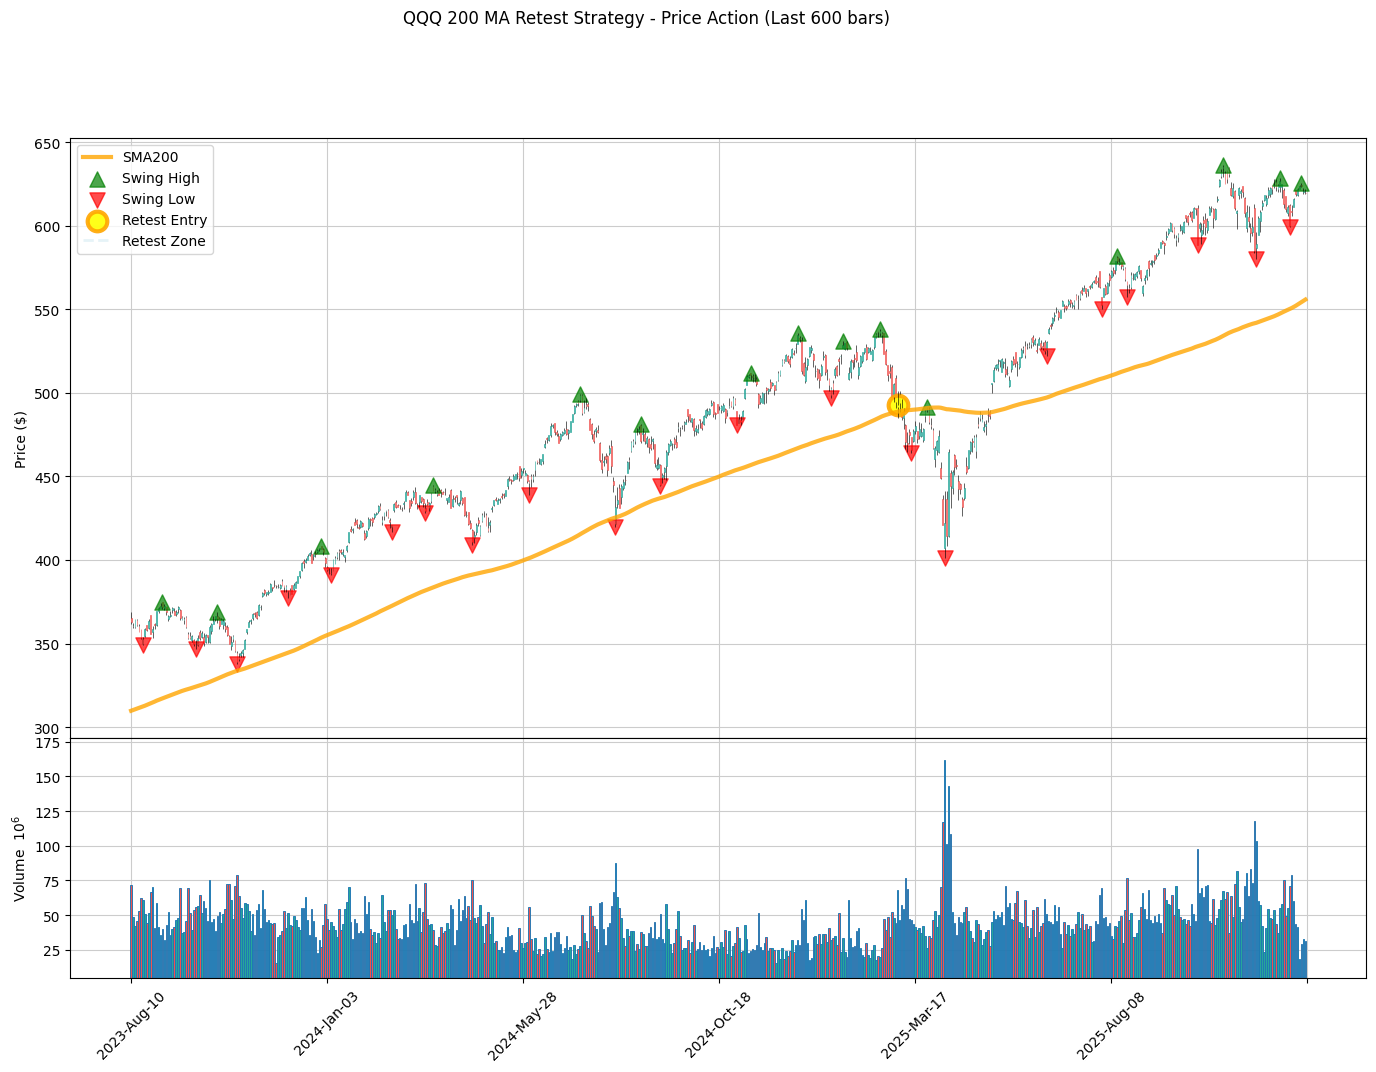


VISUALIZATION COMPLETE - 200 MA RETEST STRATEGY
Orange thick line = 200-day SMA
Green triangles (^) = Swing Highs
Red triangles (v) = Swing Lows
Yellow circles = Retest Entry Signals
Light blue dashed line = Retest Zone (when near 200 MA in uptrend)

Current Status:
Trend: Not Uptrend
Position: Not Near 200 MA
Retest signals in plot period: 1


In [167]:
# Prepare data for visualization (last 500-800 bars for readability)
plot_bars_ma200 = 600
df_plot_ma200 = df_ma200.tail(plot_bars_ma200).copy()

# Set date as index for mplfinance
df_plot_ma200_indexed = df_plot_ma200.set_index('date')

# Ensure mplfinance-compatible column names (capitalize first letter)
# mplfinance expects: Open, High, Low, Close, Volume
column_mapping = {
    'open': 'Open',
    'high': 'High',
    'low': 'Low',
    'close': 'Close',
    'vol': 'Volume'
}

# Rename columns if they exist
for old_col, new_col in column_mapping.items():
    if old_col in df_plot_ma200_indexed.columns:
        df_plot_ma200_indexed.rename(columns={old_col: new_col}, inplace=True)

# Also handle Adj Close if present
if 'Adj Close' in df_plot_ma200_indexed.columns:
    # Use Adj Close as Close for plotting
    df_plot_ma200_indexed['Close'] = df_plot_ma200_indexed['Adj Close']
elif 'adj_close' in df_plot_ma200_indexed.columns:
    df_plot_ma200_indexed['Close'] = df_plot_ma200_indexed['adj_close']

# Ensure SMA200 and other analysis columns are preserved (they should already be there)
# If SMA200 doesn't exist, calculate it
if 'SMA200' not in df_plot_ma200_indexed.columns:
    df_plot_ma200_indexed['SMA200'] = df_plot_ma200_indexed['Close'].rolling(window=200, min_periods=200).mean()

# Prepare additional plots
addplot_list_ma200 = []

# Add 200 SMA (thick orange line)
if not df_plot_ma200_indexed['SMA200'].isna().all():
    addplot_list_ma200.append(mpf.make_addplot(
        df_plot_ma200_indexed['SMA200'], 
        color='orange', 
        width=3, 
        alpha=0.8,
        linestyle='-',
        label='SMA200'
    ))

# Add swing high markers (green triangles)
swing_highs_plot_ma200 = df_plot_ma200[df_plot_ma200['swing_high_ma200']].copy()
if len(swing_highs_plot_ma200) > 0:
    swing_high_prices_ma200 = swing_highs_plot_ma200['high'].values
    swing_high_dates_ma200 = swing_highs_plot_ma200['date'].values
    swing_high_series_ma200 = pd.Series(swing_high_prices_ma200, index=swing_high_dates_ma200)
    swing_high_series_ma200 = swing_high_series_ma200.reindex(df_plot_ma200_indexed.index, fill_value=np.nan)
    addplot_list_ma200.append(mpf.make_addplot(
        swing_high_series_ma200, 
        type='scatter', 
        markersize=120, 
        marker='^', 
        color='green', 
        alpha=0.7,
        label='Swing High'
    ))

# Add swing low markers (red triangles)
swing_lows_plot_ma200 = df_plot_ma200[df_plot_ma200['swing_low_ma200']].copy()
if len(swing_lows_plot_ma200) > 0:
    swing_low_prices_ma200 = swing_lows_plot_ma200['low'].values
    swing_low_dates_ma200 = swing_lows_plot_ma200['date'].values
    swing_low_series_ma200 = pd.Series(swing_low_prices_ma200, index=swing_low_dates_ma200)
    swing_low_series_ma200 = swing_low_series_ma200.reindex(df_plot_ma200_indexed.index, fill_value=np.nan)
    addplot_list_ma200.append(mpf.make_addplot(
        swing_low_series_ma200, 
        type='scatter', 
        markersize=120, 
        marker='v', 
        color='red', 
        alpha=0.7,
        label='Swing Low'
    ))

# Add retest signal markers (yellow circles with arrow)
retest_signals_plot_ma200 = df_plot_ma200[df_plot_ma200['retest_signal']].copy()
if len(retest_signals_plot_ma200) > 0:
    # Use 'Close' column (already mapped from price_col)
    retest_prices_ma200 = retest_signals_plot_ma200[price_col].values
    retest_dates_ma200 = retest_signals_plot_ma200['date'].values
    retest_series_ma200 = pd.Series(retest_prices_ma200, index=retest_dates_ma200)
    retest_series_ma200 = retest_series_ma200.reindex(df_plot_ma200_indexed.index, fill_value=np.nan)
    addplot_list_ma200.append(mpf.make_addplot(
        retest_series_ma200, 
        type='scatter', 
        markersize=200, 
        marker='o', 
        color='yellow', 
        alpha=0.9,
        edgecolors='orange',
        linewidths=3,
        label='Retest Entry'
    ))

# Highlight retest zones (shaded area when near_200ma and uptrend)
# Create a series for the retest zone (SMA200 value when condition is met)
# Need to align with the indexed dataframe
retest_zone_ma200 = df_plot_ma200_indexed['SMA200'].copy()
# Get the boolean conditions from the original df_plot_ma200 (before indexing)
near_200ma_values = df_plot_ma200['near_200ma'].values
uptrend_values = df_plot_ma200['uptrend'].values
retest_zone_ma200[~(near_200ma_values & uptrend_values)] = np.nan
addplot_list_ma200.append(mpf.make_addplot(
    retest_zone_ma200,
    type='line',
    color='lightblue',
    width=2,
    alpha=0.3,
    linestyle='--',
    label='Retest Zone'
))

# Create custom style (simplified for compatibility)
# Use simpler syntax that works across mplfinance versions
mc_ma200 = mpf.make_marketcolors(
    up='#26a69a',
    down='#ef5350',
    edge='inherit',
    volume='in'
)

style_ma200 = mpf.make_mpf_style(
    marketcolors=mc_ma200,
    gridstyle='-',
    gridcolor='#cccccc',
    y_on_right=False
)

# Plot
mpf.plot(
    df_plot_ma200_indexed,
    type='candle',
    style=style_ma200,
    volume=True,
    addplot=addplot_list_ma200,
    title=f'{ticker} 200 MA Retest Strategy - Price Action (Last {plot_bars_ma200} bars)',
    ylabel='Price ($)',
    figsize=(18, 12),
    warn_too_much_data=False
)

print(f"\n{'='*60}")
print("VISUALIZATION COMPLETE - 200 MA RETEST STRATEGY")
print(f"{'='*60}")
print("Orange thick line = 200-day SMA")
print("Green triangles (^) = Swing Highs")
print("Red triangles (v) = Swing Lows")
print("Yellow circles = Retest Entry Signals")
print("Light blue dashed line = Retest Zone (when near 200 MA in uptrend)")
print(f"{'='*60}")

# Print current status
current_trend_ma200 = "Uptrend" if df_plot_ma200['uptrend'].iloc[-1] else "Not Uptrend"
current_near_ma200 = "Near 200 MA" if df_plot_ma200['near_200ma'].iloc[-1] else "Not Near 200 MA"
print(f"\nCurrent Status:")
print(f"Trend: {current_trend_ma200}")
print(f"Position: {current_near_ma200}")
print(f"Retest signals in plot period: {df_plot_ma200['retest_signal'].sum()}")


## Backtest Results

Backtest the 200 MA retest strategy with dynamic exits


In [168]:
def backtest_200ma_retest(data, initial_capital=10000, risk_per_trade=0.01, stop_loss_pct=0.05, take_profit_pct=0.10, max_hold_days=60):
    """
    Backtest the 200 MA Retest trading strategy (LONG-ONLY VERSION).
    
    Strategy Rules:
    - Trend Filter: Close > 200 SMA AND higher highs AND higher lows (structural uptrend)
    - Setup: Price pulls back and touches/comes within 1% of 200 SMA
    - Entry: Retest signal (near 200 MA + uptrend + bullish candle)
    - Exit: Dynamic (while Close > 200 SMA, max 60 days) OR 5% trailing stop OR +10% take-profit
    - Position sizing: Risk 1% of current capital per trade (adjusted for stop distance)
    
    Parameters:
    -----------
    data : pd.DataFrame
        DataFrame with columns: date, open, high, low, close, vol, SMA200, uptrend, retest_signal
    initial_capital : float
        Starting capital (default: $10,000)
    risk_per_trade : float
        Risk percentage per trade (default: 1% = 0.01)
    stop_loss_pct : float
        Stop-loss percentage from entry (default: 5% = 0.05)
    take_profit_pct : float
        Take-profit percentage from entry (default: 10% = 0.10)
    max_hold_days : int
        Maximum holding period in days (default: 60)
    
    Returns:
    --------
    dict : Dictionary containing backtest results and metrics
    """
    
    # Create a copy to avoid modifying original data
    df = data.copy()
    
    # Ensure we have enough data
    if len(df) < 200:
        return {
            'error': f'Insufficient data: need at least 200 days, got {len(df)}',
            'trades': [],
            'equity_curve': None
        }
    
    # Determine price column
    price_col = 'close'
    if 'Adj Close' in df.columns:
        price_col = 'Adj Close'
    elif 'adj_close' in df.columns:
        price_col = 'adj_close'
    
    # Ensure required columns exist
    if 'SMA200' not in df.columns:
        df['SMA200'] = df[price_col].rolling(window=200, min_periods=200).mean()
    if 'uptrend' not in df.columns:
        df['uptrend'] = False
    if 'retest_signal' not in df.columns:
        df['retest_signal'] = False
    
    # Get swing lows for trailing stop reference
    swing_lows = df[df.get('swing_low_ma200', pd.Series([False]*len(df)))].copy() if 'swing_low_ma200' in df.columns else pd.DataFrame()
    
    # Initialize trading variables
    capital = initial_capital
    position = None
    entry_price = None
    entry_date = None
    entry_index = None
    position_size = None
    trailing_stop_price = None  # For trailing stop
    trades = []
    equity_curve = [capital]
    
    # Loop through data to simulate trades (start from index 200)
    for i in range(200, len(df)):
        current_price = df.loc[i, price_col]
        current_date = df.loc[i, 'date']
        current_high = df.loc[i, 'high']
        current_low = df.loc[i, 'low']
        current_sma200 = df.loc[i, 'SMA200']
        
        # Check for stop-loss if in position
        if position == 'long':
            # Update trailing stop (5% below highest price since entry)
            if trailing_stop_price is None:
                trailing_stop_price = entry_price * (1 - stop_loss_pct)
            else:
                # Trailing stop: moves up with price, never down
                new_trailing_stop = current_high * (1 - stop_loss_pct)
                if new_trailing_stop > trailing_stop_price:
                    trailing_stop_price = new_trailing_stop
            
            # Check if price hit trailing stop
            if current_low <= trailing_stop_price:
                exit_price = trailing_stop_price
                pnl = (exit_price - entry_price) / entry_price
                trade_value = capital + (position_size * (exit_price - entry_price))
                capital = trade_value
                
                trades.append({
                    'entry_date': entry_date,
                    'exit_date': current_date,
                    'entry_price': entry_price,
                    'exit_price': exit_price,
                    'position': position,
                    'position_size': position_size,
                    'pnl': pnl,
                    'pnl_pct': pnl * 100,
                    'pnl_dollar': position_size * (exit_price - entry_price),
                    'exit_reason': 'trailing_stop',
                    'hold_days': (current_date - entry_date).days
                })
                
                position = None
                entry_price = None
                entry_date = None
                entry_index = None
                position_size = None
                trailing_stop_price = None
                continue
        
        # Check for take-profit if in position
        if position == 'long':
            if current_high >= entry_price * (1 + take_profit_pct):
                exit_price = entry_price * (1 + take_profit_pct)
                pnl = (exit_price - entry_price) / entry_price
                trade_value = capital + (position_size * (exit_price - entry_price))
                capital = trade_value
                
                trades.append({
                    'entry_date': entry_date,
                    'exit_date': current_date,
                    'entry_price': entry_price,
                    'exit_price': exit_price,
                    'position': position,
                    'position_size': position_size,
                    'pnl': pnl,
                    'pnl_pct': pnl * 100,
                    'pnl_dollar': position_size * (exit_price - entry_price),
                    'exit_reason': 'take_profit',
                    'hold_days': (current_date - entry_date).days
                })
                
                position = None
                entry_price = None
                entry_date = None
                entry_index = None
                position_size = None
                trailing_stop_price = None
                continue
        
        # Check for exit conditions if in position
        if position == 'long':
            days_held = (current_date - entry_date).days
            
            # Exit if price drops below SMA200 (dynamic exit)
            if pd.notna(current_sma200) and current_price < current_sma200:
                pnl = (current_price - entry_price) / entry_price
                trade_value = capital + (position_size * (current_price - entry_price))
                capital = trade_value
                
                trades.append({
                    'entry_date': entry_date,
                    'exit_date': current_date,
                    'entry_price': entry_price,
                    'exit_price': current_price,
                    'position': position,
                    'position_size': position_size,
                    'pnl': pnl,
                    'pnl_pct': pnl * 100,
                    'pnl_dollar': position_size * (current_price - entry_price),
                    'exit_reason': 'below_sma200',
                    'hold_days': days_held
                })
                
                position = None
                entry_price = None
                entry_date = None
                entry_index = None
                position_size = None
                trailing_stop_price = None
                continue
            
            # Exit after max_hold_days (60 days)
            if days_held >= max_hold_days:
                pnl = (current_price - entry_price) / entry_price
                trade_value = capital + (position_size * (current_price - entry_price))
                capital = trade_value
                
                trades.append({
                    'entry_date': entry_date,
                    'exit_date': current_date,
                    'entry_price': entry_price,
                    'exit_price': current_price,
                    'position': position,
                    'position_size': position_size,
                    'pnl': pnl,
                    'pnl_pct': pnl * 100,
                    'pnl_dollar': position_size * (current_price - entry_price),
                    'exit_reason': 'time_limit',
                    'hold_days': days_held
                })
                
                position = None
                entry_price = None
                entry_date = None
                entry_index = None
                position_size = None
                trailing_stop_price = None
                continue
        
        # Check for new entry signals
        if position is None:
            signal = df.loc[i, 'retest_signal']
            sma200_value = df.loc[i, 'SMA200']
            
            if signal and pd.notna(sma200_value) and current_price > sma200_value * 0.99:  # Allow slight below for retest
                position = 'long'
                entry_price = current_price
                entry_date = current_date
                entry_index = i
                trailing_stop_price = entry_price * (1 - stop_loss_pct)  # Initial trailing stop
                
                # Calculate position size: risk 1% of capital
                position_size = int((capital * risk_per_trade) / (entry_price * stop_loss_pct))
                if position_size < 1:
                    position_size = 0
                    position = None
                    entry_price = None
                    entry_date = None
                    entry_index = None
                    trailing_stop_price = None
        
        # Update equity curve
        if position == 'long':
            current_value = capital + (position_size * (current_price - entry_price))
            equity_curve.append(current_value)
        else:
            equity_curve.append(capital)
    
    # Close any open position at the end
    if position == 'long':
        final_price = df.loc[len(df)-1, price_col]
        pnl = (final_price - entry_price) / entry_price
        trade_value = capital + (position_size * (final_price - entry_price))
        capital = trade_value
        
        trades.append({
            'entry_date': entry_date,
            'exit_date': df.loc[len(df)-1, 'date'],
            'entry_price': entry_price,
            'exit_price': final_price,
            'position': position,
            'position_size': position_size,
            'pnl': pnl,
            'pnl_pct': pnl * 100,
            'pnl_dollar': position_size * (final_price - entry_price),
            'exit_reason': 'end_of_data',
            'hold_days': (df.loc[len(df)-1, 'date'] - entry_date).days
        })
    
    # Calculate metrics
    if len(trades) > 0:
        trades_df = pd.DataFrame(trades)
        
        total_return = (capital - initial_capital) / initial_capital
        winning_trades = trades_df[trades_df['pnl'] > 0]
        win_rate = len(winning_trades) / len(trades_df) if len(trades_df) > 0 else 0
        avg_win = winning_trades['pnl'].mean() if len(winning_trades) > 0 else 0
        losing_trades = trades_df[trades_df['pnl'] <= 0]
        avg_loss = losing_trades['pnl'].mean() if len(losing_trades) > 0 else 0
        
        equity_array = np.array(equity_curve)
        running_max = np.maximum.accumulate(equity_array)
        drawdown = (equity_array - running_max) / running_max
        max_drawdown = drawdown.min()
        
        daily_returns = np.diff(equity_curve) / equity_curve[:-1]
        sharpe_ratio = np.mean(daily_returns) / np.std(daily_returns) * np.sqrt(252) if np.std(daily_returns) > 0 else 0
        
        results = {
            'initial_capital': initial_capital,
            'final_capital': capital,
            'total_return': total_return,
            'total_return_pct': total_return * 100,
            'total_trades': len(trades_df),
            'win_rate': win_rate,
            'win_rate_pct': win_rate * 100,
            'avg_win': avg_win,
            'avg_win_pct': avg_win * 100,
            'avg_loss': avg_loss,
            'avg_loss_pct': avg_loss * 100,
            'max_drawdown': max_drawdown,
            'max_drawdown_pct': max_drawdown * 100,
            'sharpe_ratio': sharpe_ratio,
            'trades': trades_df,
            'equity_curve': equity_curve,
            'dates': df['date'].tolist(),
            'price_col': price_col
        }
    else:
        results = {
            'initial_capital': initial_capital,
            'final_capital': capital,
            'total_return': 0,
            'total_return_pct': 0,
            'total_trades': 0,
            'win_rate': 0,
            'win_rate_pct': 0,
            'avg_win': 0,
            'avg_win_pct': 0,
            'avg_loss': 0,
            'avg_loss_pct': 0,
            'max_drawdown': 0,
            'max_drawdown_pct': 0,
            'sharpe_ratio': 0,
            'trades': pd.DataFrame(),
            'equity_curve': equity_curve,
            'dates': df['date'].tolist(),
            'price_col': price_col
        }
    
    return results


In [169]:
# Run backtest for 200 MA Retest Strategy
print("="*60)
print("Running backtest for 200 MA Retest Strategy (Strategy 4)...")
print("="*60)
print("Strategy: Buy retests of 200 MA in confirmed uptrend")
print("Entry: Retest signal (near 200 MA + uptrend + bullish candle)")
print("Exit: Dynamic (while > SMA200, max 60d) OR 5% trailing stop OR +10% target")
print("="*60)

# Use data with swing detection and retest signals
results_200ma = backtest_200ma_retest(
    data=df_ma200,
    initial_capital=10000,
    risk_per_trade=0.01,
    stop_loss_pct=0.05,  # 5% trailing stop
    take_profit_pct=0.10,  # 10% take-profit (2:1 R:R)
    max_hold_days=60  # Maximum 60-day hold period
)

# Display results
print(f"\n{'='*60}")
print("BACKTEST RESULTS - 200 MA RETEST STRATEGY (Strategy 4)")
print(f"{'='*60}")
print(f"Initial Capital: ${results_200ma['initial_capital']:,.2f}")
print(f"Final Capital: ${results_200ma['final_capital']:,.2f}")
if results_200ma['total_return_pct'] >= 0:
    print(f"Total Return: +{results_200ma['total_return_pct']:.2f}%")
else:
    print(f"Total Return: {results_200ma['total_return_pct']:.2f}%")
print(f"\nTotal Trades: {results_200ma['total_trades']}")
print(f"Win Rate: {results_200ma['win_rate_pct']:.2f}%")
print(f"Average Win: {results_200ma['avg_win_pct']:.2f}%")
print(f"Average Loss: {results_200ma['avg_loss_pct']:.2f}%")
print(f"Max Drawdown: {results_200ma['max_drawdown_pct']:.2f}%")
print(f"Sharpe Ratio: {results_200ma['sharpe_ratio']:.2f}")
print(f"\nNote: Strategy waits for retest of 200 MA in confirmed uptrend (higher highs/higher lows)")
print(f"{'='*60}")


Running backtest for 200 MA Retest Strategy (Strategy 4)...
Strategy: Buy retests of 200 MA in confirmed uptrend
Entry: Retest signal (near 200 MA + uptrend + bullish candle)
Exit: Dynamic (while > SMA200, max 60d) OR 5% trailing stop OR +10% target

BACKTEST RESULTS - 200 MA RETEST STRATEGY (Strategy 4)
Initial Capital: $10,000.00
Final Capital: $10,002.82
Total Return: +0.03%

Total Trades: 16
Win Rate: 18.75%
Average Win: 6.90%
Average Loss: -1.46%
Max Drawdown: -2.88%
Sharpe Ratio: 0.00

Note: Strategy waits for retest of 200 MA in confirmed uptrend (higher highs/higher lows)



200 MA RETEST STRATEGY (Strategy 4) - PERFORMANCE SUMMARY
Metric                         Strategy             Buy & Hold          
----------------------------------------------------------------------
Initial Capital                $10,000.00                $10,000.00
Final Capital                  $10,002.82                $82,257.69
Total Return                   +0.03%              +722.58%            
Total Trades                   16                   N/A                 
Win Rate                       18.75%                N/A                 
Average Win                    6.90%                N/A                 
Average Loss                   -1.46%                N/A                 
Max Drawdown                   -2.88%                N/A                 
Sharpe Ratio                   0.00                N/A                 


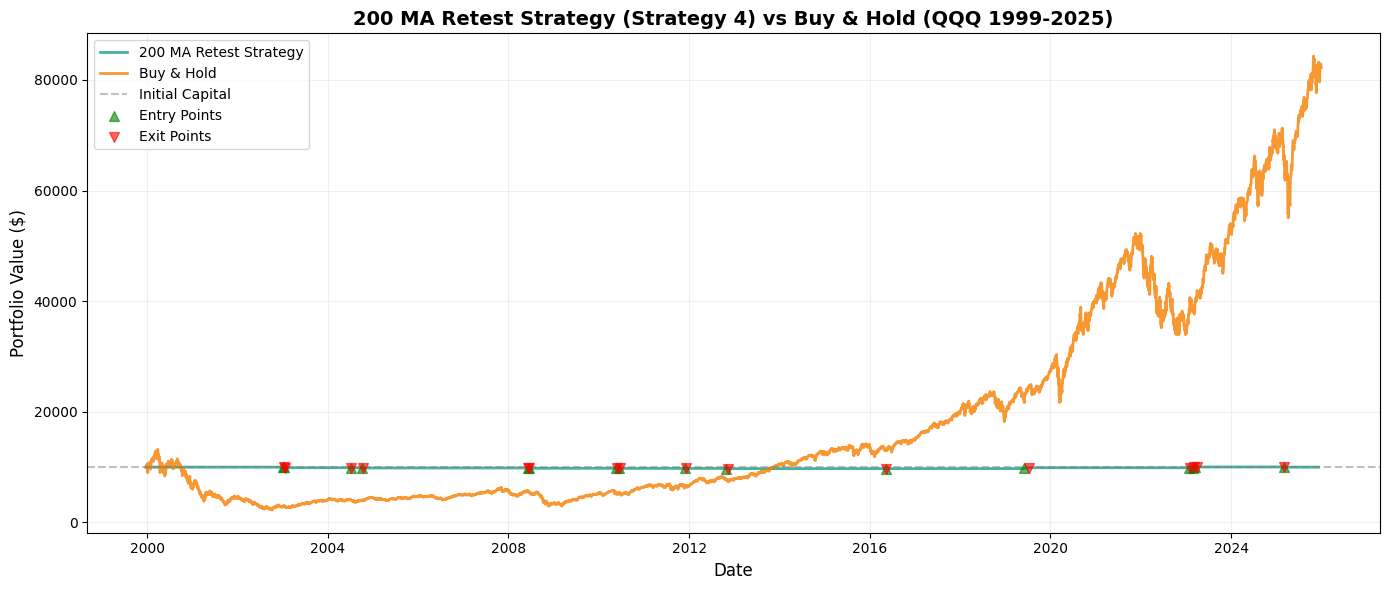

In [170]:
# Display 200 MA Retest Strategy Performance Summary with Buy & Hold Comparison
if len(df_ma200) > 0:
    # Calculate Buy & Hold return
    price_col = results_200ma['price_col']
    buy_hold_start_idx = 200
    buy_hold_start_price = df_ma200[price_col].iloc[buy_hold_start_idx]
    buy_hold_end_price = df_ma200[price_col].iloc[-1]
    buy_hold_return = (buy_hold_end_price - buy_hold_start_price) / buy_hold_start_price
    buy_hold_final = results_200ma['initial_capital'] * (1 + buy_hold_return)
    
    print(f"\n{'='*60}")
    print("200 MA RETEST STRATEGY (Strategy 4) - PERFORMANCE SUMMARY")
    print(f"{'='*60}")
    print(f"{'Metric':<30} {'Strategy':<20} {'Buy & Hold':<20}")
    print(f"{'-'*70}")
    print(f"{'Initial Capital':<30} ${results_200ma['initial_capital']:,.2f}{'':<15} ${results_200ma['initial_capital']:,.2f}")
    print(f"{'Final Capital':<30} ${results_200ma['final_capital']:,.2f}{'':<15} ${buy_hold_final:,.2f}")
    
    strategy_return_str = f"+{results_200ma['total_return_pct']:.2f}%" if results_200ma['total_return_pct'] >= 0 else f"{results_200ma['total_return_pct']:.2f}%"
    buy_hold_return_str = f"+{buy_hold_return*100:.2f}%" if buy_hold_return >= 0 else f"{buy_hold_return*100:.2f}%"
    print(f"{'Total Return':<30} {strategy_return_str:<19} {buy_hold_return_str:<20}")
    print(f"{'Total Trades':<30} {results_200ma['total_trades']:<20} {'N/A':<20}")
    print(f"{'Win Rate':<30} {results_200ma['win_rate_pct']:.2f}%{'':<15} {'N/A':<20}")
    print(f"{'Average Win':<30} {results_200ma['avg_win_pct']:.2f}%{'':<15} {'N/A':<20}")
    print(f"{'Average Loss':<30} {results_200ma['avg_loss_pct']:.2f}%{'':<15} {'N/A':<20}")
    print(f"{'Max Drawdown':<30} {results_200ma['max_drawdown_pct']:.2f}%{'':<15} {'N/A':<20}")
    print(f"{'Sharpe Ratio':<30} {results_200ma['sharpe_ratio']:.2f}{'':<15} {'N/A':<20}")
    print(f"{'='*60}")
    
    # Plot equity curve comparison
    fig, ax = plt.subplots(figsize=(14, 6))
    
    dates_extended = results_200ma['dates'][200:]
    if len(results_200ma['equity_curve']) == len(dates_extended) + 1:
        ax.plot(dates_extended, results_200ma['equity_curve'][1:], linewidth=2, color='#16A085', label='200 MA Retest Strategy', alpha=0.8)
        equity_curve_aligned = results_200ma['equity_curve'][1:]
    else:
        min_len = min(len(dates_extended), len(results_200ma['equity_curve']))
        ax.plot(dates_extended[:min_len], results_200ma['equity_curve'][:min_len], linewidth=2, color='#16A085', label='200 MA Retest Strategy', alpha=0.8)
        equity_curve_aligned = results_200ma['equity_curve'][:min_len]
    
    # Buy & Hold equity curve
    buy_hold_curve = [results_200ma['initial_capital']]
    for i in range(buy_hold_start_idx + 1, len(df_ma200)):
        return_so_far = (df_ma200[price_col].iloc[i] - buy_hold_start_price) / buy_hold_start_price
        buy_hold_curve.append(results_200ma['initial_capital'] * (1 + return_so_far))
    
    ax.plot(df_ma200['date'].iloc[buy_hold_start_idx:], buy_hold_curve, linewidth=2, color='#F77F00', label='Buy & Hold', alpha=0.8)
    ax.axhline(y=results_200ma['initial_capital'], color='gray', linestyle='--', alpha=0.5, label='Initial Capital')
    
    # Mark entry points
    if len(results_200ma['trades']) > 0:
        trades_df = results_200ma['trades']
        entry_dates = pd.to_datetime(trades_df['entry_date']).tolist()
        exit_dates = pd.to_datetime(trades_df['exit_date']).tolist()
        
        entry_equity = []
        for ed in entry_dates:
            try:
                idx = dates_extended.index(ed)
                if idx < len(equity_curve_aligned):
                    entry_equity.append(equity_curve_aligned[idx])
                else:
                    entry_equity.append(results_200ma['initial_capital'])
            except:
                entry_equity.append(results_200ma['initial_capital'])
        
        exit_equity = []
        for ed in exit_dates:
            try:
                idx = dates_extended.index(ed)
                if idx < len(equity_curve_aligned):
                    exit_equity.append(equity_curve_aligned[idx])
                else:
                    exit_equity.append(results_200ma['initial_capital'])
            except:
                exit_equity.append(results_200ma['initial_capital'])
        
        ax.scatter(entry_dates, entry_equity, color='green', marker='^', s=50, alpha=0.6, label='Entry Points', zorder=5)
        ax.scatter(exit_dates, exit_equity, color='red', marker='v', s=50, alpha=0.6, label='Exit Points', zorder=5)
    
    date_range_str = f"{df_ma200['date'].min().year}-{df_ma200['date'].max().year}"
    ax.set_ylabel('Portfolio Value ($)', fontsize=12)
    ax.set_xlabel('Date', fontsize=12)
    ax.set_title(f'200 MA Retest Strategy (Strategy 4) vs Buy & Hold ({ticker} {date_range_str})', fontsize=14, fontweight='bold')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("No data available for plotting.")


**Quick Tips:**

**Tune parameters after first run:**
- `swing_order`: 5-15 (higher = fewer but cleaner swings)
- `proximity_pct`: 0.5% to 2% (how close to 200 MA for retest)
- Confirmation: Add volume spike or specific candle (e.g., hammer on retest via `talib.CDLHAMMER`)

**Why this should improve:**
- Fewer false entries (only in uptrend + retest)
- Better alignment with QQQ's long-term bull bias
- Larger average winners (holds through trend continuation)

**Risks to watch:**
- Whipsaws if 200 MA fails (e.g., 2022 bear market) — the uptrend filter + stop should protect


# Backtest: Strategy 2 v3 - Dynamic Momentum Continuation (Long-Only)

**v3 fixes: Tighter stop (4%), dynamic hold (while > SMA200, max 30d), +7% target, RSI>50 filter.**

This version addresses win/loss imbalance and short holds by:
- Adding RSI(14) > 50 filter for stronger momentum confirmation
- Using dynamic hold period: hold while price > SMA200 (up to max 30 days)
- Tighter 4% stop-loss (instead of 5%) for better risk control
- Take-profit target at +7% to lock in gains
- All other filters remain: 200-day SMA, volume > 20-day average


In [171]:
def backtest_dynamic_momentum(data, initial_capital=10000, risk_per_trade=0.01, stop_loss_pct=0.04, take_profit_pct=0.07, max_hold_days=30):
    """
    Backtest the Dynamic Momentum Continuation trading strategy (LONG-ONLY VERSION v3).
    
    Strategy Rules:
    - Long Entry: Bullish CDLLONGLINE or CDLCLOSINGMARUBOZU (value > 0) AND Close > 200-day SMA 
                  AND Volume > 20-day average AND RSI(14) > 50
    - No short entries (long-only strategy)
    - Only trade when price is above 200-day SMA (no trades in downtrends)
    - Exit: Dynamic hold while Close > SMA200 (max 30 days) OR 4% trailing stop-loss OR +7% take-profit
    - Position sizing: Risk 1% of current capital per trade (adjusted for 4% stop)
    
    Parameters:
    -----------
    data : pd.DataFrame
        DataFrame with columns: date, open, high, low, close, vol
    initial_capital : float
        Starting capital (default: $10,000)
    risk_per_trade : float
        Risk percentage per trade (default: 1% = 0.01)
    stop_loss_pct : float
        Stop-loss percentage from entry (default: 4% = 0.04)
    take_profit_pct : float
        Take-profit percentage from entry (default: 7% = 0.07)
    max_hold_days : int
        Maximum holding period in days (default: 30)
    
    Returns:
    --------
    dict : Dictionary containing backtest results and metrics
    """
    
    # Create a copy to avoid modifying original data
    df = data.copy()
    
    # Ensure we have enough data for 200-day SMA
    if len(df) < 200:
        return {
            'error': f'Insufficient data: need at least 200 days, got {len(df)}',
            'trades': [],
            'equity_curve': None
        }
    
    # Determine price column (use adjusted close if available)
    price_col = 'close'
    if 'Adj Close' in df.columns:
        price_col = 'Adj Close'
    elif 'adj_close' in df.columns:
        price_col = 'adj_close'
    
    # Calculate 200-day Simple Moving Average
    df['SMA200'] = df[price_col].rolling(window=200, min_periods=200).mean()
    
    # Calculate 20-day average volume
    df['Avg_Vol20'] = df['vol'].rolling(window=20, min_periods=20).mean()
    
    # Calculate RSI(14)
    df['RSI14'] = talib.RSI(df[price_col].values, timeperiod=14)
    
    # Detect candlestick patterns using TA-Lib
    df['CDLLONGLINE'] = talib.CDLLONGLINE(df['open'].values, df['high'].values, 
                                          df['low'].values, df[price_col].values)
    df['CDLCLOSINGMARUBOZU'] = talib.CDLCLOSINGMARUBOZU(df['open'].values, df['high'].values, 
                                                        df['low'].values, df[price_col].values)
    
    # Determine long signals with all conditions
    # Long signal: bullish pattern (value > 0) AND close > SMA200 AND volume > avg_vol20 AND RSI14 > 50
    long_condition = (
        ((df['CDLLONGLINE'] > 0) | (df['CDLCLOSINGMARUBOZU'] > 0)) &
        (df[price_col] > df['SMA200']) &
        (df['vol'] > df['Avg_Vol20']) &
        (df['RSI14'] > 50) &
        (~df['SMA200'].isna()) &  # Ensure SMA200 is calculated
        (~df['RSI14'].isna())  # Ensure RSI14 is calculated
    )
    
    # Create long signal column: 1 (long entry), 0 (no signal)
    df['Long_Signal'] = 0
    df.loc[long_condition, 'Long_Signal'] = 1
    
    # Initialize trading variables
    capital = initial_capital
    position = None  # 'long' or None (no shorts)
    entry_price = None
    entry_date = None
    entry_index = None
    position_size = None  # Number of shares
    trades = []
    equity_curve = [capital]
    
    # Loop through data to simulate trades (start from index 200 to ensure SMA200 is available)
    for i in range(200, len(df)):
        current_price = df.loc[i, price_col]
        current_date = df.loc[i, 'date']
        current_high = df.loc[i, 'high']
        current_low = df.loc[i, 'low']
        sma200_value = df.loc[i, 'SMA200']
        
        # Check for stop-loss if in position (long only)
        if position == 'long':
            # Long stop-loss: exit if price drops 4% below entry
            if current_low <= entry_price * (1 - stop_loss_pct):
                # Exit trade at stop-loss price
                exit_price = entry_price * (1 - stop_loss_pct)
                pnl = (exit_price - entry_price) / entry_price
                trade_value = capital + (position_size * (exit_price - entry_price))
                capital = trade_value
                
                trades.append({
                    'entry_date': entry_date,
                    'exit_date': current_date,
                    'entry_price': entry_price,
                    'exit_price': exit_price,
                    'position': position,
                    'position_size': position_size,
                    'pnl': pnl,
                    'pnl_pct': pnl * 100,
                    'pnl_dollar': position_size * (exit_price - entry_price),
                    'exit_reason': 'stop_loss',
                    'hold_days': (current_date - entry_date).days
                })
                
                position = None
                entry_price = None
                entry_date = None
                entry_index = None
                position_size = None
                continue  # Skip to next iteration
        
        # Check for take-profit if in position
        if position == 'long':
            # Take-profit: exit if price rises 7% above entry
            if current_high >= entry_price * (1 + take_profit_pct):
                # Exit trade at take-profit price
                exit_price = entry_price * (1 + take_profit_pct)
                pnl = (exit_price - entry_price) / entry_price
                trade_value = capital + (position_size * (exit_price - entry_price))
                capital = trade_value
                
                trades.append({
                    'entry_date': entry_date,
                    'exit_date': current_date,
                    'entry_price': entry_price,
                    'exit_price': exit_price,
                    'position': position,
                    'position_size': position_size,
                    'pnl': pnl,
                    'pnl_pct': pnl * 100,
                    'pnl_dollar': position_size * (exit_price - entry_price),
                    'exit_reason': 'take_profit',
                    'hold_days': (current_date - entry_date).days
                })
                
                position = None
                entry_price = None
                entry_date = None
                entry_index = None
                position_size = None
                continue  # Skip to next iteration
        
        # Check for exit conditions if in position
        if position == 'long':
            days_held = (current_date - entry_date).days
            
            # Exit if price drops below SMA200 (dynamic exit)
            if sma200_value is not None and current_price < sma200_value:
                # Exit trade at current close
                pnl = (current_price - entry_price) / entry_price
                trade_value = capital + (position_size * (current_price - entry_price))
                capital = trade_value
                
                trades.append({
                    'entry_date': entry_date,
                    'exit_date': current_date,
                    'entry_price': entry_price,
                    'exit_price': current_price,
                    'position': position,
                    'position_size': position_size,
                    'pnl': pnl,
                    'pnl_pct': pnl * 100,
                    'pnl_dollar': position_size * (current_price - entry_price),
                    'exit_reason': 'below_sma200',
                    'hold_days': days_held
                })
                
                position = None
                entry_price = None
                entry_date = None
                entry_index = None
                position_size = None
                continue  # Skip to next iteration
            
            # Exit after max_hold_days (30 days)
            if days_held >= max_hold_days:
                # Exit trade at current close
                pnl = (current_price - entry_price) / entry_price
                trade_value = capital + (position_size * (current_price - entry_price))
                capital = trade_value
                
                trades.append({
                    'entry_date': entry_date,
                    'exit_date': current_date,
                    'entry_price': entry_price,
                    'exit_price': current_price,
                    'position': position,
                    'position_size': position_size,
                    'pnl': pnl,
                    'pnl_pct': pnl * 100,
                    'pnl_dollar': position_size * (current_price - entry_price),
                    'exit_reason': 'max_hold_days',
                    'hold_days': days_held
                })
                
                position = None
                entry_price = None
                entry_date = None
                entry_index = None
                position_size = None
                continue  # Skip to next iteration
        
        # Check for new entry signals (only if not in position, long-only, and price above SMA200)
        if position is None:
            signal = df.loc[i, 'Long_Signal']
            rsi_value = df.loc[i, 'RSI14']
            
            # Long entry signal only (and price must be above SMA200, RSI > 50)
            if signal == 1 and sma200_value is not None and current_price > sma200_value and rsi_value is not None and rsi_value > 50:
                position = 'long'
                entry_price = current_price  # Enter at close of pattern candle
                entry_date = current_date
                entry_index = i
                
                # Calculate position size: risk 1% of capital
                # Position size = (capital * risk_per_trade) / (entry_price * stop_loss_pct)
                # Adjusted for 4% stop-loss
                position_size = int((capital * risk_per_trade) / (entry_price * stop_loss_pct))
                if position_size < 1:
                    position_size = 0  # Can't buy fractional shares
                    position = None
                    entry_price = None
                    entry_date = None
                    entry_index = None
        
        # Update equity curve (calculate current portfolio value)
        if position == 'long':
            current_value = capital + (position_size * (current_price - entry_price))
            equity_curve.append(current_value)
        else:
            equity_curve.append(capital)
    
    # Close any open position at the end
    if position == 'long':
        final_price = df.loc[len(df)-1, price_col]
        pnl = (final_price - entry_price) / entry_price
        trade_value = capital + (position_size * (final_price - entry_price))
        capital = trade_value
        
        trades.append({
            'entry_date': entry_date,
            'exit_date': df.loc[len(df)-1, 'date'],
            'entry_price': entry_price,
            'exit_price': final_price,
            'position': position,
            'position_size': position_size,
            'pnl': pnl,
            'pnl_pct': pnl * 100,
            'pnl_dollar': position_size * (final_price - entry_price),
            'exit_reason': 'end_of_data',
            'hold_days': (df.loc[len(df)-1, 'date'] - entry_date).days
        })
    
    # Calculate metrics
    if len(trades) > 0:
        trades_df = pd.DataFrame(trades)
        
        # Total return
        total_return = (capital - initial_capital) / initial_capital
        
        # Win rate
        winning_trades = trades_df[trades_df['pnl'] > 0]
        win_rate = len(winning_trades) / len(trades_df) if len(trades_df) > 0 else 0
        
        # Average win/loss
        avg_win = winning_trades['pnl'].mean() if len(winning_trades) > 0 else 0
        losing_trades = trades_df[trades_df['pnl'] <= 0]
        avg_loss = losing_trades['pnl'].mean() if len(losing_trades) > 0 else 0
        
        # Max drawdown
        equity_array = np.array(equity_curve)
        running_max = np.maximum.accumulate(equity_array)
        drawdown = (equity_array - running_max) / running_max
        max_drawdown = drawdown.min()
        
        # Sharpe ratio (assuming daily returns, risk-free rate = 0%)
        daily_returns = np.diff(equity_curve) / equity_curve[:-1]
        sharpe_ratio = np.mean(daily_returns) / np.std(daily_returns) * np.sqrt(252) if np.std(daily_returns) > 0 else 0
        
        # Total number of trades
        total_trades = len(trades_df)
        
        results = {
            'initial_capital': initial_capital,
            'final_capital': capital,
            'total_return': total_return,
            'total_return_pct': total_return * 100,
            'total_trades': total_trades,
            'win_rate': win_rate,
            'win_rate_pct': win_rate * 100,
            'avg_win': avg_win,
            'avg_win_pct': avg_win * 100,
            'avg_loss': avg_loss,
            'avg_loss_pct': avg_loss * 100,
            'max_drawdown': max_drawdown,
            'max_drawdown_pct': max_drawdown * 100,
            'sharpe_ratio': sharpe_ratio,
            'trades': trades_df,
            'equity_curve': equity_curve,
            'dates': df['date'].tolist(),
            'price_col': price_col
        }
    else:
        results = {
            'initial_capital': initial_capital,
            'final_capital': capital,
            'total_return': 0,
            'total_return_pct': 0,
            'total_trades': 0,
            'win_rate': 0,
            'win_rate_pct': 0,
            'avg_win': 0,
            'avg_win_pct': 0,
            'avg_loss': 0,
            'avg_loss_pct': 0,
            'max_drawdown': 0,
            'max_drawdown_pct': 0,
            'sharpe_ratio': 0,
            'trades': pd.DataFrame(),
            'equity_curve': equity_curve,
            'dates': df['date'].tolist(),
            'price_col': price_col
        }
    
    return results
